In [ ]:
import random
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

In [ ]:
# ==========================================
# CELL 1 — Scenario Generator
# ==========================================


def generate_scenario(
    num_flows=10,
    hC=0.8,
    networks=None
):
    """
    Generate a synthetic heterogeneous communication scenario.
    """

    if num_flows < 1:
        raise ValueError("num_flows must be at least 1.")

    if not 0 <= hC <= 1:
        raise ValueError("hC must be between 0 and 1.")

    if networks is None:
        networks = {
            "N1": 250,
            "N2": 150,
            "N3": 100
        }

    if not networks:
        raise ValueError(
            "At least one communication network is required."
        )

    if any(
        capacity <= 0
        for capacity in networks.values()
    ):
        raise ValueError(
            "All network capacities must be positive."
        )

    flows = {}

    for flow_index in range(1, num_flows + 1):

        l1_demand = random.randint(20, 60)

        criticality_profile = {
            1: l1_demand
        }

        # Optional L2
        if random.random() < hC:

            l2_demand = max(
                1,
                int(
                    l1_demand
                    * random.uniform(0.3, 0.6)
                )
            )

            criticality_profile[2] = l2_demand

            # Optional L3
            if random.random() < hC:

                l3_demand = max(
                    1,
                    int(
                        l2_demand
                        * random.uniform(0.3, 0.6)
                    )
                )

                criticality_profile[3] = l3_demand

        flows[f"F{flow_index}"] = criticality_profile

    return networks.copy(), flows

In [ ]:
# ==========================================
# CELL 2 
# ==========================================
#

def evaluate_solution(allocation, flows, networks):
    """
    Evaluate a candidate resource-allocation solution.

    Parameters
    ----------
    allocation : dict
        Chromosome represented as:
        allocation[flow] = (network, level)

    flows : dict
        Message-flow bandwidth-demand profiles.

    networks : dict
        Communication-network capacities.

    Returns
    -------
    dict
        Evaluation metrics, fitness value,
        capacity violation, and network loads.
    """

    if not flows:
        raise ValueError(
            "At least one message flow is required."
        )

    if not networks:
        raise ValueError(
            "At least one communication network is required."
        )

    
    Lmax = 3

    # Current bandwidth utilisation
    loads = {
        network: 0
        for network in networks
    }

    total_score = 0
    allocated_flows = 0
    total_level = 0

    
    for flow in flows:

        network, level = allocation.get(
            flow,
            (None, None)
        )

        # Unallocated flow
        if network is None or level is None:
            continue

        # Ignore invalid gene assignments
        if (
            network not in networks
            or level not in flows[flow]
        ):
            continue

        allocated_flows += 1
        total_level += level

        demand = flows[flow][level]
        loads[network] += demand

        # Higher quality levels receive larger rewards:
        # L1 → 3, L2 → 2, L3 → 1
        total_score += (
            1 + Lmax - level
        )

    # Total excess bandwidth across all networks
    capacity_violation = sum(
        max(
            0,
            loads[network] - networks[network]
        )
        for network in networks
    )

    total_flows = len(flows)

    servP = (
        allocated_flows / total_flows
    )

    avCL = (
        total_level / allocated_flows
        if allocated_flows > 0
        else 0
    )

    # Only feasible, nonempty solutions receive fitness
    if (
        capacity_violation > 0
        or allocated_flows == 0
    ):

        criticality_quality = 0
        fitness = 0

    else:

        criticality_quality = (
            total_score
            / (allocated_flows * Lmax)
        )

        fitness = (
            allocated_flows
            + criticality_quality
        )

    return {
        "servP": servP,
        "avCL": avCL,
        "AllocatedFlows": allocated_flows,
        "TotalFlows": total_flows,
        "TotalScore": total_score,
        "CriticalityQuality": criticality_quality,
        "Fitness": fitness,
        "CapacityViolation": capacity_violation,
        "Loads": loads
    }

In [ ]:
# ==========================================
# CELL 3 — First-Fit (FF) Baseline Algorithm
# ==========================================
#
# .
#
#
# Output:
#
#   allocation[flow] = (network, criticality_level)
# ==========================================

def first_fit(flows, networks):

    remaining = networks.copy()
    allocation = {}

    for flow, levels in flows.items():

        allocated = False

        # Evaluate QoS levels from highest to lowest
        for level in sorted(levels.keys()):

            demand = levels[level]

            for network in remaining:

                if remaining[network] >= demand:

                    allocation[flow] = (network, level)
                    remaining[network] -= demand
                    allocated = True
                    break

            if allocated:
                break

        if not allocated:
            allocation[flow] = (None, None)

    return allocation

In [ ]:
# ==========================================
# CELL 4 — Best-Fit (BF) Baseline Algorithm
# ==========================================
#
# 
# Output:
#
#   allocation[flow] = (network, criticality_level)
# ==========================================

def best_fit(flows, networks):

    remaining = networks.copy()
    allocation = {}

    for flow, levels in flows.items():

        allocated = False

        # Try QoS levels from highest to lowest:
        # L1 → L2 → L3
        for level in sorted(levels.keys()):

            demand = levels[level]

            best_network = None
            smallest_remaining = None

            for network, capacity_left in remaining.items():

                if capacity_left >= demand:

                    remaining_after = (
                        capacity_left - demand
                    )

                    if (
                        smallest_remaining is None
                        or remaining_after < smallest_remaining
                    ):
                        smallest_remaining = remaining_after
                        best_network = network

            if best_network is not None:

                allocation[flow] = (
                    best_network,
                    level
                )

                remaining[best_network] -= demand
                allocated = True
                break

        if not allocated:

            allocation[flow] = (
                None,
                None
            )

    return allocation

In [ ]:
# ==========================================
# CELL 5 — Criticality-Aware Best-Fit (CABF)
# ==========================================
#
# 
# Output:
#
#   allocation[flow] = (network, criticality_level)
# ==========================================

def cabf(flows, networks):

    remaining = networks.copy()
    allocation = {}

    def best_fit_network(flow, level):
        """
        Return the communication network that leaves
        the smallest remaining bandwidth after
        allocating the specified message flow at
        the requested criticality level.
        """

        demand = flows[flow][level]

        best_network = None
        best_remaining_after = None

        for network, capacity_left in remaining.items():

            if capacity_left >= demand:

                remaining_after = capacity_left - demand

                if (
                    best_remaining_after is None
                    or remaining_after < best_remaining_after
                ):
                    best_remaining_after = remaining_after
                    best_network = network

        return best_network

    # Process QoS levels from lowest to highest:
    # L3 → L2 → L1
    all_levels = sorted(
        {
            level
            for profile in flows.values()
            for level in profile.keys()
        },
        reverse=True
    )

    for level in all_levels:

        # --------------------------------------------------
        # Step 1:
        # Upgrade previously allocated message flows
        # whenever sufficient bandwidth is available.
        # --------------------------------------------------
        for flow in list(allocation.keys()):

            current_network, current_level = allocation[flow]

            if level not in flows[flow]:
                continue

            if current_level <= level:
                continue

            old_demand = flows[flow][current_level]
            new_demand = flows[flow][level]

            # Temporarily release the current allocation
            remaining[current_network] += old_demand

            new_network = best_fit_network(flow, level)

            if new_network is not None:

                allocation[flow] = (
                    new_network,
                    level
                )

                remaining[new_network] -= new_demand

            else:

                # Restore the previous allocation
                allocation[flow] = (
                    current_network,
                    current_level
                )

                remaining[current_network] -= old_demand

        # --------------------------------------------------
        # Step 2:
        # Allocate previously unallocated message flows.
        # --------------------------------------------------
        for flow in flows:

            if flow in allocation:
                continue

            if level not in flows[flow]:
                continue

            network = best_fit_network(
                flow,
                level
            )

            if network is not None:

                allocation[flow] = (
                    network,
                    level
                )

                remaining[network] -= flows[flow][level]

    # Mark flows that could not be allocated
    for flow in flows:

        if flow not in allocation:

            allocation[flow] = (
                None,
                None
            )

    return allocation

In [ ]:
# ==========================================
# CELL 6 — Criticality-Aware Best-Fit Inverse (CABFinv)
# ==========================================
#
# CABFinv is the inverse variant of CABF.
#

#
#   allocation[flow] = (network, criticality_level)
# ==========================================

def cabf_inv(flows, networks):

    remaining = networks.copy()
    allocation = {}

    def best_fit_network(flow, level):
        """
        Return the communication network that leaves
        the smallest remaining bandwidth after
        allocating the specified message flow at
        the requested criticality-aware QoS level.
        """

        demand = flows[flow][level]

        best_network = None
        best_remaining_after = None

        for network, capacity_left in remaining.items():

            if capacity_left >= demand:

                remaining_after = capacity_left - demand

                if (
                    best_remaining_after is None
                    or remaining_after < best_remaining_after
                ):
                    best_remaining_after = remaining_after
                    best_network = network

        return best_network

    # Process QoS levels from lowest to highest:
    # L3 → L2 → L1
    all_levels = sorted(
        {
            level
            for profile in flows.values()
            for level in profile.keys()
        },
        reverse=True
    )

    for level in all_levels:

        # --------------------------------------------------
        # Step 1:
        # Allocate previously unallocated message flows.
        # This step is performed before QoS improvements,
        # which distinguishes CABFinv from CABF.
        # --------------------------------------------------
        for flow in flows:

            if flow in allocation:
                continue

            if level not in flows[flow]:
                continue

            network = best_fit_network(
                flow,
                level
            )

            if network is not None:

                allocation[flow] = (
                    network,
                    level
                )

                remaining[network] -= flows[flow][level]

        # --------------------------------------------------
        # Step 2:
        # Improve previously allocated message flows
        # whenever sufficient bandwidth is available.
        # --------------------------------------------------
        for flow in list(allocation.keys()):

            current_network, current_level = allocation[flow]

            if level not in flows[flow]:
                continue

            # Improvement means moving toward a lower
            # numerical level:
            # L3 → L2 → L1
            if current_level <= level:
                continue

            old_demand = flows[flow][current_level]
            new_demand = flows[flow][level]

            # Temporarily release the current allocation.
            remaining[current_network] += old_demand

            new_network = best_fit_network(
                flow,
                level
            )

            if new_network is not None:

                allocation[flow] = (
                    new_network,
                    level
                )

                remaining[new_network] -= new_demand

            else:

                # Restore the previous allocation.
                allocation[flow] = (
                    current_network,
                    current_level
                )

                remaining[current_network] -= old_demand

    # Mark flows that could not be allocated.
    for flow in flows:

        if flow not in allocation:

            allocation[flow] = (
                None,
                None
            )

    return allocation

In [ ]:
# ==========================================
# CELL 6 — Criticality-Aware Best-Fit Inverse (CABFinv)
# ==========================================
#

# Output:
#
#   allocation[flow] = (network, criticality_level)
# ==========================================

def cabf_inv(flows, networks):

    remaining = networks.copy()
    allocation = {}

    def best_fit_network(flow, level):
        """
        Return the communication network that leaves
        the smallest remaining bandwidth after
        allocating the specified message flow at
        the requested criticality-aware QoS level.
        """

        demand = flows[flow][level]

        best_network = None
        best_remaining_after = None

        for network, capacity_left in remaining.items():

            if capacity_left >= demand:

                remaining_after = capacity_left - demand

                if (
                    best_remaining_after is None
                    or remaining_after < best_remaining_after
                ):
                    best_remaining_after = remaining_after
                    best_network = network

        return best_network

    # Process QoS levels from lowest to highest:
    # L3 → L2 → L1
    all_levels = sorted(
        {
            level
            for profile in flows.values()
            for level in profile.keys()
        },
        reverse=True
    )

    for level in all_levels:

        # --------------------------------------------------
        # Step 1:
        # Allocate previously unallocated message flows.
        # This step is performed before QoS improvements,
        # which distinguishes CABFinv from CABF.
        # --------------------------------------------------
        for flow in flows:

            if flow in allocation:
                continue

            if level not in flows[flow]:
                continue

            network = best_fit_network(
                flow,
                level
            )

            if network is not None:

                allocation[flow] = (
                    network,
                    level
                )

                remaining[network] -= flows[flow][level]

        # --------------------------------------------------
        # Step 2:
        # Improve previously allocated message flows
        # whenever sufficient bandwidth is available.
        # --------------------------------------------------
        for flow in list(allocation.keys()):

            current_network, current_level = allocation[flow]

            if level not in flows[flow]:
                continue

            # Improvement means moving toward a lower
            # numerical level:
            # L3 → L2 → L1
            if current_level <= level:
                continue

            old_demand = flows[flow][current_level]
            new_demand = flows[flow][level]

            # Temporarily release the current allocation.
            remaining[current_network] += old_demand

            new_network = best_fit_network(
                flow,
                level
            )

            if new_network is not None:

                allocation[flow] = (
                    new_network,
                    level
                )

                remaining[new_network] -= new_demand

            else:

                # Restore the previous allocation.
                allocation[flow] = (
                    current_network,
                    current_level
                )

                remaining[current_network] -= old_demand

    # Mark flows that could not be allocated.
    for flow in flows:

        if flow not in allocation:

            allocation[flow] = (
                None,
                None
            )

    return allocation

In [ ]:
# ==========================================
# CELL 7 — Single Scenario Evaluation
# ==========================================
#

# ==========================================

# Generate a synthetic communication scenario
networks_sim, flows_sim = generate_scenario(
    num_flows=20
)

# Register baseline algorithms
algorithms = {
    "FF": first_fit,
    "BF": best_fit,
    "CABF": cabf,
    "CABFinv": cabf_inv
}

# Execute and evaluate each baseline algorithm
for name, algorithm in algorithms.items():

    solution = algorithm(
        flows_sim,
        networks_sim
    )

    result = evaluate_solution(
        solution,
        flows_sim,
        networks_sim
    )

    level_distribution = [
        level
        for _, level in solution.values()
        if level is not None
    ]

    print("=" * 60)
    print(f"{name} Results")
    print("=" * 60)

    print("Evaluation Metrics:")
    print(result)

    print("\nCriticality-Level Distribution:")
    print(Counter(level_distribution))

    print()

FF Results
Evaluation Metrics:
{'servP': 0.7, 'avCL': 1.2857142857142858, 'AllocatedFlows': 14, 'TotalFlows': 20, 'TotalScore': 38, 'CriticalityQuality': 0.9047619047619048, 'Fitness': 14.904761904761905, 'CapacityViolation': 0, 'Loads': {'N1': 249, 'N2': 147, 'N3': 100}}

Criticality-Level Distribution:
Counter({1: 10, 2: 4})

BF Results
Evaluation Metrics:
{'servP': 0.65, 'avCL': 1.2307692307692308, 'AllocatedFlows': 13, 'TotalFlows': 20, 'TotalScore': 36, 'CriticalityQuality': 0.9230769230769231, 'Fitness': 13.923076923076923, 'CapacityViolation': 0, 'Loads': {'N1': 250, 'N2': 148, 'N3': 96}}

Criticality-Level Distribution:
Counter({1: 11, 3: 1, 2: 1})

CABF Results
Evaluation Metrics:
{'servP': 0.75, 'avCL': 1.3333333333333333, 'AllocatedFlows': 15, 'TotalFlows': 20, 'TotalScore': 40, 'CriticalityQuality': 0.8888888888888888, 'Fitness': 15.88888888888889, 'CapacityViolation': 0, 'Loads': {'N1': 228, 'N2': 149, 'N3': 99}}

Criticality-Level Distribution:
Counter({1: 10, 2: 5})

CAB

In [ ]:
# ==========================================
# CELL 8 — Baseline Benchmark
# ==========================================
#
# Runs FF, BF, CABF, and CABFinv over
# multiple randomly generated scenarios.
#
# Reports average performance metrics across
# all benchmark runs.
# ==========================================

def run_baseline_benchmark(
    num_flows=20,
    runs=30
):

    results = {
        "FF": [],
        "BF": [],
        "CABF": [],
        "CABFinv": []
    }

    algorithms = {
        "FF": first_fit,
        "BF": best_fit,
        "CABF": cabf,
        "CABFinv": cabf_inv
    }

    for run in range(runs):

        networks_sim, flows_sim = generate_scenario(
            num_flows=num_flows
        )

        for name, algorithm in algorithms.items():

            allocation = algorithm(
                flows_sim,
                networks_sim
            )

            result = evaluate_solution(
                allocation,
                flows_sim,
                networks_sim
            )

            results[name].append(result)

    summary = []

    for alg in results:

        avg_servP = sum(r["servP"] for r in results[alg]) / runs
        avg_avCL = sum(r["avCL"] for r in results[alg]) / runs
        avg_allocated = sum(r["AllocatedFlows"] for r in results[alg]) / runs
        avg_score = sum(r["TotalScore"] for r in results[alg]) / runs
        avg_quality = sum(r["CriticalityQuality"] for r in results[alg]) / runs
        avg_fitness = sum(r["Fitness"] for r in results[alg]) / runs
        avg_violation = sum(r["CapacityViolation"] for r in results[alg]) / runs

        summary.append({
            "Algorithm": alg,
            "Avg servP": round(avg_servP, 4),
            "Avg avCL": round(avg_avCL, 4),
            "Avg Allocated Flows": round(avg_allocated, 2),
            "Avg Criticality Score": round(avg_score, 2),
            "Avg Criticality Quality": round(avg_quality, 4),
            "Avg Fitness": round(avg_fitness, 4),
            "Avg Capacity Violation": round(avg_violation, 4)
        })

    return pd.DataFrame(summary)

In [ ]:
# ==========================================
# CELL 9 — Baseline Benchmark Execution
# ==========================================
#
# ==========================================

# 20 message flows
df_20 = run_baseline_benchmark(
    num_flows=20,
    runs=30
)

# 40 message flows
df_40 = run_baseline_benchmark(
    num_flows=40,
    runs=30
)

# 80 message flows
df_80 = run_baseline_benchmark(
    num_flows=80,
    runs=30
)

# 120 message flows
df_120 = run_baseline_benchmark(
    num_flows=120,
    runs=30
)

# 160 message flows
df_160 = run_baseline_benchmark(
    num_flows=160,
    runs=30
)

In [ ]:
# ==========================================
# CELL 10 — Benchmark Results Inspection
# ==========================================
#
# ==========================================

benchmark_tables = {
    20: df_20,
    40: df_40,
    80: df_80,
    120: df_120,
    160: df_160
}

for num_flows, df in benchmark_tables.items():

    print("=" * 70)

    print(
        f"Baseline Benchmark Results "
        f"({num_flows} Message Flows)"
    )

    print("=" * 70)

    print(
        df.to_string(
            index=False
        )
    )

    print()

Baseline Benchmark Results (20 Message Flows)
Algorithm  Avg servP  Avg avCL  Avg Allocated Flows  Avg Criticality Score  Avg Criticality Quality  Avg Fitness  Avg Capacity Violation
       FF     0.7333    1.3230                14.67                  39.17                   0.8923      15.5590                     0.0
       BF     0.7450    1.3511                14.90                  39.40                   0.8830      15.7830                     0.0
     CABF     0.8200    1.4620                16.40                  41.50                   0.8460      17.2460                     0.0
  CABFinv     0.9850    1.6738                19.70                  45.83                   0.7754      20.4754                     0.0

Baseline Benchmark Results (40 Message Flows)
Algorithm  Avg servP  Avg avCL  Avg Allocated Flows  Avg Criticality Score  Avg Criticality Quality  Avg Fitness  Avg Capacity Violation
       FF     0.4075    1.4601                16.30                  41.30           

In [ ]:
# ==========================================
# CELL 11 — Benchmark Metric Visualisation
# ==========================================
#
# 
# ==========================================

def plot_metric(df, metric, title):

    plt.figure(figsize=(8, 5))

    plt.bar(
        df["Algorithm"],
        df[metric]
    )

    plt.title(title, fontsize=14)
    plt.xlabel("Algorithm")
    plt.ylabel(metric)

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    plt.tight_layout()

    plt.show()

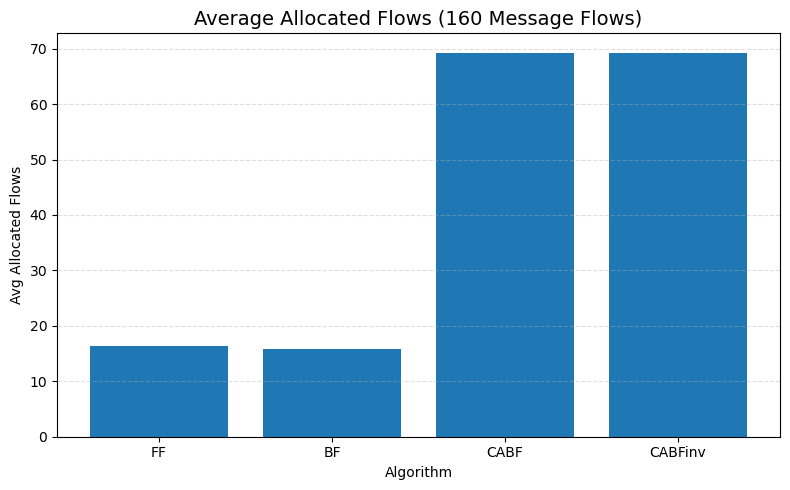

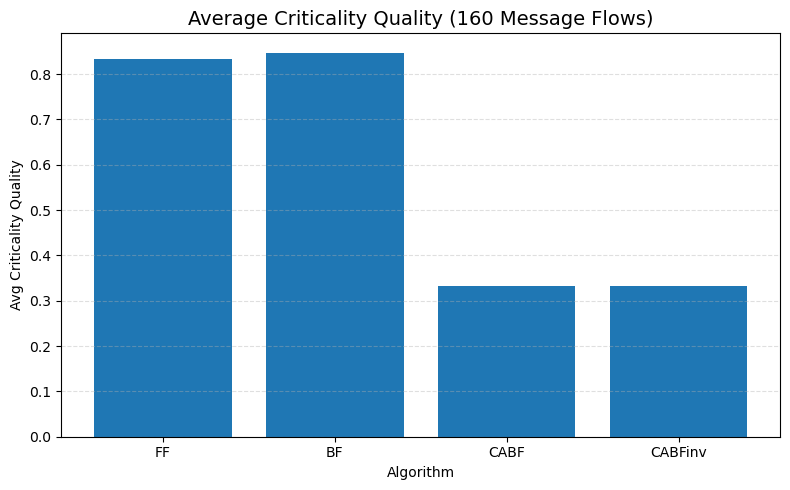

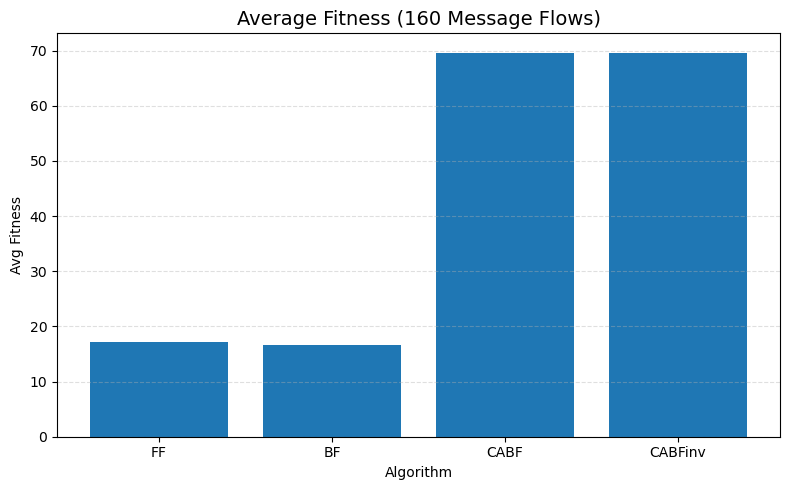

In [ ]:
# ==========================================
# CELL 12 — Benchmark Visualisation
# ==========================================
#
# ==========================================

# Average Allocated Flows
plot_metric(
    df_160,
    "Avg Allocated Flows",
    "Average Allocated Flows (160 Message Flows)"
)

# Average Criticality Quality
plot_metric(
    df_160,
    "Avg Criticality Quality",
    "Average Criticality Quality (160 Message Flows)"
)

# Average Fitness
plot_metric(
    df_160,
    "Avg Fitness",
    "Average Fitness (160 Message Flows)"
)

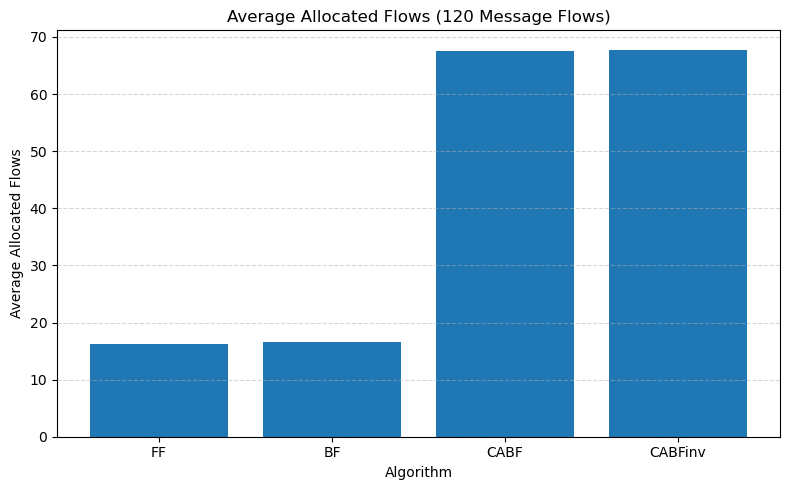

In [ ]:
# ==========================================
# CELL 13 — Example Benchmark Figure
# ==========================================
#
# ==========================================

plt.figure(figsize=(8, 5))

plt.bar(
    df_120["Algorithm"],
    df_120["Avg Allocated Flows"]
)

plt.title("Average Allocated Flows (120 Message Flows)")
plt.xlabel("Algorithm")
plt.ylabel("Average Allocated Flows")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.show()

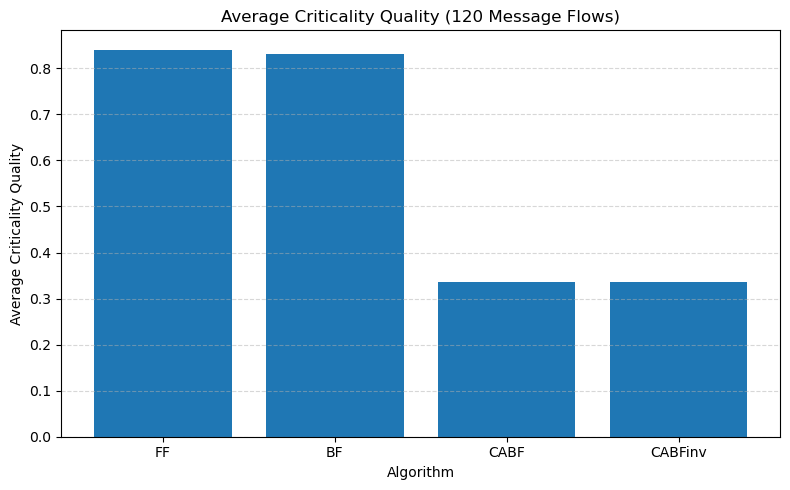

In [ ]:
# ==========================================
# CELL 14 — Example Criticality Quality Figure
# ==========================================
#
# ==========================================

plt.figure(figsize=(8, 5))

plt.bar(
    df_120["Algorithm"],
    df_120["Avg Criticality Quality"]
)

plt.title("Average Criticality Quality (120 Message Flows)")
plt.xlabel("Algorithm")
plt.ylabel("Average Criticality Quality")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.show()

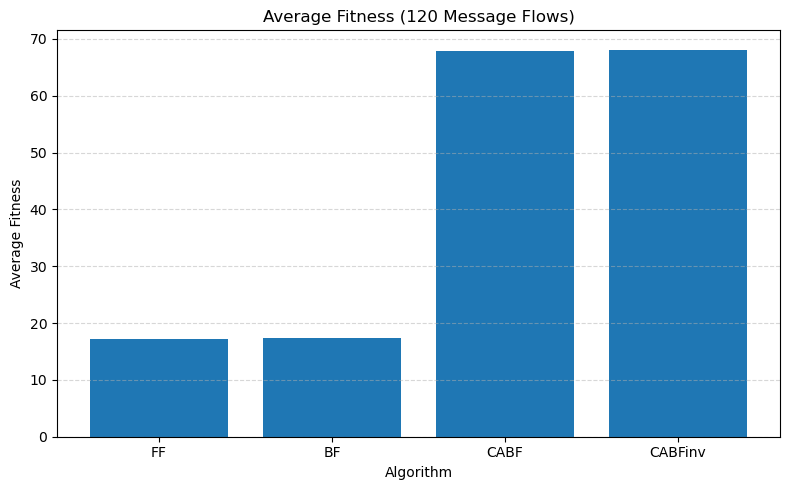

In [ ]:
# ==========================================
# CELL 15 — Example Fitness Figure
# ==========================================
#
# ==========================================

plt.figure(figsize=(8, 5))

plt.bar(
    df_120["Algorithm"],
    df_120["Avg Fitness"]
)

plt.title("Average Fitness (120 Message Flows)")
plt.xlabel("Algorithm")
plt.ylabel("Average Fitness")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.show()

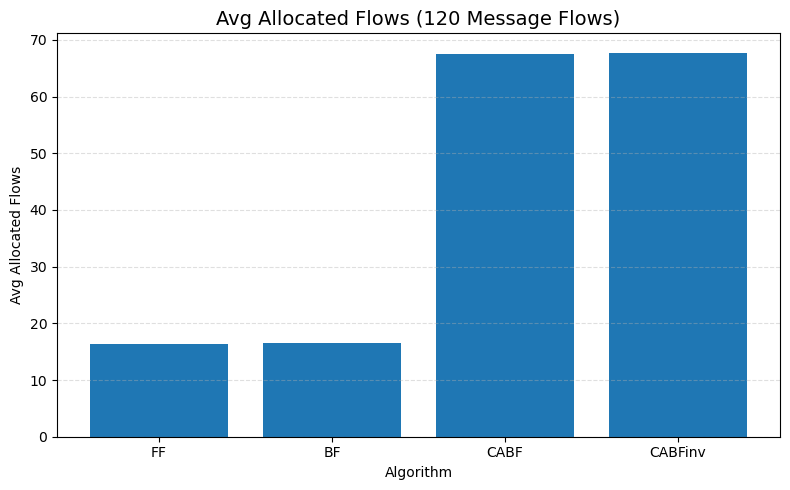

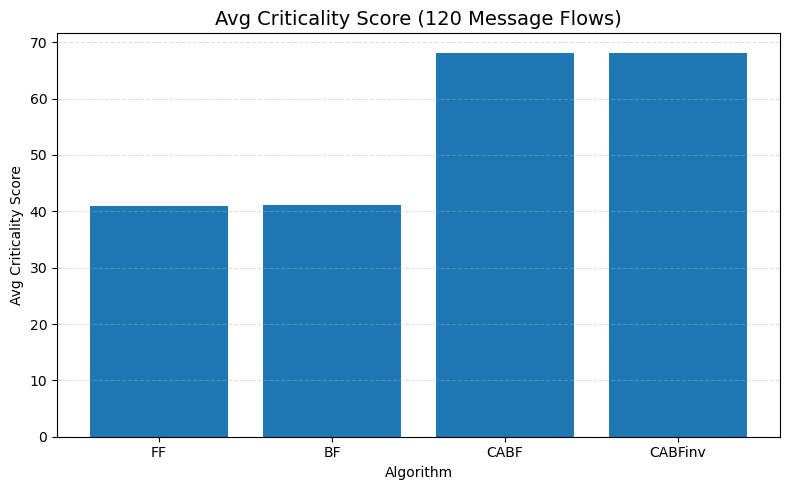

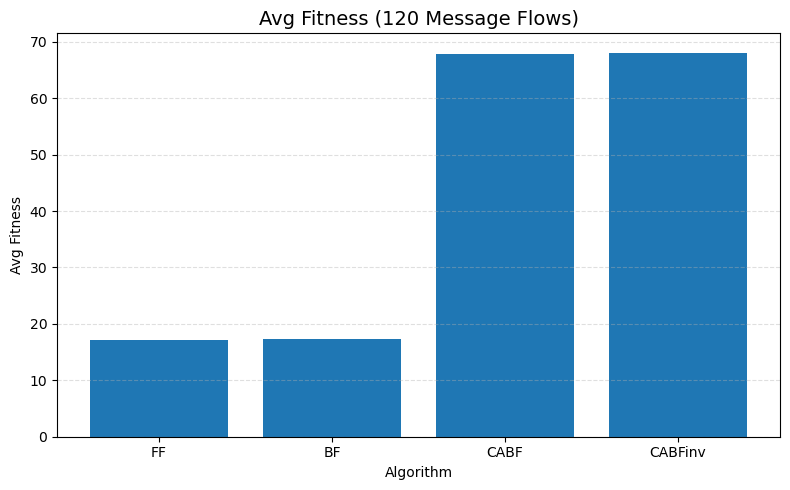

In [ ]:
# ==========================================
# CELL 16 — Multiple Benchmark Figures
# ==========================================
#
# ==========================================

metrics = [
    "Avg Allocated Flows",
    "Avg Criticality Score",
    "Avg Fitness"
]

for metric in metrics:

    plot_metric(
        df_120,
        metric,
        f"{metric} (120 Message Flows)"
    )

In [ ]:
# ==========================================
# CELL 17 — Combine Benchmark Results
# ==========================================
#
# ==========================================

all_results = pd.concat(
    [
        df_20.assign(Flows=20),
        df_40.assign(Flows=40),
        df_80.assign(Flows=80),
        df_120.assign(Flows=120),
        df_160.assign(Flows=160)
    ],
    ignore_index=True
)

# Display the combined benchmark dataset
print(all_results)

   Algorithm  Avg servP  Avg avCL  Avg Allocated Flows  Avg Criticality Score  \
0         FF     0.7333    1.3230                14.67                  39.17   
1         BF     0.7450    1.3511                14.90                  39.40   
2       CABF     0.8200    1.4620                16.40                  41.50   
3    CABFinv     0.9850    1.6738                19.70                  45.83   
4         FF     0.4075    1.4601                16.30                  41.30   
5         BF     0.3958    1.4158                15.83                  40.83   
6       CABF     0.7275    2.0181                29.10                  57.67   
7    CABFinv     0.7992    2.1583                31.97                  58.60   
8         FF     0.2046    1.4276                16.37                  41.93   
9         BF     0.2029    1.4262                16.23                  41.67   
10      CABF     0.6475    2.7399                51.80                  64.67   
11   CABFinv     0.7304    2

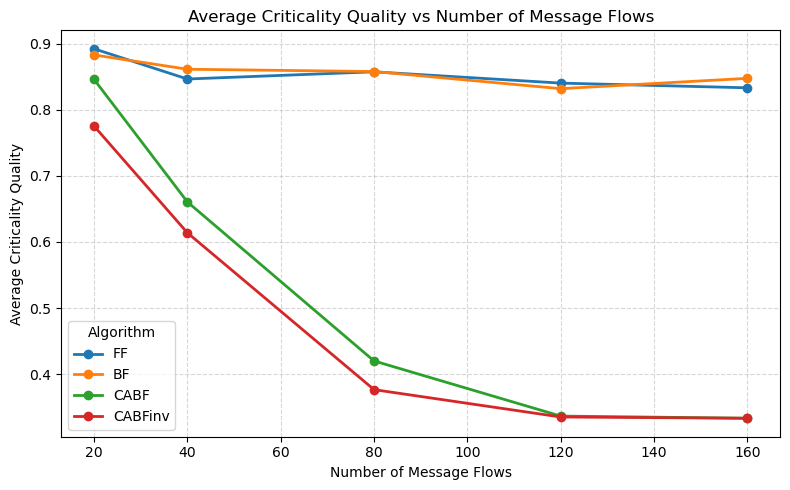

In [ ]:
# ==========================================
# CELL 18 — Criticality Quality Comparison
# ==========================================
#
# ==========================================

plt.figure(figsize=(8, 5))

for algorithm in all_results["Algorithm"].unique():

    data = all_results[
        all_results["Algorithm"] == algorithm
    ]

    plt.plot(
        data["Flows"],
        data["Avg Criticality Quality"],
        marker="o",
        linewidth=2,
        label=algorithm
    )

plt.title("Average Criticality Quality vs Number of Message Flows")
plt.xlabel("Number of Message Flows")
plt.ylabel("Average Criticality Quality")

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.legend(title="Algorithm")

plt.tight_layout()

plt.show()

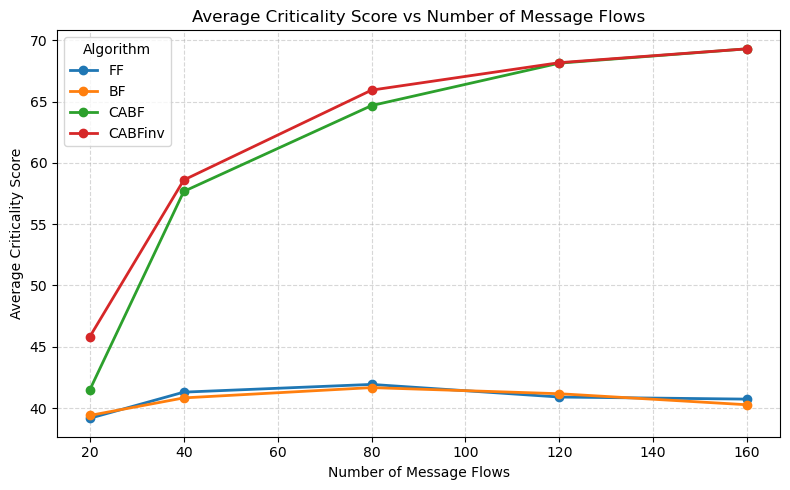

In [ ]:
# ==========================================
# CELL 19 — Criticality Score Comparison
# ==========================================
#
# ==========================================

plt.figure(figsize=(8, 5))

for algorithm in all_results["Algorithm"].unique():

    data = all_results[
        all_results["Algorithm"] == algorithm
    ]

    plt.plot(
        data["Flows"],
        data["Avg Criticality Score"],
        marker="o",
        linewidth=2,
        label=algorithm
    )

plt.title("Average Criticality Score vs Number of Message Flows")
plt.xlabel("Number of Message Flows")
plt.ylabel("Average Criticality Score")

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.legend(title="Algorithm")

plt.tight_layout()

plt.show()

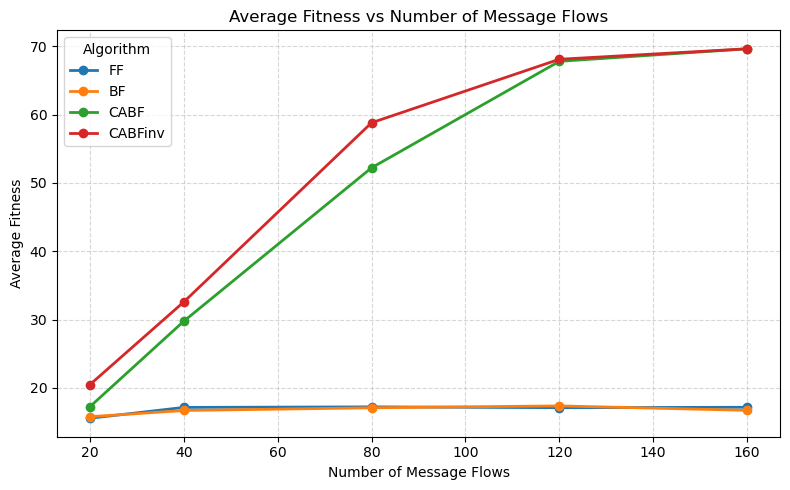

In [ ]:
# ==========================================
# CELL 20 — Fitness Comparison
# ==========================================
#
# ==========================================

plt.figure(figsize=(8, 5))

for algorithm in all_results["Algorithm"].unique():

    data = all_results[
        all_results["Algorithm"] == algorithm
    ]

    plt.plot(
        data["Flows"],
        data["Avg Fitness"],
        marker="o",
        linewidth=2,
        label=algorithm
    )

plt.title("Average Fitness vs Number of Message Flows")
plt.xlabel("Number of Message Flows")
plt.ylabel("Average Fitness")

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.legend(title="Algorithm")

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================
# CELL 18 — Metric vs Number of Message Flows
# ==========================================
#
# ==========================================

def plot_metric_vs_flows(all_results, metric, title):

    plt.figure(figsize=(8, 5))

    for algorithm in all_results["Algorithm"].unique():

        data = all_results[
            all_results["Algorithm"] == algorithm
        ]

        plt.plot(
            data["Flows"],
            data[metric],
            marker="o",
            linewidth=2,
            label=algorithm
        )

    plt.title(title)
    plt.xlabel("Number of Message Flows")
    plt.ylabel(metric)

    plt.grid(
        True,
        linestyle="--",
        alpha=0.5
    )

    plt.legend(title="Algorithm")

    plt.tight_layout()

    plt.show()

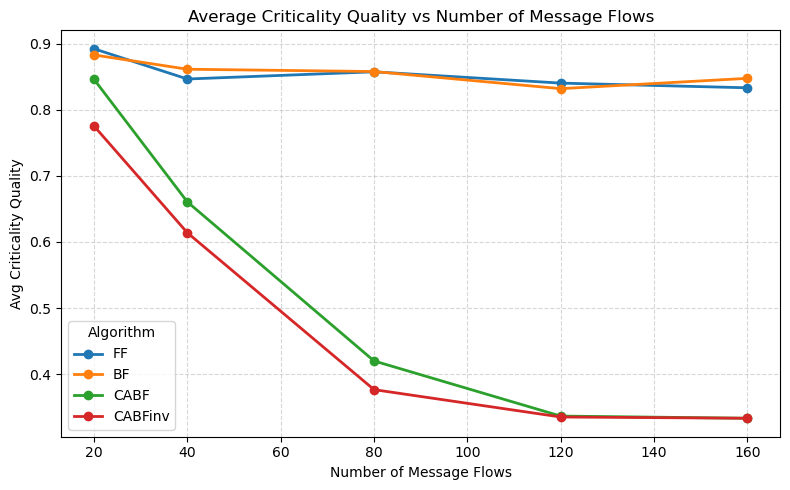

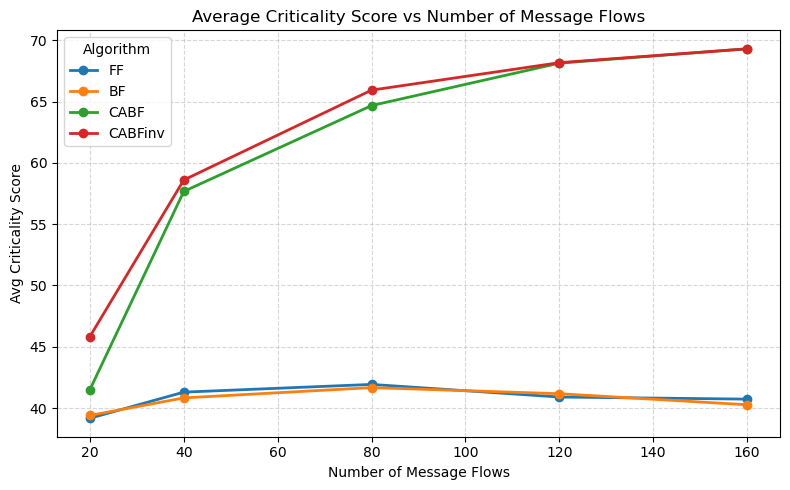

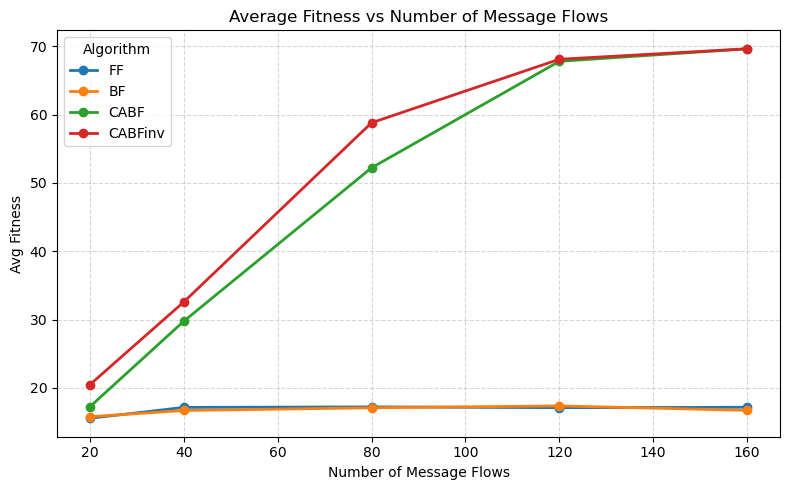

In [ ]:
# ==========================================
# CELL 19 — Benchmark Trend Visualisation
# ==========================================
#
# ==========================================

plot_metric_vs_flows(
    all_results,
    "Avg Criticality Quality",
    "Average Criticality Quality vs Number of Message Flows"
)

plot_metric_vs_flows(
    all_results,
    "Avg Criticality Score",
    "Average Criticality Score vs Number of Message Flows"
)

plot_metric_vs_flows(
    all_results,
    "Avg Fitness",
    "Average Fitness vs Number of Message Flows"
)

In [ ]:
print(type(metrics))
print(metrics)

<class 'list'>
['Avg Allocated Flows', 'Avg Criticality Score', 'Avg Fitness']


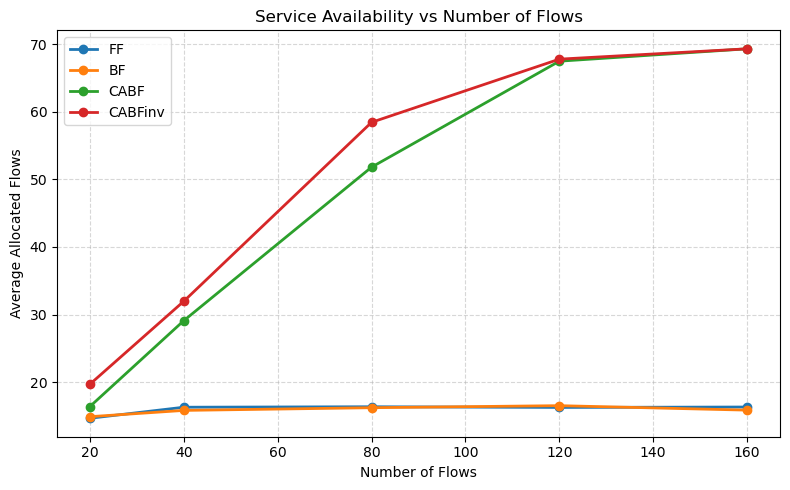

In [ ]:
plt.figure(figsize=(8, 5))

for alg in all_results["Algorithm"].unique():

    data = all_results[
        all_results["Algorithm"] == alg
    ]

    plt.plot(
        data["Flows"],
        data["Avg Allocated Flows"],
        marker="o",
        linewidth=2,
        label=alg
    )

plt.title(
    "Service Availability vs Number of Flows"
)

plt.xlabel("Number of Flows")
plt.ylabel("Average Allocated Flows")

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================
# CELL 21 — GA Random Feasible Solution
# ==========================================
#
# ==========================================

def random_feasible_solution(flows, networks):

    remaining = networks.copy()
    allocation = {}

    flow_names = list(flows.keys())
    random.shuffle(flow_names)

    for flow in flow_names:

        candidate_choices = []

        for level in flows[flow]:

            demand = flows[flow][level]

            for network in networks:

                if remaining[network] >= demand:

                    candidate_choices.append(
                        (network, level)
                    )

        if candidate_choices:

            selected_network, selected_level = random.choice(
                candidate_choices
            )

            allocation[flow] = (
                selected_network,
                selected_level
            )

            remaining[selected_network] -= flows[flow][selected_level]

        else:

            allocation[flow] = (
                None,
                None
            )

    return allocation

In [ ]:
# ==========================================
# CELL 22 — Test Random Feasible Chromosome
# ==========================================
#
# ==========================================

# Generate a test scenario
networks_test, flows_test = generate_scenario(
    num_flows=40
)

# Generate a random feasible chromosome
random_solution = random_feasible_solution(
    flows_test,
    networks_test
)

# Evaluate the chromosome
result = evaluate_solution(
    random_solution,
    flows_test,
    networks_test
)

# Display evaluation metrics
print("Random Feasible Chromosome Evaluation")
print(result)

# Display the distribution of selected criticality levels
levels = [
    level
    for network, level in random_solution.values()
    if level is not None
]

print("\nCriticality-Level Distribution:")
print(Counter(levels))

Random Feasible Chromosome Evaluation
{'servP': 0.675, 'avCL': 1.9259259259259258, 'AllocatedFlows': 27, 'TotalFlows': 40, 'TotalScore': 56, 'CriticalityQuality': 0.691358024691358, 'Fitness': 27.691358024691358, 'CapacityViolation': 0, 'Loads': {'N1': 249, 'N2': 148, 'N3': 98}}

Criticality-Level Distribution:
Counter({1: 11, 3: 9, 2: 7})


In [ ]:
# ==========================================
# CELL 23 — GA Initial Population
# ==========================================

# ==========================================

def create_initial_population(
    flows,
    networks,
    population_size=30
):
    """
    Create the initial population for the
    Enhanced Seeded Genetic Algorithm.
    """

    if population_size < 4:
        raise ValueError(
            "population_size must be at least 4 "
            "to include FF, BF, CABF, and CABFinv."
        )

    population = [

        first_fit(
            flows,
            networks
        ),

        best_fit(
            flows,
            networks
        ),

        cabf(
            flows,
            networks
        ),

        cabf_inv(
            flows,
            networks
        )
    ]

    while len(population) < population_size:

        population.append(

            random_feasible_solution(
                flows,
                networks
            )

        )

    return population

In [ ]:
# ==========================================
# CELL 24 — Test Initial GA Population
# ==========================================
#
# ==========================================

# Generate a test scenario
networks_test, flows_test = generate_scenario(
    num_flows=40
)

# Create the initial GA population
population = create_initial_population(
    flows_test,
    networks_test,
    population_size=30
)

print(f"Population Size : {len(population)}")

# Evaluate every chromosome
fitness_values = []

for chromosome in population:

    result = evaluate_solution(
        chromosome,
        flows_test,
        networks_test
    )

    fitness_values.append(result["Fitness"])

# Display fitness statistics
print(f"Best Fitness    : {max(fitness_values):.4f}")
print(f"Worst Fitness   : {min(fitness_values):.4f}")
print(f"Average Fitness : {sum(fitness_values) / len(fitness_values):.4f}")

Population Size : 30
Best Fitness    : 31.6667
Worst Fitness   : 16.8542
Average Fitness : 23.4462


In [ ]:
# ==========================================
# CELL 25 — Tournament Selection
# ==========================================
#
# ==========================================

def tournament_selection(
    population,
    flows,
    networks,
    tournament_size=3
):
    """
    Select one parent chromosome using
    tournament selection.
    """

    if tournament_size < 1:
        raise ValueError(
            "tournament_size must be at least 1."
        )

    if tournament_size > len(population):
        raise ValueError(
            "tournament_size cannot exceed "
            "the population size."
        )

    # Randomly select tournament competitors
    competitors = random.sample(
        population,
        tournament_size
    )

    # Return the chromosome with the
    # highest fitness
    return max(
        competitors,
        key=lambda chromosome: evaluate_solution(
            chromosome,
            flows,
            networks
        )["Fitness"]
    )

In [ ]:
# ==========================================
# CELL 26 — Test Tournament Selection
# ==========================================
#
# ==========================================

# Select one parent chromosome
selected = tournament_selection(
    population,
    flows_test,
    networks_test,
    tournament_size=3
)

# Evaluate the selected chromosome
selected_result = evaluate_solution(
    selected,
    flows_test,
    networks_test
)

# Display the evaluation metrics
print("Selected Parent Evaluation")
print(selected_result)

Selected Parent Evaluation
{'servP': 0.575, 'avCL': 1.9565217391304348, 'AllocatedFlows': 23, 'TotalFlows': 40, 'TotalScore': 47, 'CriticalityQuality': 0.6811594202898551, 'Fitness': 23.681159420289855, 'CapacityViolation': 0, 'Loads': {'N1': 249, 'N2': 150, 'N3': 98}}


In [ ]:
# ==========================================
# CELL 27 — Uniform Crossover Operator
# ==========================================
#
# ==========================================

def crossover(parent1, parent2, flows):
    """
    Create one child chromosome using uniform crossover.

    Parameters
    ----------
    parent1 : dict
        First parent chromosome.
    parent2 : dict
        Second parent chromosome.
    flows : dict
        Message-flow definitions.

    Returns
    -------
    dict
        Child chromosome produced by uniform crossover.
    """

    child = {}

    for flow in flows:
        if random.random() < 0.5:
            child[flow] = parent1[flow]
        else:
            child[flow] = parent2[flow]

    return child

In [ ]:
# ==========================================
# CELL 28 — Migration-Aware Repair Function
# ==========================================
#
# ==========================================

def repair_solution(allocation, flows, networks):
    """
    Repair an infeasible chromosome using QoS degradation
    and network migration.

    Parameters
    ----------
    allocation : dict
        Candidate chromosome in the form:
        allocation[flow] = (network, level)

    flows : dict
        Message-flow bandwidth profiles.

    networks : dict
        Communication-network capacities.

    Returns
    -------
    dict
        A feasible repaired chromosome.
    """

    repaired = allocation.copy()

    # --------------------------------------------------
    # Step 1: Validate every gene
    # --------------------------------------------------
    for flow in flows:

        decision = repaired.get(flow, (None, None))
        network, level = decision

        if network is None or level is None:
            repaired[flow] = (None, None)
            continue

        if (
            network not in networks
            or level not in flows[flow]
        ):
            repaired[flow] = (None, None)

    # --------------------------------------------------
    #  Compare candidate repair actions
    # --------------------------------------------------
    def repair_score(candidate):
        """
        Higher tuple values represent better repair actions.

        Priority:
        1. Reduce capacity violation.
        2. Preserve allocated flows.
        3. Preserve criticality quality.
        """

        result = evaluate_solution(
            candidate,
            flows,
            networks
        )

        return (
            -result["CapacityViolation"],
            result["AllocatedFlows"],
            result["CriticalityQuality"]
        )

    # --------------------------------------------------
    # Step 2: Iteratively remove capacity violations
    # --------------------------------------------------
    while True:

        current_result = evaluate_solution(
            repaired,
            flows,
            networks
        )

        if current_result["CapacityViolation"] == 0:
            break

        loads = current_result["Loads"]

        overloaded_networks = [
            network
            for network in networks
            if loads[network] > networks[network]
        ]

        best_candidate = None
        best_score = repair_score(repaired)

        # --------------------------------------------------
        # Step 3: Examine flows on overloaded networks
        # --------------------------------------------------
        for overloaded_network in overloaded_networks:

            candidate_flows = []

            for flow, decision in repaired.items():

                network, level = decision

                if (
                    network == overloaded_network
                    and level is not None
                    and level in flows[flow]
                ):
                    demand = flows[flow][level]

                    candidate_flows.append(
                        (flow, level, demand)
                    )

            
            candidate_flows.sort(
                key=lambda item: item[2],
                reverse=True
            )

            for flow, current_level, current_demand in candidate_flows:

                

                for alternative_network in networks:

                    if alternative_network == overloaded_network:
                        continue

                    candidate = repaired.copy()

                    candidate[flow] = (
                        alternative_network,
                        current_level
                    )

                    candidate_score = repair_score(candidate)

                    if candidate_score > best_score:
                        best_candidate = candidate
                        best_score = candidate_score

                # Identify lower-bandwidth QoS levels
                lower_qos_levels = [
                    level
                    for level in sorted(flows[flow].keys())
                    if level > current_level
                ]

                for lower_level in lower_qos_levels:

                    # ======================================
                    #
                    # Degrade QoS on the current network
                    # ======================================

                    candidate = repaired.copy()

                    candidate[flow] = (
                        overloaded_network,
                        lower_level
                    )

                    candidate_score = repair_score(candidate)

                    if candidate_score > best_score:
                        best_candidate = candidate
                        best_score = candidate_score

                    # ======================================
                    # 
                    # Migrate and degrade QoS
                    # ======================================

                    for alternative_network in networks:

                        if alternative_network == overloaded_network:
                            continue

                        candidate = repaired.copy()

                        candidate[flow] = (
                            alternative_network,
                            lower_level
                        )

                        candidate_score = repair_score(candidate)

                        if candidate_score > best_score:
                            best_candidate = candidate
                            best_score = candidate_score

                # ==========================================
                # 
                # Drop the flow as the final option
                # ==========================================

                candidate = repaired.copy()

                candidate[flow] = (
                    None,
                    None
                )

                candidate_score = repair_score(candidate)

                if candidate_score > best_score:
                    best_candidate = candidate
                    best_score = candidate_score

        # --------------------------------------------------
        # Step 4: Apply the best repair action
        # --------------------------------------------------
        if best_candidate is None:
            # Defensive fallback:
            # drop the largest flow on an overloaded network
            fallback_applied = False

            for overloaded_network in overloaded_networks:

                assigned_flows = [
                    (
                        flow,
                        flows[flow][level]
                    )
                    for flow, (network, level) in repaired.items()
                    if (
                        network == overloaded_network
                        and level is not None
                    )
                ]

                if assigned_flows:

                    flow_to_drop = max(
                        assigned_flows,
                        key=lambda item: item[1]
                    )[0]

                    repaired[flow_to_drop] = (
                        None,
                        None
                    )

                    fallback_applied = True
                    break

            if not fallback_applied:
                break

        else:
            repaired = best_candidate

    return repaired

In [ ]:
# ==========================================
# CELL 29 — Test Crossover and Repair
# 
# ==========================================

# Select two parent chromosomes
parent1 = tournament_selection(
    population,
    flows_test,
    networks_test
)

parent2 = tournament_selection(
    population,
    flows_test,
    networks_test
)

# Generate one offspring using crossover only
child_unrepaired = crossover(
    parent1,
    parent2,
    flows_test
)

# Evaluate the child before repair
before_repair = evaluate_solution(
    child_unrepaired,
    flows_test,
    networks_test
)

# 
child = repair_solution(
    child_unrepaired,
    flows_test,
    networks_test
)

# Evaluate the repaired offspring
after_repair = evaluate_solution(
    child,
    flows_test,
    networks_test
)

# Display evaluation metrics
print("=" * 60)
print("Child Chromosome Before Repair")
print("=" * 60)
print(before_repair)

print("\n" + "=" * 60)
print("Child Chromosome After Repair")
print("=" * 60)
print(after_repair)

# 
levels = [
    level
    for network, level in child.values()
    if level is not None
]

print("\nCriticality-Level Distribution After Repair:")
print(Counter(levels))

# Explicit feasibility check
assert after_repair["CapacityViolation"] == 0, (
    "Repair failed: the child chromosome remains infeasible."
)

print("\nRepair validation passed: the child is feasible.")

Child Chromosome Before Repair
{'servP': 0.775, 'avCL': 2.032258064516129, 'AllocatedFlows': 31, 'TotalFlows': 40, 'TotalScore': 61, 'CriticalityQuality': 0.6559139784946236, 'Fitness': 31.655913978494624, 'CapacityViolation': 0, 'Loads': {'N1': 237, 'N2': 144, 'N3': 94}}

Child Chromosome After Repair
{'servP': 0.775, 'avCL': 2.032258064516129, 'AllocatedFlows': 31, 'TotalFlows': 40, 'TotalScore': 61, 'CriticalityQuality': 0.6559139784946236, 'Fitness': 31.655913978494624, 'CapacityViolation': 0, 'Loads': {'N1': 237, 'N2': 144, 'N3': 94}}

Criticality-Level Distribution After Repair:
Counter({2: 30, 3: 1})

Repair validation passed: the child is feasible.


In [ ]:
# ==========================================
# CELL 30 — Mutation Operator
# ==========================================
#
# Randomly modifies genes within a chromosome
# to maintain genetic diversity.
#
# Each gene represents:
#
#   Gene_m = (N_m, L_m)
#
#
# ==========================================

def mutate(
    chromosome,
    flows,
    networks,
    mutation_rate=0.05
):
    """
    Mutate a chromosome by randomly modifying selected genes.

    Parameters
    ----------
    chromosome : dict
        Candidate allocation chromosome.

    flows : dict
        Message-flow bandwidth profiles.

    networks : dict
        Communication-network capacities.

    mutation_rate : float, optional
        Probability of mutating each gene.

    Returns
    -------
    dict
        Mutated chromosome, which may temporarily be infeasible.
    """

    mutated = chromosome.copy()

    for flow in flows:

        if random.random() < mutation_rate:

            candidate_choices = [
                (network, level)
                for level in flows[flow]
                for network in networks
            ]

            # Allow the flow to be unallocated
            candidate_choices.append((None, None))

            # Avoid selecting the current value when possible
            current_gene = mutated.get(flow, (None, None))

            alternative_choices = [
                choice
                for choice in candidate_choices
                if choice != current_gene
            ]

            if alternative_choices:
                mutated[flow] = random.choice(
                    alternative_choices
                )

    return mutated

In [ ]:
# ==========================================
# CELL 31 — Test Mutation and Repair
# ==========================================
#
# ==========================================

# Apply mutation only
mutated_unrepaired = mutate(
    child,
    flows_test,
    networks_test,
    mutation_rate=0.10
)

# Evaluate before repair
before_repair = evaluate_solution(
    mutated_unrepaired,
    flows_test,
    networks_test
)

# Apply migration-aware repair
mutated_child = repair_solution(
    mutated_unrepaired,
    flows_test,
    networks_test
)

# Evaluate after repair
after_repair = evaluate_solution(
    mutated_child,
    flows_test,
    networks_test
)

# Display results
print("=" * 60)
print("Mutated Child Before Repair")
print("=" * 60)
print(before_repair)

print("\n" + "=" * 60)
print("Mutated Child After Repair")
print("=" * 60)
print(after_repair)

# Display criticality-level distribution
levels = [
    level
    for network, level in mutated_child.values()
    if level is not None
]

print("\nCriticality-Level Distribution After Repair:")
print(Counter(levels))

# Validate feasibility
assert after_repair["CapacityViolation"] == 0, (
    "Repair failed: the mutated chromosome remains infeasible."
)

print("\nMutation and repair validation passed.")

Mutated Child Before Repair
{'servP': 0.775, 'avCL': 2.129032258064516, 'AllocatedFlows': 31, 'TotalFlows': 40, 'TotalScore': 58, 'CriticalityQuality': 0.6236559139784946, 'Fitness': 31.623655913978496, 'CapacityViolation': 0, 'Loads': {'N1': 241, 'N2': 150, 'N3': 70}}

Mutated Child After Repair
{'servP': 0.775, 'avCL': 2.129032258064516, 'AllocatedFlows': 31, 'TotalFlows': 40, 'TotalScore': 58, 'CriticalityQuality': 0.6236559139784946, 'Fitness': 31.623655913978496, 'CapacityViolation': 0, 'Loads': {'N1': 241, 'N2': 150, 'N3': 70}}

Criticality-Level Distribution After Repair:
Counter({2: 27, 3: 4})

Mutation and repair validation passed.


In [ ]:
# ==========================================
# CELL 32 — Iterative Local Improvement
# ==========================================
#
# ==========================================

def improve_solution(
    allocation,
    flows,
    networks,
    max_passes=5
):
    """
    Apply iterative best-improvement local search
    to a feasible chromosome.

    Parameters
    ----------
    allocation : dict
        Candidate chromosome represented as:
        allocation[flow] = (network, level)

    flows : dict
        Message-flow bandwidth-demand profiles.

    networks : dict
        Communication-network capacities.

    max_passes : int, optional
        Maximum number of local-search passes.

    Returns
    -------
    dict
        Locally improved feasible chromosome.
    """

    if max_passes < 0:
        raise ValueError(
            "max_passes cannot be negative."
        )

    # Ensure that local improvement starts
    # from a feasible chromosome.
    improved = repair_solution(
        allocation.copy(),
        flows,
        networks
    )

    def candidate_score(solution):
        """
        Return the optimisation score of a
        feasible candidate solution.
        """

        result = evaluate_solution(
            solution,
            flows,
            networks
        )

        if result["CapacityViolation"] > 0:
            return None

        return (
            result["Fitness"],
            result["AllocatedFlows"],
            result["CriticalityQuality"],
            -result["avCL"]
        )

    current_score = candidate_score(improved)

    if current_score is None:
        raise ValueError(
            "Local improvement requires "
            "a feasible chromosome."
        )

    for _ in range(max_passes):

        best_candidate = None
        best_score = current_score

        # --------------------------------------
        # Move 1 — Admit a dropped flow
        # --------------------------------------
        for flow in flows:

            current_network, current_level = improved.get(
                flow,
                (None, None)
            )

            if (
                current_network is not None
                and current_level is not None
            ):
                continue

            # Try minimum-bandwidth levels first:
            # L3 → L2 → L1
            for level in sorted(
                flows[flow].keys(),
                reverse=True
            ):

                for network in networks:

                    candidate = improved.copy()

                    candidate[flow] = (
                        network,
                        level
                    )

                    score = candidate_score(
                        candidate
                    )

                    if (
                        score is not None
                        and score > best_score
                    ):
                        best_candidate = candidate
                        best_score = score

        # --------------------------------------
        # Move 2 — Upgrade on current network
        # --------------------------------------
        for flow, decision in improved.items():

            network, level = decision

            if network is None or level is None:
                continue

            better_levels = [
                candidate_level
                for candidate_level in sorted(
                    flows[flow].keys()
                )
                if candidate_level < level
            ]

            for better_level in better_levels:

                candidate = improved.copy()

                candidate[flow] = (
                    network,
                    better_level
                )

                score = candidate_score(
                    candidate
                )

                if (
                    score is not None
                    and score > best_score
                ):
                    best_candidate = candidate
                    best_score = score

        # --------------------------------------
        # Move 3 — Migrate and upgrade QoS
        # --------------------------------------
        for flow, decision in improved.items():

            current_network, current_level = decision

            if (
                current_network is None
                or current_level is None
            ):
                continue

            better_levels = [
                candidate_level
                for candidate_level in sorted(
                    flows[flow].keys()
                )
                if candidate_level < current_level
            ]

            for better_level in better_levels:

                for alternative_network in networks:

                    if (
                        alternative_network
                        == current_network
                    ):
                        continue

                    candidate = improved.copy()

                    candidate[flow] = (
                        alternative_network,
                        better_level
                    )

                    score = candidate_score(
                        candidate
                    )

                    if (
                        score is not None
                        and score > best_score
                    ):
                        best_candidate = candidate
                        best_score = score

        # Stop when no improving move remains
        if best_candidate is None:
            break

        improved = best_candidate
        current_score = best_score

    return improved

In [ ]:
# ==========================================
# CELL 33 — Full Enhanced Seeded Genetic Algorithm
# ==========================================
#
# 
# ==========================================

def run_ga(
    flows,
    networks,
    population_size=30,
    generations=50,
    mutation_rate=0.05,
    tournament_size=3,
    local_search_passes=5,
    show_progress=False
):
    """
    Run the Enhanced Seeded Genetic Algorithm.

    Parameters
    ----------
    flows : dict
        Message-flow bandwidth-demand profiles.

    networks : dict
        Communication-network capacities.

    population_size : int, optional
        Number of chromosomes in the population.

    generations : int, optional
        Number of evolutionary generations.

    mutation_rate : float, optional
        Probability of mutating each gene.

    tournament_size : int, optional
        Number of chromosomes sampled during
        tournament selection.

    local_search_passes : int, optional
        Maximum number of local-improvement passes.

    show_progress : bool, optional
        Display generation progress during execution.

    Returns
    -------
    tuple
        best_solution,
        best_result,
        best_fitness_history,
        avg_fitness_history
    """

    # --------------------------------------
    # Validate parameters
    # --------------------------------------
    if population_size < 4:
        raise ValueError(
            "population_size must be at least 4 "
            "to include all heuristic seed chromosomes."
        )

    if generations < 1:
        raise ValueError(
            "generations must be at least 1."
        )

    if not 0 <= mutation_rate <= 1:
        raise ValueError(
            "mutation_rate must be between 0 and 1."
        )

    if tournament_size < 1:
        raise ValueError(
            "tournament_size must be at least 1."
        )

    if tournament_size > population_size:
        raise ValueError(
            "tournament_size cannot exceed "
            "population_size."
        )

    if local_search_passes < 0:
        raise ValueError(
            "local_search_passes cannot be negative."
        )

    # --------------------------------------
    # Create the seeded initial population
    # --------------------------------------
    population = create_initial_population(
        flows,
        networks,
        population_size=population_size
    )

    # Defensive feasibility restoration
    population = [
        repair_solution(
            chromosome,
            flows,
            networks
        )
        for chromosome in population
    ]

    best_solution = None
    best_fitness = float("-inf")

    best_fitness_history = []
    avg_fitness_history = []

    # --------------------------------------
    # Evolutionary cycle
    # --------------------------------------
    for generation in range(generations):

        if show_progress and (
            generation == 0
            or (generation + 1) % 10 == 0
            or generation + 1 == generations
        ):
            print(
                f"Generation "
                f"{generation + 1}/{generations}",
                flush=True
            )

        evaluated_population = []

        # Evaluate the current population
        for chromosome in population:

            result = evaluate_solution(
                chromosome,
                flows,
                networks
            )

            evaluated_population.append(
                (
                    chromosome,
                    result["Fitness"]
                )
            )

        evaluated_population.sort(
            key=lambda item: item[1],
            reverse=True
        )

        generation_best_solution = (
            evaluated_population[0][0].copy()
        )

        generation_best_fitness = (
            evaluated_population[0][1]
        )

        generation_avg_fitness = (
            sum(
                fitness
                for _, fitness in evaluated_population
            )
            / len(evaluated_population)
        )

        # Update global best solution
        if generation_best_fitness > best_fitness:

            best_solution = (
                generation_best_solution.copy()
            )

            best_fitness = generation_best_fitness

        best_fitness_history.append(
            best_fitness
        )

        avg_fitness_history.append(
            generation_avg_fitness
        )

        # --------------------------------------
        # Elitism
        # --------------------------------------
        new_population = [
            generation_best_solution.copy()
        ]

        current_population = [
            chromosome
            for chromosome, _ in evaluated_population
        ]

        # --------------------------------------
        # Generate offspring
        # --------------------------------------
        while len(new_population) < population_size:

            parent1 = tournament_selection(
                current_population,
                flows,
                networks,
                tournament_size=tournament_size
            )

            parent2 = tournament_selection(
                current_population,
                flows,
                networks,
                tournament_size=tournament_size
            )

            # Uniform crossover
            child = crossover(
                parent1,
                parent2,
                flows
            )

            # Mutation
            child = mutate(
                child,
                flows,
                networks,
                mutation_rate=mutation_rate
            )

            # Feasibility restoration
            child = repair_solution(
                child,
                flows,
                networks
            )

            # Local refinement
            child = improve_solution(
                child,
                flows,
                networks,
                max_passes=local_search_passes
            )

            # Defensive feasibility check
            child_result = evaluate_solution(
                child,
                flows,
                networks
            )

            if child_result["CapacityViolation"] != 0:
                raise RuntimeError(
                    "An infeasible offspring remained "
                    "after repair and local improvement."
                )

            new_population.append(
                child.copy()
            )

        population = new_population

    # --------------------------------------
    # Final global-best evaluation
    # --------------------------------------
    best_result = evaluate_solution(
        best_solution,
        flows,
        networks
    )

    return (
        best_solution,
        best_result,
        best_fitness_history,
        avg_fitness_history
    )

In [ ]:
# ==========================================
# CELL 34 — Test Enhanced Seeded Genetic Algorithm
# ==========================================
#
# ==========================================

# Generate a synthetic test scenario
networks_ga, flows_ga = generate_scenario(
    num_flows=40
)

# Execute the enhanced GA
ga_solution, ga_result, best_history, avg_history = run_ga(
    flows_ga,
    networks_ga,
    population_size=30,
    generations=50,
    mutation_rate=0.05,
    tournament_size=3,
    local_search_passes=100
)

# ------------------------------------------
# Display the final evaluation
# ------------------------------------------
print("=" * 70)
print("Enhanced Seeded Genetic Algorithm Result")
print("=" * 70)
print(ga_result)

# ------------------------------------------
# Display the criticality-level distribution
# ------------------------------------------
levels = [
    level
    for network, level in ga_solution.values()
    if level is not None
]

print("\nCriticality-Level Distribution:")
print(Counter(levels))

# ------------------------------------------
# Display network loads
# ------------------------------------------
print("\nFinal Network Loads:")

for network in networks_ga:
    print(
        f"{network}: "
        f"{ga_result['Loads'][network]} / "
        f"{networks_ga[network]}"
    )

# ------------------------------------------
# Validate the final solution
# ------------------------------------------
assert ga_result["CapacityViolation"] == 0, (
    "The final GA solution is infeasible."
)

assert len(ga_solution) == len(flows_ga), (
    "The final chromosome does not contain "
    "one gene for every message flow."
)

assert len(best_history) == 50, (
    "Best-fitness history length does not match "
    "the number of generations."
)

assert len(avg_history) == 50, (
    "Average-fitness history length does not match "
    "the number of generations."
)

# Elitism should prevent the global-best history
# from decreasing over generations.
assert all(
    best_history[index] >= best_history[index - 1]
    for index in range(1, len(best_history))
), (
    "Best-fitness history decreased despite elitism."
)

print("\nEnhanced GA validation passed.")
print(
    f"Best fitness: {ga_result['Fitness']:.4f}"
)
print(
    f"Allocated flows: "
    f"{ga_result['AllocatedFlows']} / "
    f"{ga_result['TotalFlows']}"
)
print(
    f"Service percentage: "
    f"{ga_result['servP']:.4f}"
)
print(
    f"Average criticality level: "
    f"{ga_result['avCL']:.4f}"
)

Enhanced Seeded Genetic Algorithm Result
{'servP': 0.925, 'avCL': 2.4324324324324325, 'AllocatedFlows': 37, 'TotalFlows': 40, 'TotalScore': 58, 'CriticalityQuality': 0.5225225225225225, 'Fitness': 37.52252252252252, 'CapacityViolation': 0, 'Loads': {'N1': 250, 'N2': 149, 'N3': 99}}

Criticality-Level Distribution:
Counter({3: 20, 2: 13, 1: 4})

Final Network Loads:
N1: 250 / 250
N2: 149 / 150
N3: 99 / 100

Enhanced GA validation passed.
Best fitness: 37.5225
Allocated flows: 37 / 40
Service percentage: 0.9250
Average criticality level: 2.4324


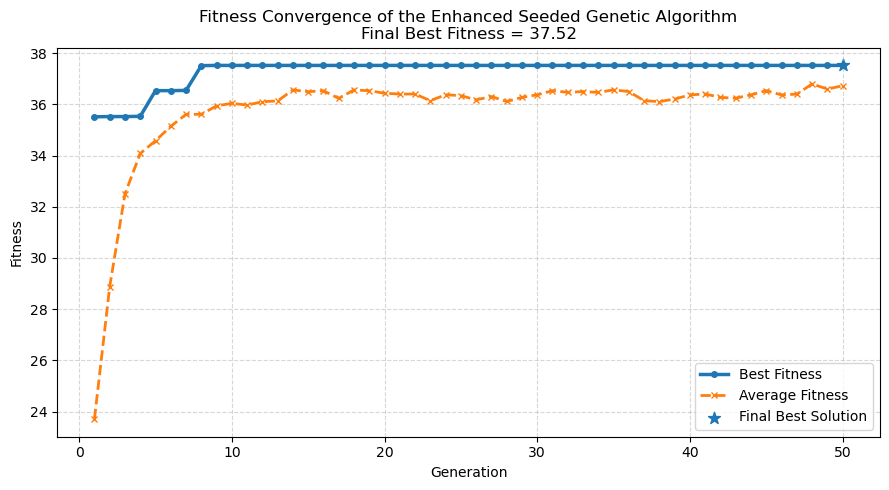

In [ ]:
# ==========================================
# CELL 35 — Fitness Convergence Analysis
# ==========================================
#
# ==========================================

generation_numbers = range(
    1,
    len(best_history) + 1
)

plt.figure(figsize=(9, 5))

# Best fitness history
plt.plot(
    generation_numbers,
    best_history,
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Best Fitness"
)

# Average population fitness history
plt.plot(
    generation_numbers,
    avg_history,
    linewidth=2,
    linestyle="--",
    marker="x",
    markersize=4,
    label="Average Fitness"
)

# Highlight the final best solution
plt.scatter(
    generation_numbers[-1],
    best_history[-1],
    s=80,
    marker="*",
    label="Final Best Solution"
)

plt.title(
    "Fitness Convergence of the Enhanced Seeded Genetic Algorithm\n"
    f"Final Best Fitness = {best_history[-1]:.2f}"
)

plt.xlabel("Generation")
plt.ylabel("Fitness")

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "GA_Fitness_Convergence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ==========================================
# CELL 36 — Enhanced GA vs Baselines
# Intensive Single-Scenario Comparison
# ==========================================
#
# ==========================================

import time

# ------------------------------------------
# Reproducible comparison scenario
# ------------------------------------------
random.seed(42)

networks_cmp, flows_cmp = generate_scenario(
    num_flows=120
)

comparison_results = []

# ------------------------------------------
# Baseline algorithms
# ------------------------------------------
baseline_algorithms = {
    "FF": first_fit,
    "BF": best_fit,
    "CABF": cabf,
    "CABFinv": cabf_inv
}

for algorithm_name, algorithm in baseline_algorithms.items():

    start_time = time.perf_counter()

    solution = algorithm(
        flows_cmp,
        networks_cmp
    )

    execution_time = (
        time.perf_counter() - start_time
    )

    result = evaluate_solution(
        solution,
        flows_cmp,
        networks_cmp
    )

    comparison_results.append({
        "Algorithm": algorithm_name,
        "servP": result["servP"],
        "avCL": result["avCL"],
        "Allocated Flows": result["AllocatedFlows"],
        "Criticality Score": result["TotalScore"],
        "Criticality Quality": result["CriticalityQuality"],
        "Fitness": result["Fitness"],
        "Capacity Violation": result["CapacityViolation"],
        "Execution Time (s)": execution_time
    })

# ------------------------------------------
# Enhanced Seeded Genetic Algorithm
# ------------------------------------------
start_time = time.perf_counter()

(
    ga_solution_cmp,
    ga_result_cmp,
    best_history_cmp,
    avg_history_cmp
) = run_ga(
    flows_cmp,
    networks_cmp,
    population_size=50,
    generations=100,
    mutation_rate=0.08,
    tournament_size=3,
    local_search_passes=5,
    show_progress=True
)

ga_execution_time = (
    time.perf_counter() - start_time
)

comparison_results.append({
    "Algorithm": "Enhanced Seeded GA",
    "servP": ga_result_cmp["servP"],
    "avCL": ga_result_cmp["avCL"],
    "Allocated Flows": ga_result_cmp["AllocatedFlows"],
    "Criticality Score": ga_result_cmp["TotalScore"],
    "Criticality Quality": ga_result_cmp["CriticalityQuality"],
    "Fitness": ga_result_cmp["Fitness"],
    "Capacity Violation": ga_result_cmp["CapacityViolation"],
    "Execution Time (s)": ga_execution_time
})

# ------------------------------------------
# Create the comparison table
# ------------------------------------------
comparison_df = pd.DataFrame(
    comparison_results
)

comparison_df = comparison_df.round({
    "servP": 4,
    "avCL": 4,
    "Criticality Quality": 4,
    "Fitness": 4,
    "Execution Time (s)": 6
})

comparison_df = comparison_df.sort_values(
    by="Fitness",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------
# Display results
# ------------------------------------------
print("\n" + "=" * 110)
print(
    "Enhanced Seeded GA vs Baseline Algorithms "
    "— 120 Message Flows"
)
print("=" * 110)

print(
    comparison_df.to_string(
        index=False
    )
)

# ------------------------------------------
# Validate feasibility
# ------------------------------------------
assert (
    comparison_df["Capacity Violation"] == 0
).all(), (
    "At least one algorithm produced "
    "an infeasible solution."
)

print("\nComparison validation passed: all solutions are feasible.")

Generation 1/100
Generation 10/100
Generation 20/100
Generation 30/100
Generation 40/100
Generation 50/100
Generation 60/100
Generation 70/100
Generation 80/100
Generation 90/100
Generation 100/100

Enhanced Seeded GA vs Baseline Algorithms — 120 Message Flows
         Algorithm  servP   avCL  Allocated Flows  Criticality Score  Criticality Quality  Fitness  Capacity Violation  Execution Time (s)
Enhanced Seeded GA 0.6167 2.8919               74                 82               0.3694  74.3694                   0          140.688492
              CABF 0.5833 3.0000               70                 70               0.3333  70.3333                   0            0.000098
           CABFinv 0.5833 3.0000               70                 70               0.3333  70.3333                   0            0.000095
                BF 0.1417 1.5882               17                 41               0.8039  17.8039                   0            0.000046
                FF 0.1333 1.4375            

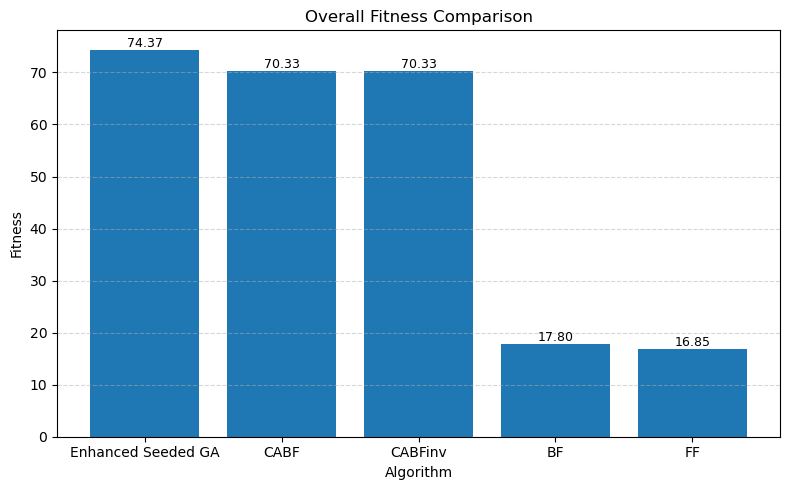

In [ ]:
# ==========================================
# CELL 37 — Overall Fitness Comparison
# ==========================================
#
# ==========================================

plot_df = comparison_df.sort_values(
    by="Fitness",
    ascending=False
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    plot_df["Algorithm"],
    plot_df["Fitness"]
)

# Display fitness values above each bar
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.2f}",
        ha="center",
        fontsize=9
    )

plt.title("Overall Fitness Comparison")

plt.xlabel("Algorithm")
plt.ylabel("Fitness")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    "Fitness_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

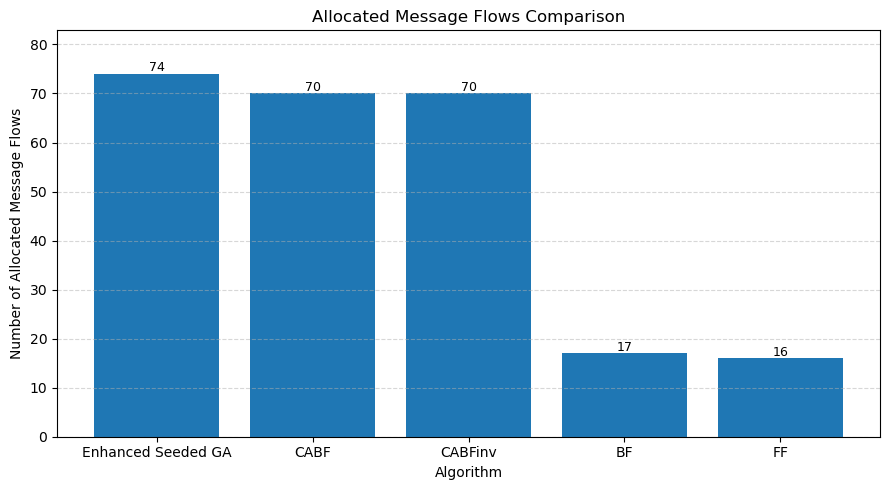

In [ ]:
# ==========================================
# CELL 38 — Allocated Flows Comparison
# 
# ==========================================

plot_df = comparison_df.sort_values(
    by="Allocated Flows",
    ascending=False
)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    plot_df["Algorithm"],
    plot_df["Allocated Flows"]
)

# Display allocated-flow values above each bar
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{int(height)}",
        ha="center",
        fontsize=9
    )

plt.title(
    "Allocated Message Flows Comparison"
)

plt.xlabel("Algorithm")
plt.ylabel("Number of Allocated Message Flows")

plt.ylim(
    0,
    max(plot_df["Allocated Flows"]) * 1.12
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    "Allocated_Flows_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

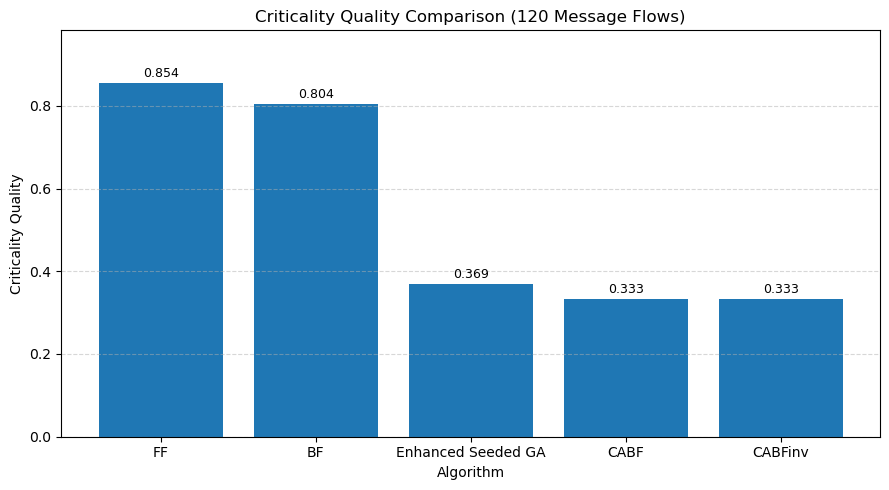

In [ ]:
# ==========================================
# CELL 39 — Criticality Quality Comparison
# ==========================================
#
# ==========================================

plot_df = comparison_df.sort_values(
    by="Criticality Quality",
    ascending=False
)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    plot_df["Algorithm"],
    plot_df["Criticality Quality"]
)

# Display values above each bar
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.015,
        f"{height:.3f}",
        ha="center",
        fontsize=9
    )

plt.title(
    f"Criticality Quality Comparison ({len(flows_cmp)} Message Flows)"
)

plt.xlabel("Algorithm")
plt.ylabel("Criticality Quality")

plt.ylim(
    0,
    max(plot_df["Criticality Quality"]) * 1.15
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    "Criticality_Quality_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ==========================================
# CELL 40 — Large-Scale GA Validation
# ==========================================
#
# ==========================================

import time

random.seed(42)

# Generate a large synthetic scenario
networks_large, flows_large = generate_scenario(
    num_flows=160
)

print("Starting large-scale GA validation...")

start_time = time.perf_counter()

ga_solution_large, ga_result_large, best_history_large, avg_history_large = run_ga(
    flows_large,
    networks_large,
    population_size=30,
    generations=40,
    mutation_rate=0.10,
    tournament_size=3,
    local_search_passes=3
)

execution_time_large = time.perf_counter() - start_time

print("\nLarge-Scale GA Evaluation")
print(ga_result_large)

print(
    f"\nExecution Time: "
    f"{execution_time_large:.2f} seconds"
)

assert ga_result_large["CapacityViolation"] == 0, (
    "Large-scale GA solution is infeasible."
)

print("\nLarge-scale validation passed.")

Starting large-scale GA validation...

Large-Scale GA Evaluation
{'servP': 0.5, 'avCL': 2.8875, 'AllocatedFlows': 80, 'TotalFlows': 160, 'TotalScore': 89, 'CriticalityQuality': 0.37083333333333335, 'Fitness': 80.37083333333334, 'CapacityViolation': 0, 'Loads': {'N1': 250, 'N2': 150, 'N3': 100}}

Execution Time: 67.24 seconds

Large-scale validation passed.


In [ ]:
# ==========================================
# CELL 41 — Large-Scale Algorithm Comparison
# ==========================================
#
# ==========================================

import time

comparison_results_large = []

baseline_algorithms_large = {
    "FF": first_fit,
    "BF": best_fit,
    "CABF": cabf,
    "CABFinv": cabf_inv
}

# ------------------------------------------
# Execute and evaluate baseline algorithms
# ------------------------------------------
for name, algorithm in baseline_algorithms_large.items():

    start_time = time.perf_counter()

    solution = algorithm(
        flows_large,
        networks_large
    )

    execution_time = time.perf_counter() - start_time

    result = evaluate_solution(
        solution,
        flows_large,
        networks_large
    )

    comparison_results_large.append({
        "Algorithm": name,
        "servP": result["servP"],
        "avCL": result["avCL"],
        "Allocated Flows": result["AllocatedFlows"],
        "Criticality Score": result["TotalScore"],
        "Criticality Quality": result["CriticalityQuality"],
        "Fitness": result["Fitness"],
        "Capacity Violation": result["CapacityViolation"],
        "Execution Time (s)": execution_time
    })

# ------------------------------------------
# Add the previously computed GA result
# ------------------------------------------
comparison_results_large.append({
    "Algorithm": "Enhanced Seeded GA",
    "servP": ga_result_large["servP"],
    "avCL": ga_result_large["avCL"],
    "Allocated Flows": ga_result_large["AllocatedFlows"],
    "Criticality Score": ga_result_large["TotalScore"],
    "Criticality Quality": ga_result_large["CriticalityQuality"],
    "Fitness": ga_result_large["Fitness"],
    "Capacity Violation": ga_result_large["CapacityViolation"],
    "Execution Time (s)": execution_time_large
})

# ------------------------------------------
# Create the comparison table
# ------------------------------------------
comparison_large_df = pd.DataFrame(
    comparison_results_large
)

comparison_large_df = comparison_large_df.round({
    "servP": 4,
    "avCL": 4,
    "Criticality Quality": 4,
    "Fitness": 4,
    "Execution Time (s)": 6
})

comparison_large_df = comparison_large_df.sort_values(
    by="Fitness",
    ascending=False
).reset_index(drop=True)

print("=" * 110)
print("Large-Scale Algorithm Comparison — 160 Message Flows")
print("=" * 110)
print(
    comparison_large_df.to_string(
        index=False
    )
)

# Confirm feasibility
assert (
    comparison_large_df["Capacity Violation"] == 0
).all(), (
    "At least one algorithm produced an infeasible solution."
)

Large-Scale Algorithm Comparison — 160 Message Flows
         Algorithm  servP   avCL  Allocated Flows  Criticality Score  Criticality Quality  Fitness  Capacity Violation  Execution Time (s)
Enhanced Seeded GA 0.5000 2.8875               80                 89               0.3708  80.3708                   0           67.243096
              CABF 0.4375 3.0000               70                 70               0.3333  70.3333                   0            0.000132
           CABFinv 0.4375 3.0000               70                 70               0.3333  70.3333                   0            0.000131
                BF 0.1062 1.5882               17                 41               0.8039  17.8039                   0            0.000063
                FF 0.1000 1.4375               16                 41               0.8542  16.8542                   0            0.000081


In [ ]:
# ==========================================
# CABF vs CABFinv Network Load Comparison
# ==========================================

cabf_solution_large = cabf(
    flows_large,
    networks_large
)

cabfinv_solution_large = cabf_inv(
    flows_large,
    networks_large
)

cabf_result_large = evaluate_solution(
    cabf_solution_large,
    flows_large,
    networks_large
)

cabfinv_result_large = evaluate_solution(
    cabfinv_solution_large,
    flows_large,
    networks_large
)

print("CABF Loads")
print(cabf_result_large["Loads"])

print()

print("CABFinv Loads")
print(cabfinv_result_large["Loads"])

CABF Loads
{'N1': 250, 'N2': 150, 'N3': 99}

CABFinv Loads
{'N1': 250, 'N2': 150, 'N3': 99}


In [ ]:
# ==========================================
# DEBUG — Compare CABF and CABFinv
#         on the Large-Scale Scenario
# ==========================================

cabf_solution_large = cabf(
    flows_large,
    networks_large
)

cabfinv_solution_large = cabf_inv(
    flows_large,
    networks_large
)

different_flows = []

for flow in flows_large:

    if (
        cabf_solution_large[flow]
        != cabfinv_solution_large[flow]
    ):
        different_flows.append(flow)

print(
    "Number of different allocations:",
    len(different_flows)
)

if len(different_flows) == 0:

    print(
        "CABF and CABFinv produced "
        "identical allocations."
    )

else:

    print("\nFirst differences:")

    for flow in different_flows[:10]:

        print(
            flow,
            "CABF:",
            cabf_solution_large[flow],
            "CABFinv:",
            cabfinv_solution_large[flow]
        )

Number of different allocations: 0
CABF and CABFinv produced identical allocations.


In [ ]:
# ==========================================
# DEBUG — CABF vs CABFinv Across Scenarios
# ==========================================
#
# ==========================================

random.seed(42)

num_runs = 10
identical_allocation_runs = 0
equivalent_metric_runs = 0

comparison_records = []

for run in range(num_runs):

    networks_debug, flows_debug = generate_scenario(
        num_flows=40
    )

    cabf_solution_debug = cabf(
        flows_debug,
        networks_debug
    )

    cabfinv_solution_debug = cabf_inv(
        flows_debug,
        networks_debug
    )

    differences = [
        flow
        for flow in flows_debug
        if (
            cabf_solution_debug[flow]
            != cabfinv_solution_debug[flow]
        )
    ]

    cabf_result_debug = evaluate_solution(
        cabf_solution_debug,
        flows_debug,
        networks_debug
    )

    cabfinv_result_debug = evaluate_solution(
        cabfinv_solution_debug,
        flows_debug,
        networks_debug
    )

    same_metrics = (
        cabf_result_debug["AllocatedFlows"]
        == cabfinv_result_debug["AllocatedFlows"]
        and abs(
            cabf_result_debug["servP"]
            - cabfinv_result_debug["servP"]
        ) < 1e-12
        and abs(
            cabf_result_debug["avCL"]
            - cabfinv_result_debug["avCL"]
        ) < 1e-12
        and abs(
            cabf_result_debug["Fitness"]
            - cabfinv_result_debug["Fitness"]
        ) < 1e-12
    )

    if len(differences) == 0:
        identical_allocation_runs += 1

    if same_metrics:
        equivalent_metric_runs += 1

    comparison_records.append({
        "Run": run + 1,
        "Different Allocations": len(differences),
        "CABF Allocated": cabf_result_debug["AllocatedFlows"],
        "CABFinv Allocated": cabfinv_result_debug["AllocatedFlows"],
        "CABF servP": cabf_result_debug["servP"],
        "CABFinv servP": cabfinv_result_debug["servP"],
        "CABF avCL": cabf_result_debug["avCL"],
        "CABFinv avCL": cabfinv_result_debug["avCL"],
        "CABF Fitness": cabf_result_debug["Fitness"],
        "CABFinv Fitness": cabfinv_result_debug["Fitness"]
    })

    print(
        f"Run {run + 1}: "
        f"Different allocations = {len(differences)}, "
        f"CABF fitness = {cabf_result_debug['Fitness']:.4f}, "
        f"CABFinv fitness = {cabfinv_result_debug['Fitness']:.4f}"
    )

debug_comparison_df = pd.DataFrame(
    comparison_records
)

print("\n" + "=" * 70)
print("CABF vs CABFinv Debug Summary")
print("=" * 70)

print(
    f"Identical allocation runs: "
    f"{identical_allocation_runs}/{num_runs}"
)

print(
    f"Equivalent metric runs: "
    f"{equivalent_metric_runs}/{num_runs}"
)

print("\nDetailed Results:")
print(
    debug_comparison_df.to_string(
        index=False
    )
)

Run 1: Different allocations = 17, CABF fitness = 27.6543, CABFinv fitness = 32.5938
Run 2: Different allocations = 9, CABF fitness = 29.6667, CABFinv fitness = 30.6444
Run 3: Different allocations = 24, CABF fitness = 30.6778, CABFinv fitness = 33.6061
Run 4: Different allocations = 23, CABF fitness = 30.6333, CABFinv fitness = 37.5315
Run 5: Different allocations = 15, CABF fitness = 29.6552, CABFinv fitness = 31.6344
Run 6: Different allocations = 14, CABF fitness = 28.6786, CABFinv fitness = 29.6552
Run 7: Different allocations = 10, CABF fitness = 27.6420, CABFinv fitness = 30.5889
Run 8: Different allocations = 11, CABF fitness = 31.5699, CABFinv fitness = 34.5392
Run 9: Different allocations = 12, CABF fitness = 28.6310, CABFinv fitness = 31.5914
Run 10: Different allocations = 13, CABF fitness = 31.5914, CABFinv fitness = 34.5294

CABF vs CABFinv Debug Summary
Identical allocation runs: 0/10
Equivalent metric runs: 0/10

Detailed Results:
 Run  Different Allocations  CABF Alloc

In [ ]:
# ==========================================
# CELL 42 — Development GA Benchmark
# ==========================================
#
# ==========================================

import random
import time
import pandas as pd


def run_ga_benchmark(
    flow_sizes=(20, 40, 80),
    runs=5,
    population_size=15,
    generations=10,
    mutation_rate=0.10,
    tournament_size=3,
    local_search_passes=2,
    base_seed=42
):
    """
    Benchmark all allocation algorithms across
    multiple scenario sizes and independent runs.
    """

    all_results = []

    algorithms = {
        "FF": first_fit,
        "BF": best_fit,
        "CABF": cabf,
        "CABFinv": cabf_inv
    }

    for num_flows in flow_sizes:

        print(
            f"\nBenchmarking {num_flows} flows "
            f"across {runs} runs...",
            flush=True
        )

        for run_index in range(runs):

            run_seed = (
                base_seed
                + num_flows * 1000
                + run_index
            )

            random.seed(run_seed)

            networks_run, flows_run = generate_scenario(
                num_flows=num_flows
            )

            # ----------------------------------
            # Baseline algorithms
            # ----------------------------------
            for name, algorithm in algorithms.items():

                start_time = time.perf_counter()

                solution = algorithm(
                    flows_run,
                    networks_run
                )

                execution_time = (
                    time.perf_counter() - start_time
                )

                result = evaluate_solution(
                    solution,
                    flows_run,
                    networks_run
                )

                all_results.append({
                    "Flows": num_flows,
                    "Run": run_index + 1,
                    "Seed": run_seed,
                    "Algorithm": name,
                    "servP": result["servP"],
                    "avCL": result["avCL"],
                    "Allocated Flows": result["AllocatedFlows"],
                    "Criticality Score": result["TotalScore"],
                    "Criticality Quality": result["CriticalityQuality"],
                    "Fitness": result["Fitness"],
                    "Capacity Violation": result["CapacityViolation"],
                    "Execution Time (s)": execution_time
                })

            # ----------------------------------
            # Enhanced Seeded GA
            # ----------------------------------
            start_time = time.perf_counter()

            _, ga_result, _, _ = run_ga(
                flows_run,
                networks_run,
                population_size=population_size,
                generations=generations,
                mutation_rate=mutation_rate,
                tournament_size=tournament_size,
                local_search_passes=local_search_passes
            )

            ga_execution_time = (
                time.perf_counter() - start_time
            )

            all_results.append({
                "Flows": num_flows,
                "Run": run_index + 1,
                "Seed": run_seed,
                "Algorithm": "Enhanced Seeded GA",
                "servP": ga_result["servP"],
                "avCL": ga_result["avCL"],
                "Allocated Flows": ga_result["AllocatedFlows"],
                "Criticality Score": ga_result["TotalScore"],
                "Criticality Quality": ga_result["CriticalityQuality"],
                "Fitness": ga_result["Fitness"],
                "Capacity Violation": ga_result["CapacityViolation"],
                "Execution Time (s)": ga_execution_time
            })

            print(
                f"  Run {run_index + 1}/{runs} completed",
                flush=True
            )

    raw_results_df = pd.DataFrame(all_results)

    # Confirm feasibility
    assert (
        raw_results_df["Capacity Violation"] == 0
    ).all(), (
        "At least one algorithm produced "
        "an infeasible solution."
    )

    summary_df = (
        raw_results_df
        .groupby(
            ["Flows", "Algorithm"],
            as_index=False
        )
        .agg(
            Mean_servP=("servP", "mean"),
            SD_servP=("servP", "std"),

            Mean_avCL=("avCL", "mean"),
            SD_avCL=("avCL", "std"),

            Mean_Allocated_Flows=(
                "Allocated Flows",
                "mean"
            ),
            SD_Allocated_Flows=(
                "Allocated Flows",
                "std"
            ),

            Mean_Criticality_Quality=(
                "Criticality Quality",
                "mean"
            ),
            SD_Criticality_Quality=(
                "Criticality Quality",
                "std"
            ),

            Mean_Fitness=("Fitness", "mean"),
            SD_Fitness=("Fitness", "std"),

            Mean_Execution_Time_s=(
                "Execution Time (s)",
                "mean"
            ),
            SD_Execution_Time_s=(
                "Execution Time (s)",
                "std"
            )
        )
    )

    return raw_results_df, summary_df

In [ ]:
# ==========================================
# CELL 43 — Execute GA Benchmark
# ==========================================

benchmark_raw_df, benchmark_summary_df = run_ga_benchmark(
    flow_sizes=(20, 40, 80),
    runs=5,
    population_size=15,
    generations=10,
    mutation_rate=0.10,
    tournament_size=3,
    local_search_passes=2,
    base_seed=42
)

print("\nBenchmark Summary")
print("=" * 80)

print(
    benchmark_summary_df.round(4).to_string(
        index=False
    )
)


Benchmarking 20 flows across 5 runs...
  Run 1/5 completed
  Run 2/5 completed
  Run 3/5 completed
  Run 4/5 completed
  Run 5/5 completed

Benchmarking 40 flows across 5 runs...
  Run 1/5 completed
  Run 2/5 completed
  Run 3/5 completed
  Run 4/5 completed
  Run 5/5 completed

Benchmarking 80 flows across 5 runs...
  Run 1/5 completed
  Run 2/5 completed
  Run 3/5 completed
  Run 4/5 completed
  Run 5/5 completed

Benchmark Summary
 Flows          Algorithm  Mean_servP  SD_servP  Mean_avCL  SD_avCL  Mean_Allocated_Flows  SD_Allocated_Flows  Mean_Criticality_Quality  SD_Criticality_Quality  Mean_Fitness  SD_Fitness  Mean_Execution_Time_s  SD_Execution_Time_s
    20                 BF      0.7400    0.0652     1.2996   0.1917                  14.8              1.3038                    0.9001                  0.0639       15.7001      1.2511                 0.0000               0.0000
    20               CABF      0.8200    0.0447     1.3764   0.0897                  16.4            

In [ ]:
# ==========================================
# Recreate the Initial Population
# ==========================================
#
# ==========================================

population = create_initial_population(
    flows_test,
    networks_test,
    population_size=30
)

In [ ]:
# ==========================================
# CELL 44 — Validate Offspring Generation
# ==========================================
#
# ==========================================

# ------------------------------------------
# Select two parent chromosomes
# ------------------------------------------

parent1 = tournament_selection(
    population,
    flows_test,
    networks_test
)

parent2 = tournament_selection(
    population,
    flows_test,
    networks_test
)

# ------------------------------------------
# Generate offspring by crossover
# ------------------------------------------

child = crossover(
    parent1,
    parent2,
    flows_test
)

# Evaluate before repair
before_result = evaluate_solution(
    child,
    flows_test,
    networks_test
)

print("=" * 60)
print("Offspring Before Repair")
print("=" * 60)
print(before_result)

# ------------------------------------------
# Apply mutation
# ------------------------------------------

child = mutate(
    child,
    flows_test,
    networks_test,
    mutation_rate=0.10
)

# ------------------------------------------
# Repair infeasible offspring
# ------------------------------------------

child = repair_solution(
    child,
    flows_test,
    networks_test
)

# ------------------------------------------
# Local improvement
# ------------------------------------------

child = improve_solution(
    child,
    flows_test,
    networks_test
)

# ------------------------------------------
# Final evaluation
# ------------------------------------------

after_result = evaluate_solution(
    child,
    flows_test,
    networks_test
)

print("\n" + "=" * 60)
print("Offspring After Repair and Local Improvement")
print("=" * 60)
print(after_result)

levels = [
    level
    for network, level in child.values()
    if level is not None
]

print("\nCriticality-Level Distribution:")
print(Counter(levels))

# ------------------------------------------
# Validation
# ------------------------------------------

assert (
    after_result["CapacityViolation"] == 0
), "The offspring is infeasible."

print("\nOffspring validation passed.")

Offspring Before Repair
{'servP': 0.6, 'avCL': 2.0833333333333335, 'AllocatedFlows': 24, 'TotalFlows': 40, 'TotalScore': 46, 'CriticalityQuality': 0.6388888888888888, 'Fitness': 24.63888888888889, 'CapacityViolation': 0, 'Loads': {'N1': 247, 'N2': 134, 'N3': 60}}

Offspring After Repair and Local Improvement
{'servP': 0.725, 'avCL': 2.1379310344827585, 'AllocatedFlows': 29, 'TotalFlows': 40, 'TotalScore': 54, 'CriticalityQuality': 0.6206896551724138, 'Fitness': 29.620689655172413, 'CapacityViolation': 0, 'Loads': {'N1': 249, 'N2': 149, 'N3': 96}}

Criticality-Level Distribution:
Counter({2: 11, 3: 11, 1: 7})

Offspring validation passed.


In [ ]:
# ==========================================
# DEBUG — Validate Population Integrity
# ==========================================
#
# ==========================================

invalid_genes = []

for chromosome_index, chromosome in enumerate(population):

    for flow, (network, level) in chromosome.items():

        # Dropped flows are valid
        if network is None or level is None:
            continue

        if (
            flow not in flows_test
            or network not in networks_test
            or level not in flows_test[flow]
        ):

            invalid_genes.append(
                (
                    chromosome_index,
                    flow,
                    network,
                    level
                )
            )

print(f"Invalid genes found: {len(invalid_genes)}")

if invalid_genes:
    print("\nFirst invalid genes:")
    print(invalid_genes[:10])
else:
    print("Population integrity check passed.")

Invalid genes found: 0
Population integrity check passed.


In [ ]:
# ==========================================
# CELL 45 — Quick Enhanced GA Validation
# ==========================================
#
# ==========================================

random.seed(42)

networks_test, flows_test = generate_scenario(
    num_flows=40
)

ga_solution, ga_result, best_history, avg_history = run_ga(
    flows_test,
    networks_test,
    population_size=15,
    generations=10,
    mutation_rate=0.08,
    tournament_size=3,
    local_search_passes=2
)

print("=" * 70)
print("Quick Enhanced GA Validation")
print("=" * 70)
print(ga_result)

assert ga_result["CapacityViolation"] == 0, (
    "The quick GA validation produced an infeasible solution."
)

print("\nQuick GA validation passed.")

Quick Enhanced GA Validation
{'servP': 0.875, 'avCL': 2.342857142857143, 'AllocatedFlows': 35, 'TotalFlows': 40, 'TotalScore': 58, 'CriticalityQuality': 0.5523809523809524, 'Fitness': 35.55238095238095, 'CapacityViolation': 0, 'Loads': {'N1': 250, 'N2': 146, 'N3': 98}}

Quick GA validation passed.


In [ ]:
# ==========================================
# CELL 46 — Statistical Performance Summary
# ==========================================
#
# ==========================================

import numpy as np

statistics_summary = []

metrics = [
    "Allocated Flows",
    "Criticality Score",
    "Criticality Quality",
    "Fitness",
    "Execution Time (s)"
]

for (flows, algorithm), group in benchmark_raw_df.groupby(
    ["Flows", "Algorithm"]
):

    row = {
        "Flows": flows,
        "Algorithm": algorithm
    }

    for metric in metrics:

        mean_value = group[metric].mean()
        std_value = group[metric].std()

        if mean_value != 0:
            cv_value = 100 * std_value / mean_value
        else:
            cv_value = np.nan

        row[f"Mean {metric}"] = round(mean_value, 4)
        row[f"SD {metric}"] = round(std_value, 4)
        row[f"CV {metric} (%)"] = round(cv_value, 2)

    statistics_summary.append(row)

statistics_df = pd.DataFrame(
    statistics_summary
)

print("=" * 100)
print("Statistical Performance Summary")
print("=" * 100)

print(
    statistics_df.to_string(
        index=False
    )
)

Statistical Performance Summary
 Flows          Algorithm  Mean Allocated Flows  SD Allocated Flows  CV Allocated Flows (%)  Mean Criticality Score  SD Criticality Score  CV Criticality Score (%)  Mean Criticality Quality  SD Criticality Quality  CV Criticality Quality (%)  Mean Fitness  SD Fitness  CV Fitness (%)  Mean Execution Time (s)  SD Execution Time (s)  CV Execution Time (s) (%)
    20                 BF                  14.8              1.3038                    8.81                    39.8                1.7889                      4.49                    0.9001                  0.0639                        7.10       15.7001      1.2511            7.97                   0.0000                 0.0000                       6.64
    20               CABF                  16.4              0.8944                    5.45                    43.0                2.1213                      4.93                    0.8745                  0.0299                        3.42       17

In [ ]:
statistics_df.to_csv(
    "Statistical_Performance_Summary.csv",
    index=False
)

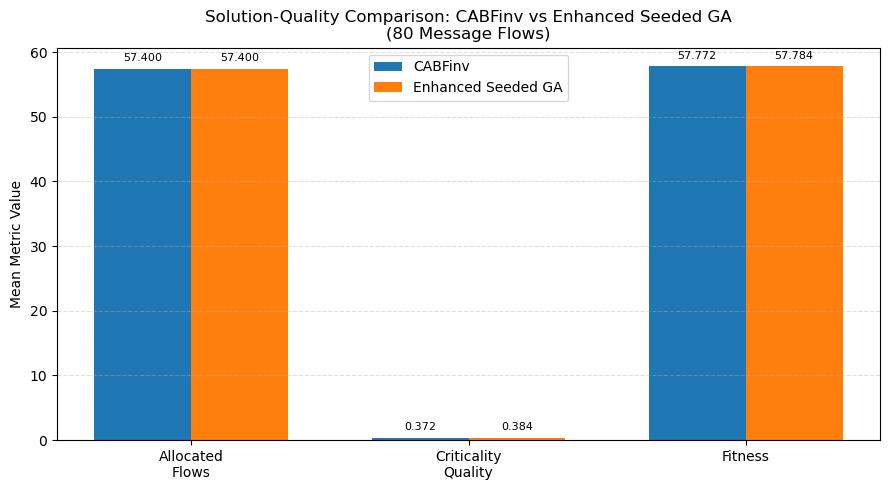

In [ ]:
# ==========================================
# CELL 47 — CABFinv vs Enhanced Seeded GA
#
# ==========================================
#
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

selected_flow_size = 80

comparison = benchmark_summary_df[
    (benchmark_summary_df["Flows"] == selected_flow_size)
    & (
        benchmark_summary_df["Algorithm"].isin(
            ["CABFinv", "Enhanced Seeded GA"]
        )
    )
].copy()

if len(comparison) != 2:
    raise ValueError(
        "Expected benchmark results for both CABFinv "
        "and Enhanced Seeded GA."
    )

metrics = [
    "Mean_Allocated_Flows",
    "Mean_Criticality_Quality",
    "Mean_Fitness"
]

metric_labels = [
    "Allocated\nFlows",
    "Criticality\nQuality",
    "Fitness"
]

cabfinv_values = (
    comparison[
        comparison["Algorithm"] == "CABFinv"
    ][metrics]
    .iloc[0]
    .astype(float)
    .to_numpy()
)

ga_values = (
    comparison[
        comparison["Algorithm"] == "Enhanced Seeded GA"
    ][metrics]
    .iloc[0]
    .astype(float)
    .to_numpy()
)

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

cabfinv_bars = plt.bar(
    x - width / 2,
    cabfinv_values,
    width,
    label="CABFinv"
)

ga_bars = plt.bar(
    x + width / 2,
    ga_values,
    width,
    label="Enhanced Seeded GA"
)

# Display values above bars
for bars in (cabfinv_bars, ga_bars):

    for bar in bars:

        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + max(cabfinv_values.max(), ga_values.max()) * 0.015,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.xticks(
    x,
    metric_labels
)

plt.ylabel("Mean Metric Value")

plt.title(
    f"Solution-Quality Comparison: CABFinv vs Enhanced Seeded GA\n"
    f"({selected_flow_size} Message Flows)"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "CABFinv_vs_Enhanced_GA_Quality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

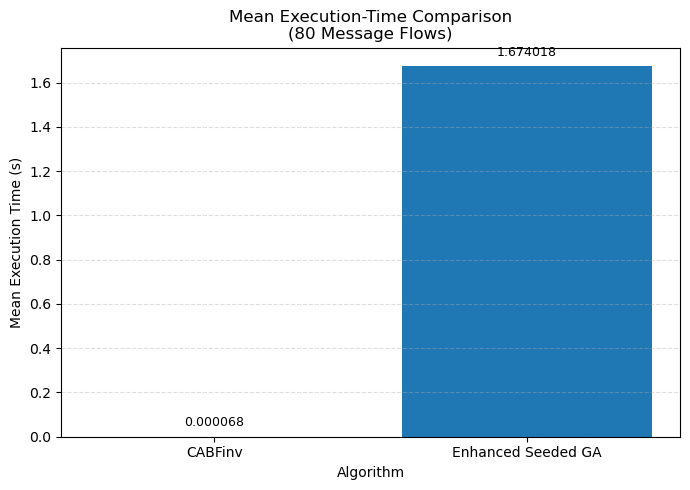

In [ ]:
# ==========================================
# CELL 47A — Execution-Time Comparison
# ==========================================

runtime_comparison = comparison[
    [
        "Algorithm",
        "Mean_Execution_Time_s"
    ]
].copy()

plt.figure(figsize=(7, 5))

runtime_bars = plt.bar(
    runtime_comparison["Algorithm"],
    runtime_comparison["Mean_Execution_Time_s"]
)

for bar in runtime_bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(
            runtime_comparison["Mean_Execution_Time_s"].max() * 0.02,
            0.000001
        ),
        f"{height:.6f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title(
    f"Mean Execution-Time Comparison\n"
    f"({selected_flow_size} Message Flows)"
)

plt.xlabel("Algorithm")
plt.ylabel("Mean Execution Time (s)")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    "CABFinv_vs_Enhanced_GA_Runtime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

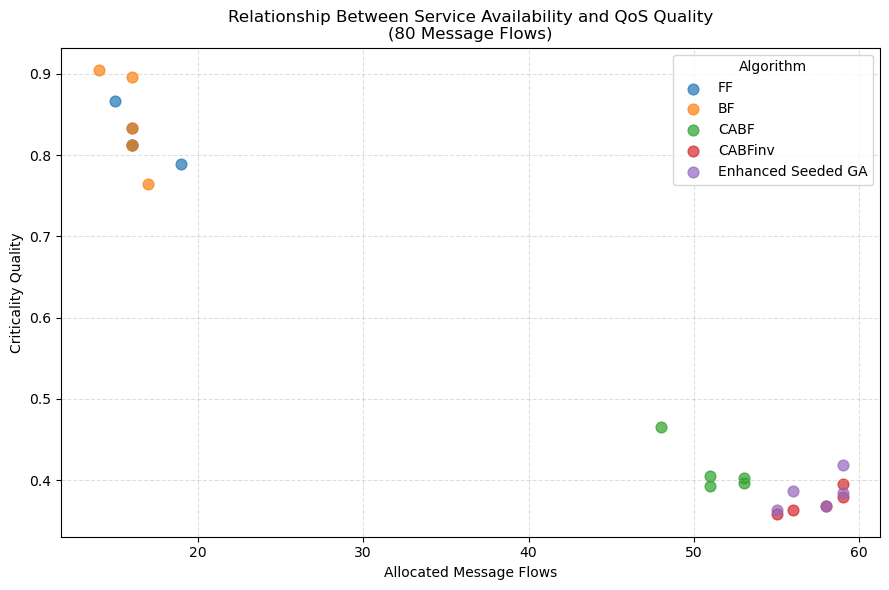

In [ ]:
# ==========================================
# CELL 48 — Relationship Between
# Service Availability and QoS Quality
# ==========================================
#
# ==========================================

import matplotlib.pyplot as plt

selected_flow_size = 80

plot_df = benchmark_raw_df[
    benchmark_raw_df["Flows"] == selected_flow_size
].copy()

if plot_df.empty:
    raise ValueError(
        f"No benchmark results were found for "
        f"{selected_flow_size} message flows."
    )

plt.figure(figsize=(9, 6))

algorithms = plot_df["Algorithm"].unique()

for algorithm in algorithms:

    data = plot_df[
        plot_df["Algorithm"] == algorithm
    ]

    plt.scatter(
        data["Allocated Flows"],
        data["Criticality Quality"],
        s=60,
        alpha=0.70,
        label=algorithm
    )

plt.xlabel("Allocated Message Flows")
plt.ylabel("Criticality Quality")

plt.title(
    "Relationship Between Service Availability "
    "and QoS Quality\n"
    f"({selected_flow_size} Message Flows)"
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.legend(
    title="Algorithm"
)

plt.tight_layout()

plt.savefig(
    f"Service_vs_Criticality_Quality_"
    f"{selected_flow_size}_Flows.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

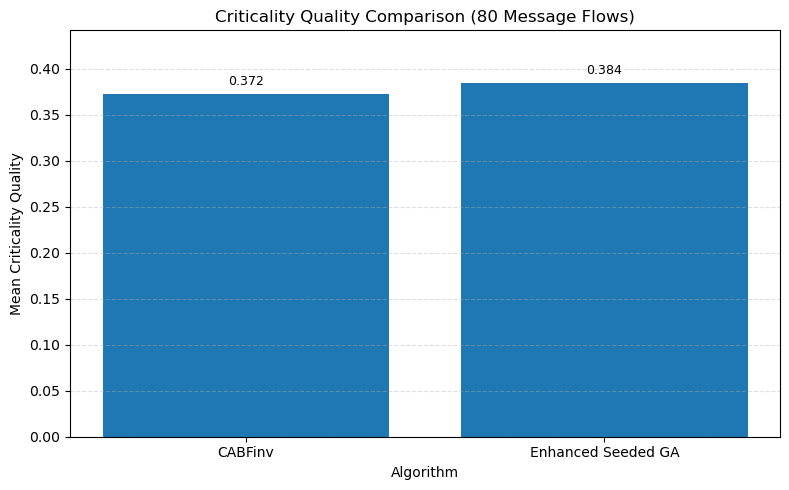

In [ ]:
# ==========================================
# CELL 51 — Criticality Quality Comparison
# ==========================================
#
# ==========================================

selected_flow_size = 80

comparison = benchmark_summary_df[
    (benchmark_summary_df["Flows"] == selected_flow_size)
    &
    (
        benchmark_summary_df["Algorithm"].isin(
            [
                "CABFinv",
                "Enhanced Seeded GA"
            ]
        )
    )
].copy()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    comparison["Algorithm"],
    comparison["Mean_Criticality_Quality"]
)

# Display values above the bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        fontsize=9
    )

plt.title(
    f"Criticality Quality Comparison ({selected_flow_size} Message Flows)"
)

plt.xlabel("Algorithm")
plt.ylabel("Mean Criticality Quality")

plt.ylim(
    0,
    comparison["Mean_Criticality_Quality"].max() * 1.15
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    "Criticality_Quality_Comparison_Selected.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

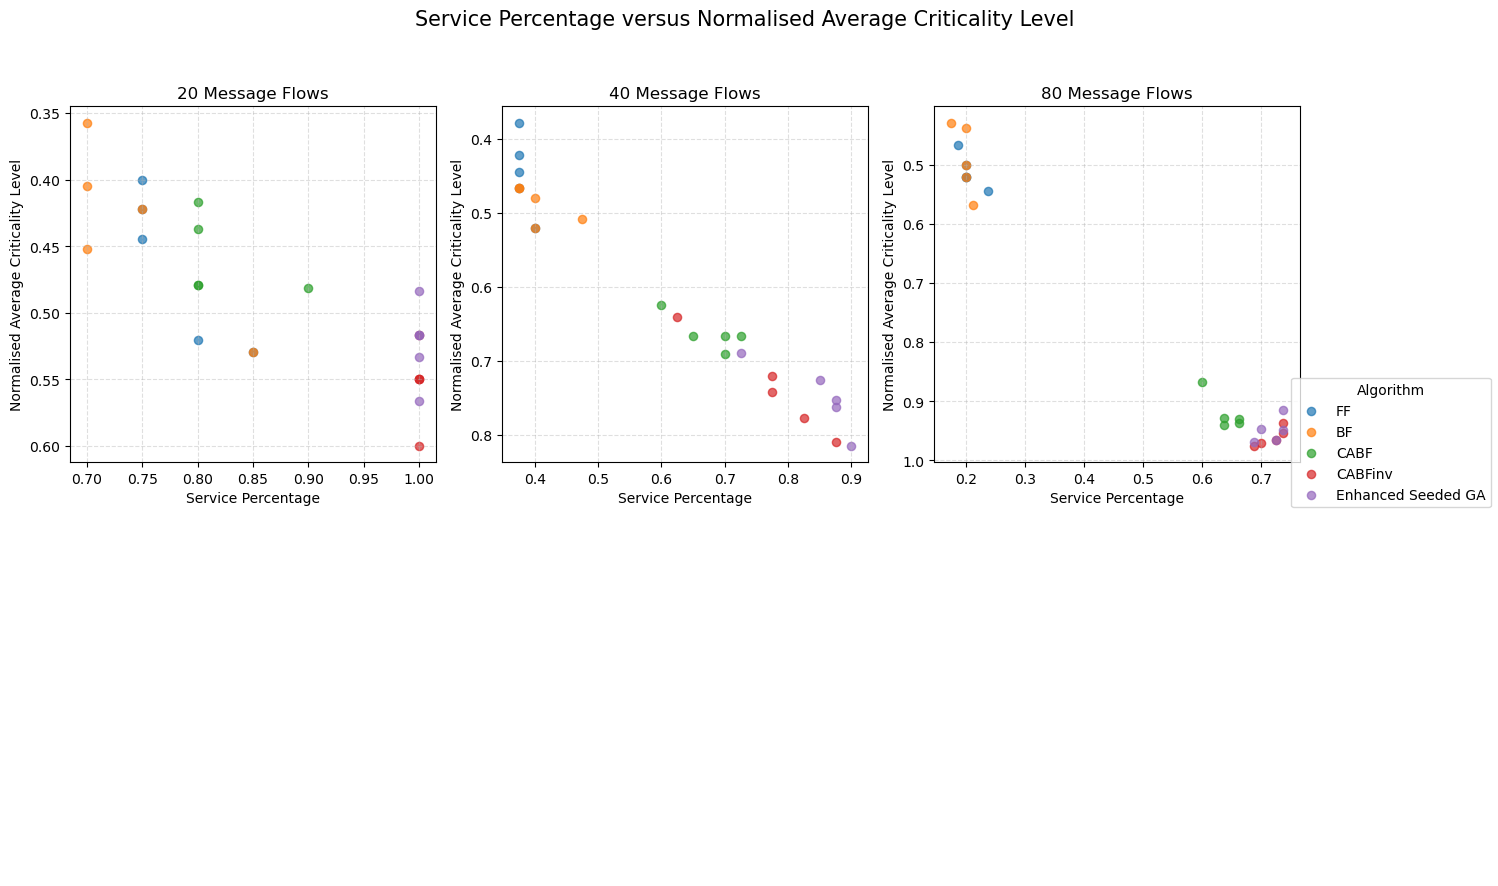

In [ ]:
# ==========================================
# CELL 53 — Service Percentage versus
# Normalised Average Criticality Level
# ==========================================
#
# ==========================================

import matplotlib.pyplot as plt

plot_df = benchmark_raw_df.copy()

plot_df["Normalised avCL"] = (
    plot_df["avCL"] / 3
)

flow_sizes = sorted(
    plot_df["Flows"].unique()
)

fig, axs = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

axes = axs.flatten()

for ax, num_flows in zip(axes, flow_sizes):

    subset = plot_df[
        plot_df["Flows"] == num_flows
    ]

    for algorithm in subset["Algorithm"].unique():

        data = subset[
            subset["Algorithm"] == algorithm
        ]

        ax.scatter(
            data["servP"],
            data["Normalised avCL"],
            s=35,
            alpha=0.70,
            label=algorithm
        )

    ax.set_title(
        f"{num_flows} Message Flows"
    )

    ax.set_xlabel(
        "Service Percentage"
    )

    ax.set_ylabel(
        "Normalised Average Criticality Level"
    )

    # Smaller values represent better QoS
    ax.invert_yaxis()

    ax.grid(
        True,
        linestyle="--",
        alpha=0.4
    )

# Hide unused subplot if only five workloads
if len(flow_sizes) < len(axes):

    for ax in axes[len(flow_sizes):]:

        ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center right",
    title="Algorithm"
)

plt.suptitle(
    "Service Percentage versus Normalised Average Criticality Level",
    fontsize=15
)

plt.tight_layout(
    rect=[0, 0, 0.88, 0.95]
)

plt.savefig(
    "Service_vs_Normalised_avCL.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ==========================================
# FINAL CELL — Export Experimental Results
# ==========================================
#
# ==========================================

# Export raw benchmark results
benchmark_raw_df.to_csv(
    "Raw_Experimental_Results.csv",
    index=False
)

# Export averaged benchmark results
benchmark_summary_df.to_csv(
    "Benchmark_Summary_Results.csv",
    index=False
)

# Export statistical summary
statistics_df.to_csv(
    "Statistical_Performance_Summary.csv",
    index=False
)

print("=" * 70)
print("Experimental results exported successfully.")
print("=" * 70)

print("\nGenerated files:")
print(" • Raw_Experimental_Results.csv")
print(" • Benchmark_Summary_Results.csv")
print(" • Statistical_Performance_Summary.csv")

print("\nNotebook execution completed successfully.")

Experimental results exported successfully.

Generated files:
 • Raw_Experimental_Results.csv
 • Benchmark_Summary_Results.csv
 • Statistical_Performance_Summary.csv

Notebook execution completed successfully.


In [ ]:
# ==========================================================
# GA PARAMETER-TUNING EXPERIMENT
# ==========================================================
#
# ==========================================================

import pandas as pd
import time


# ----------------------------------------------------------
# 1. Candidate GA configurations
# ----------------------------------------------------------
ga_configurations = [
    {
        "Configuration": "A",
        "Population Size": 30,
        "Generations": 50,
        "Mutation Rate": 0.05,
        "Tournament Size": 3,
        "Local Search Passes": 2
    },
    {
        "Configuration": "B",
        "Population Size": 30,
        "Generations": 100,
        "Mutation Rate": 0.05,
        "Tournament Size": 3,
        "Local Search Passes": 5
    },
    {
        "Configuration": "C",
        "Population Size": 50,
        "Generations": 50,
        "Mutation Rate": 0.05,
        "Tournament Size": 3,
        "Local Search Passes": 5
    },
    {
        "Configuration": "D",
        "Population Size": 50,
        "Generations": 100,
        "Mutation Rate": 0.05,
        "Tournament Size": 3,
        "Local Search Passes": 5
    },
    {
        "Configuration": "E",
        "Population Size": 50,
        "Generations": 100,
        "Mutation Rate": 0.10,
        "Tournament Size": 3,
        "Local Search Passes": 5
    }
]


# ----------------------------------------------------------
# 2. Development experiment settings
# ----------------------------------------------------------
#.
TUNING_FLOW_SIZES = (80, 120, 160)

# Ten independent runs provide a useful initial comparison.
TUNING_RUNS = 10

TUNING_BASE_SEED = 1000


# ----------------------------------------------------------
# 3. Execute every candidate configuration
# ----------------------------------------------------------
all_tuning_raw = []
all_tuning_summary = []

experiment_start = time.perf_counter()

for config in ga_configurations:

    config_name = config["Configuration"]

    print("\n" + "=" * 80)
    print(f"Testing GA Configuration {config_name}")
    print("=" * 80)

    print(
        f"Population Size      : {config['Population Size']}\n"
        f"Generations          : {config['Generations']}\n"
        f"Mutation Rate        : {config['Mutation Rate']}\n"
        f"Tournament Size      : {config['Tournament Size']}\n"
        f"Local Search Passes  : {config['Local Search Passes']}"
    )

    config_raw_df, config_summary_df = run_ga_benchmark(
        flow_sizes=TUNING_FLOW_SIZES,
        runs=TUNING_RUNS,
        population_size=config["Population Size"],
        generations=config["Generations"],
        mutation_rate=config["Mutation Rate"],
        tournament_size=config["Tournament Size"],
        local_search_passes=config["Local Search Passes"],
        base_seed=TUNING_BASE_SEED
    )

   
    ga_raw_df = config_raw_df[
        config_raw_df["Algorithm"].str.contains(
            "Seeded GA",
            case=False,
            na=False
        )
    ].copy()

    ga_summary_df = config_summary_df[
        config_summary_df["Algorithm"].str.contains(
            "Seeded GA",
            case=False,
            na=False
        )
    ].copy()

    # Attach parameter values to every stored result.
    for dataframe in (ga_raw_df, ga_summary_df):
        dataframe["Configuration"] = config_name
        dataframe["Population Size"] = config["Population Size"]
        dataframe["Generations"] = config["Generations"]
        dataframe["Mutation Rate"] = config["Mutation Rate"]
        dataframe["Tournament Size"] = config["Tournament Size"]
        dataframe["Local Search Passes"] = (
            config["Local Search Passes"]
        )

    all_tuning_raw.append(ga_raw_df)
    all_tuning_summary.append(ga_summary_df)


# ----------------------------------------------------------
# 4. Combine all results
# ----------------------------------------------------------
ga_tuning_raw_df = pd.concat(
    all_tuning_raw,
    ignore_index=True
)

ga_tuning_by_flow_df = pd.concat(
    all_tuning_summary,
    ignore_index=True
)


# ----------------------------------------------------------
# 5. Produce one overall comparison per configuration
# ----------------------------------------------------------
ga_tuning_comparison_df = (
    ga_tuning_raw_df
    .groupby(
        [
            "Configuration",
            "Population Size",
            "Generations",
            "Mutation Rate",
            "Tournament Size",
            "Local Search Passes"
        ],
        as_index=False
    )
    .agg(
        Mean_servP=("servP", "mean"),
        SD_servP=("servP", "std"),

        Mean_avCL=("avCL", "mean"),
        SD_avCL=("avCL", "std"),

        Mean_Allocated_Flows=(
            "Allocated Flows",
            "mean"
        ),
        SD_Allocated_Flows=(
            "Allocated Flows",
            "std"
        ),

        Mean_Criticality_Quality=(
            "Criticality Quality",
            "mean"
        ),
        SD_Criticality_Quality=(
            "Criticality Quality",
            "std"
        ),

        Mean_Fitness=("Fitness", "mean"),
        SD_Fitness=("Fitness", "std"),

        Mean_Execution_Time_s=(
            "Execution Time (s)",
            "mean"
        ),

        Maximum_Capacity_Violation=(
            "Capacity Violation",
            "max"
        )
    )
)


# ----------------------------------------------------------
# 6. Rank configurations
# ----------------------------------------------------------
#

ga_tuning_comparison_df["Service Rank"] = (
    ga_tuning_comparison_df["Mean_servP"]
    .rank(method="min", ascending=False)
)

ga_tuning_comparison_df["QoS Rank"] = (
    ga_tuning_comparison_df["Mean_Criticality_Quality"]
    .rank(method="min", ascending=False)
)

ga_tuning_comparison_df["Fitness Rank"] = (
    ga_tuning_comparison_df["Mean_Fitness"]
    .rank(method="min", ascending=False)
)

ga_tuning_comparison_df["Stability Rank"] = (
    ga_tuning_comparison_df["SD_Fitness"]
    .rank(method="min", ascending=True)
)

ga_tuning_comparison_df["Runtime Rank"] = (
    ga_tuning_comparison_df["Mean_Execution_Time_s"]
    .rank(method="min", ascending=True)
)


# Weighted selection score:
# service availability receives the greatest importance.
ga_tuning_comparison_df["Selection Score"] = (
    0.40 * ga_tuning_comparison_df["Service Rank"]
    + 0.25 * ga_tuning_comparison_df["QoS Rank"]
    + 0.20 * ga_tuning_comparison_df["Fitness Rank"]
    + 0.10 * ga_tuning_comparison_df["Stability Rank"]
    + 0.05 * ga_tuning_comparison_df["Runtime Rank"]
)


ga_tuning_comparison_df = (
    ga_tuning_comparison_df
    .sort_values(
        [
            "Selection Score",
            "Service Rank",
            "QoS Rank",
            "Fitness Rank"
        ]
    )
    .reset_index(drop=True)
)


# ----------------------------------------------------------
# 7. Confirm feasibility
# ----------------------------------------------------------
if (
    ga_tuning_comparison_df[
        "Maximum_Capacity_Violation"
    ] > 0
).any():
    raise RuntimeError(
        "At least one GA configuration produced "
        "an infeasible final solution."
    )


# ----------------------------------------------------------
# 8. Display results
# ----------------------------------------------------------
experiment_time = (
    time.perf_counter() - experiment_start
)

display_columns = [
    "Configuration",
    "Population Size",
    "Generations",
    "Mutation Rate",
    "Local Search Passes",
    "Mean_servP",
    "SD_servP",
    "Mean_Criticality_Quality",
    "SD_Criticality_Quality",
    "Mean_Fitness",
    "SD_Fitness",
    "Mean_Execution_Time_s",
    "Selection Score"
]

print("\n" + "=" * 120)
print("GA Parameter-Tuning Results")
print("=" * 120)

print(
    ga_tuning_comparison_df[
        display_columns
    ]
    .round(5)
    .to_string(index=False)
)

best_configuration = (
    ga_tuning_comparison_df.iloc[0]
)

print("\n" + "=" * 80)
print("Best-performing candidate configuration")
print("=" * 80)

print(
    f"Configuration        : "
    f"{best_configuration['Configuration']}\n"
    f"Population Size      : "
    f"{int(best_configuration['Population Size'])}\n"
    f"Generations          : "
    f"{int(best_configuration['Generations'])}\n"
    f"Mutation Rate        : "
    f"{best_configuration['Mutation Rate']}\n"
    f"Tournament Size      : "
    f"{int(best_configuration['Tournament Size'])}\n"
    f"Local Search Passes  : "
    f"{int(best_configuration['Local Search Passes'])}\n"
    f"Mean servP           : "
    f"{best_configuration['Mean_servP']:.5f}\n"
    f"Mean QoS Quality     : "
    f"{best_configuration['Mean_Criticality_Quality']:.5f}\n"
    f"Mean Fitness         : "
    f"{best_configuration['Mean_Fitness']:.5f}\n"
    f"Mean Execution Time  : "
    f"{best_configuration['Mean_Execution_Time_s']:.5f} s"
)

print(
    f"\nTotal tuning time: "
    f"{experiment_time / 60:.2f} minutes"
)


# ----------------------------------------------------------
# 9. Export tuning evidence
# ----------------------------------------------------------
ga_tuning_raw_df.to_csv(
    "GA_Parameter_Tuning_Raw.csv",
    index=False
)

ga_tuning_by_flow_df.to_csv(
    "GA_Parameter_Tuning_By_Flow.csv",
    index=False
)

ga_tuning_comparison_df.to_csv(
    "GA_Parameter_Tuning_Comparison.csv",
    index=False
)

print("\nTuning results exported:")
print(" • GA_Parameter_Tuning_Raw.csv")
print(" • GA_Parameter_Tuning_By_Flow.csv")
print(" • GA_Parameter_Tuning_Comparison.csv")


Testing GA Configuration A
Population Size      : 30
Generations          : 50
Mutation Rate        : 0.05
Tournament Size      : 3
Local Search Passes  : 2

Benchmarking 80 flows across 10 runs...
  Run 1/10 completed
  Run 2/10 completed
  Run 3/10 completed
  Run 4/10 completed
  Run 5/10 completed
  Run 6/10 completed
  Run 7/10 completed
  Run 8/10 completed
  Run 9/10 completed
  Run 10/10 completed

Benchmarking 120 flows across 10 runs...
  Run 1/10 completed
  Run 2/10 completed
  Run 3/10 completed
  Run 4/10 completed
  Run 5/10 completed
  Run 6/10 completed
  Run 7/10 completed
  Run 8/10 completed
  Run 9/10 completed
  Run 10/10 completed

Benchmarking 160 flows across 10 runs...
  Run 1/10 completed
  Run 2/10 completed
  Run 3/10 completed
  Run 4/10 completed
  Run 5/10 completed
  Run 6/10 completed
  Run 7/10 completed
  Run 8/10 completed
  Run 9/10 completed
  Run 10/10 completed

Testing GA Configuration B
Population Size      : 30
Generations          : 100
Mut

In [ ]:
# ==========================================
# CABF vs CABFinv Multi-Scenario Diagnostic
# ==========================================

diagnostic_results = []

for seed in range(100, 130):

    random.seed(seed)

    networks, flows = generate_scenario(
        num_flows=100,
        hC=0.8
    )

    cabf_solution = cabf(
        flows,
        networks
    )

    cabfinv_solution = cabf_inv(
        flows,
        networks
    )

    cabf_metrics = evaluate_solution(
        cabf_solution,
        flows,
        networks
    )

    cabfinv_metrics = evaluate_solution(
        cabfinv_solution,
        flows,
        networks
    )

    different_assignments = sum(
        cabf_solution[flow]
        != cabfinv_solution[flow]
        for flow in flows
    )

    diagnostic_results.append({
        "Seed": seed,
        "Different Assignments": different_assignments,
        "CABF servP": cabf_metrics["servP"],
        "CABFinv servP": cabfinv_metrics["servP"],
        "CABF QoS": cabf_metrics["CriticalityQuality"],
        "CABFinv QoS": cabfinv_metrics["CriticalityQuality"],
        "CABF Fitness": cabf_metrics["Fitness"],
        "CABFinv Fitness": cabfinv_metrics["Fitness"]
    })

diagnostic_df = pd.DataFrame(diagnostic_results)

print(diagnostic_df.to_string(index=False))

print("\nSummary")
print("=" * 60)

print(
    "Scenarios with different assignments:",
    (diagnostic_df["Different Assignments"] > 0).sum(),
    "out of",
    len(diagnostic_df)
)

print(
    "Scenarios with different service percentage:",
    (
        diagnostic_df["CABF servP"]
        != diagnostic_df["CABFinv servP"]
    ).sum()
)

print(
    "Scenarios with different QoS quality:",
    (
        diagnostic_df["CABF QoS"]
        != diagnostic_df["CABFinv QoS"]
    ).sum()
)

print(
    "Scenarios with different fitness:",
    (
        diagnostic_df["CABF Fitness"]
        != diagnostic_df["CABFinv Fitness"]
    ).sum()
)

 Seed  Different Assignments  CABF servP  CABFinv servP  CABF QoS  CABFinv QoS  CABF Fitness  CABFinv Fitness
  100                      7        0.65           0.68  0.353846     0.348039     65.353846        68.348039
  101                      6        0.67           0.69  0.353234     0.342995     67.353234        69.342995
  102                      4        0.67           0.68  0.348259     0.338235     67.348259        68.338235
  103                      0        0.64           0.64  0.333333     0.333333     64.333333        64.333333
  104                     10        0.65           0.68  0.369231     0.348039     65.369231        68.348039
  105                      5        0.63           0.64  0.354497     0.338542     63.354497        64.338542
  106                     15        0.61           0.65  0.393443     0.353846     61.393443        65.353846
  107                     15        0.58           0.63  0.385057     0.365079     58.385057        63.365079
  108     

In [ ]:
# ==========================================
# 
# ==========================================

FINAL_FLOW_SIZES = (20, 40, 80, 120, 160)
FINAL_RUNS = 30

FINAL_POPULATION_SIZE = 50
FINAL_GENERATIONS = 50
FINAL_MUTATION_RATE = 0.05
FINAL_TOURNAMENT_SIZE = 3
FINAL_LOCAL_SEARCH_PASSES = 5

FINAL_BASE_SEED = 50000

benchmark_raw_df, benchmark_summary_df = run_ga_benchmark(
    flow_sizes=FINAL_FLOW_SIZES,
    runs=FINAL_RUNS,
    population_size=FINAL_POPULATION_SIZE,
    generations=FINAL_GENERATIONS,
    mutation_rate=FINAL_MUTATION_RATE,
    tournament_size=FINAL_TOURNAMENT_SIZE,
    local_search_passes=FINAL_LOCAL_SEARCH_PASSES,
    base_seed=FINAL_BASE_SEED
)


Benchmarking 20 flows across 30 runs...
  Run 1/30 completed
  Run 2/30 completed
  Run 3/30 completed
  Run 4/30 completed
  Run 5/30 completed
  Run 6/30 completed
  Run 7/30 completed
  Run 8/30 completed
  Run 9/30 completed
  Run 10/30 completed
  Run 11/30 completed
  Run 12/30 completed
  Run 13/30 completed
  Run 14/30 completed
  Run 15/30 completed
  Run 16/30 completed
  Run 17/30 completed
  Run 18/30 completed
  Run 19/30 completed
  Run 20/30 completed
  Run 21/30 completed
  Run 22/30 completed
  Run 23/30 completed
  Run 24/30 completed
  Run 25/30 completed
  Run 26/30 completed
  Run 27/30 completed
  Run 28/30 completed
  Run 29/30 completed
  Run 30/30 completed

Benchmarking 40 flows across 30 runs...
  Run 1/30 completed
  Run 2/30 completed
  Run 3/30 completed
  Run 4/30 completed
  Run 5/30 completed
  Run 6/30 completed
  Run 7/30 completed
  Run 8/30 completed
  Run 9/30 completed
  Run 10/30 completed
  Run 11/30 completed
  Run 12/30 completed
  Run 13/30 

In [ ]:
benchmark_summary_df

,Flows,Algorithm,Mean_servP,SD_servP,Mean_avCL,SD_avCL,Mean_Allocated_Flows,SD_Allocated_Flows,Mean_Criticality_Quality,SD_Criticality_Quality,Mean_Fitness,SD_Fitness,Mean_Execution_Time_s,SD_Execution_Time_s
0,20,BF,0.735000,0.054377,1.308974,0.129092,14.700000,1.087547,0.897009,0.043031,15.597009,1.069837,0.000010,1.694757e-06
1,20,CABF,0.803333,0.078711,1.421591,0.176606,16.066667,1.574218,0.859470,0.058869,16.926136,1.532465,0.000025,3.060733e-06
2,20,CABFinv,0.985000,0.026749,1.665107,0.079791,19.700000,0.534983,0.778298,0.026597,20.478298,0.537323,0.000022,2.234294e-06
3,20,Enhanced Seeded GA,1.000000,0.000000,1.620000,0.107959,20.000000,0.000000,0.793333,0.035986,20.793333,0.035986,1.383858,1.190814e-01
4,20,FF,0.741667,0.049276,1.326332,0.148873,14.833333,0.985527,0.891223,0.049624,15.724556,0.965794,0.000010,6.539254e-07
5,40,BF,0.384167,0.035649,1.415928,0.120645,15.366667,1.425950,0.861357,0.040215,16.228024,1.400027,0.000017,8.170154e-07
6,40,CABF,0.699167,0.037990,1.994991,0.060208,27.966667,1.519604,0.668336,0.020069,28.635003,1.510614,0.000040,1.812427e-06
7,40,CABFinv,0.775000,0.046886,2.149201,0.127817,31.000000,1.875431,0.616933,0.042606,31.616933,1.843512,0.000037,1.570104e-06
8,40,Enhanced Seeded GA,0.889167,0.036955,2.287418,0.098007,35.566667,1.478194,0.570861,0.032669,36.137527,1.460370,6.308317,4.082207e-01
9,40,FF,0.387500,0.040869,1.424235,0.119159,15.500000,1.634752,0.858588,0.039720,16.358588,1.608796,0.000018,1.667682e-06


In [ ]:
print(
    "Maximum capacity violation:",
    benchmark_raw_df["Capacity Violation"].max()
)

Maximum capacity violation: 0


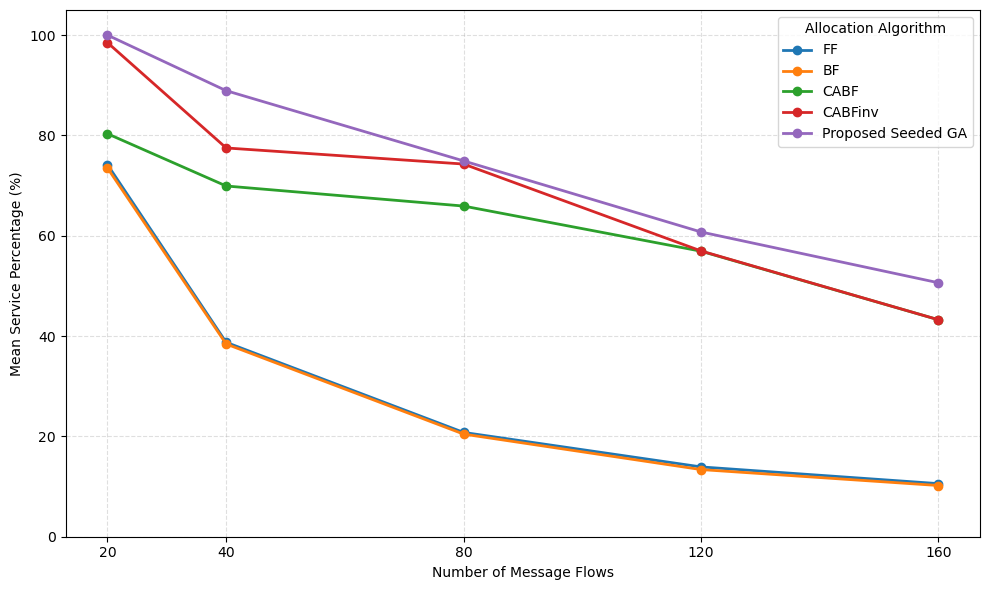

In [ ]:
# ==========================================
# 
# ==========================================

import matplotlib.pyplot as plt

# Work on a copy of the frozen benchmark summary
plot_df = benchmark_summary_df.copy()

# Standardise the GA name
plot_df["Algorithm"] = plot_df["Algorithm"].replace(
    "Enhanced Seeded GA",
    "Proposed Seeded GA"
)

algorithm_order = [
    "FF",
    "BF",
    "CABF",
    "CABFinv",
    "Proposed Seeded GA"
]

plt.figure(figsize=(10, 6))

for algorithm in algorithm_order:

    data = (
        plot_df[plot_df["Algorithm"] == algorithm]
        .sort_values("Flows")
    )

    plt.plot(
        data["Flows"],
        data["Mean_servP"] * 100,
        marker="o",
        linewidth=2,
        label=algorithm
    )

plt.xlabel("Number of Message Flows")
plt.ylabel("Mean Service Percentage (%)")

plt.xticks([20, 40, 80, 120, 160])
plt.ylim(0, 105)

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.legend(
    title="Allocation Algorithm"
)

plt.tight_layout()

plt.savefig(
    "Figure_4_1_Mean_Service_Percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

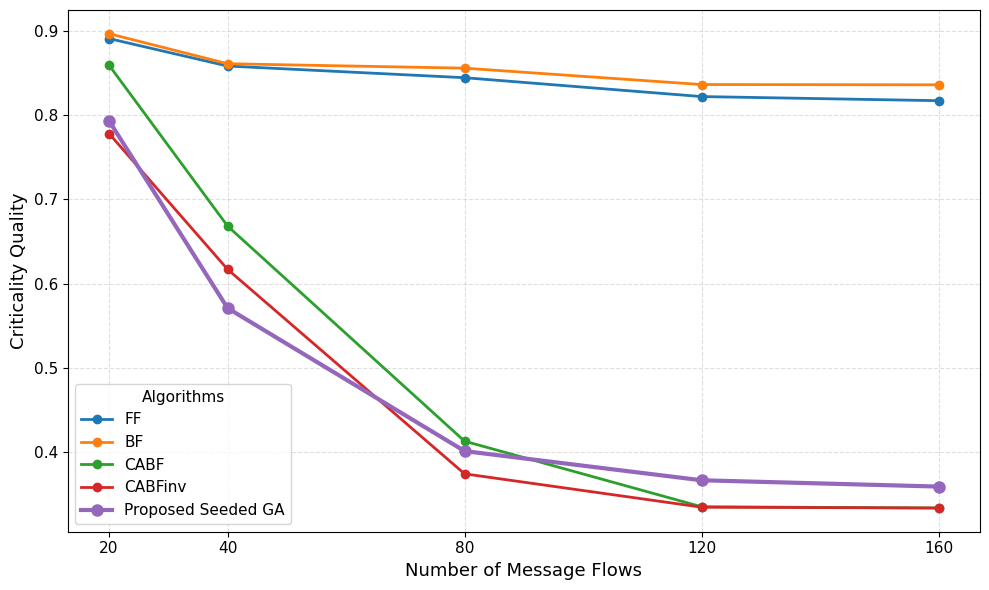

In [ ]:
# ==========================================
# 
# ==========================================

import matplotlib.pyplot as plt

plot_df = benchmark_summary_df.copy()

# Rename for publication
plot_df["Algorithm"] = plot_df["Algorithm"].replace(
    "Enhanced Seeded GA",
    "Proposed Seeded GA"
)

algorithm_order = [
    "FF",
    "BF",
    "CABF",
    "CABFinv",
    "Proposed Seeded GA"
]

plt.figure(figsize=(10,6))

for algorithm in algorithm_order:

    data = (
        plot_df[
            plot_df["Algorithm"] == algorithm
        ]
        .sort_values("Flows")
    )

    # Make the proposed GA stand out
    if algorithm == "Proposed Seeded GA":

        plt.plot(
            data["Flows"],
            data["Mean_Criticality_Quality"],
            marker="o",
            linewidth=3,
            markersize=8,
            label=algorithm
        )

    else:

        plt.plot(
            data["Flows"],
            data["Mean_Criticality_Quality"],
            marker="o",
            linewidth=2,
            markersize=6,
            label=algorithm
        )

plt.xlabel(
    "Number of Message Flows",
    fontsize=13
)

plt.ylabel(
    "Criticality Quality",
    fontsize=13
)

plt.xticks(
    [20,40,80,120,160],
    fontsize=11
)

plt.yticks(fontsize=11)

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.legend(
    title="Algorithms",
    fontsize=11,
    title_fontsize=11
)

plt.tight_layout()

plt.savefig(
    "Figure_4_2_Criticality_Quality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_4_2_Criticality_Quality.pdf",
    bbox_inches="tight"
)

plt.show()

In [ ]:
plt.savefig(
    "Figure_4_2_Criticality_Quality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_4_2_Criticality_Quality.pdf",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

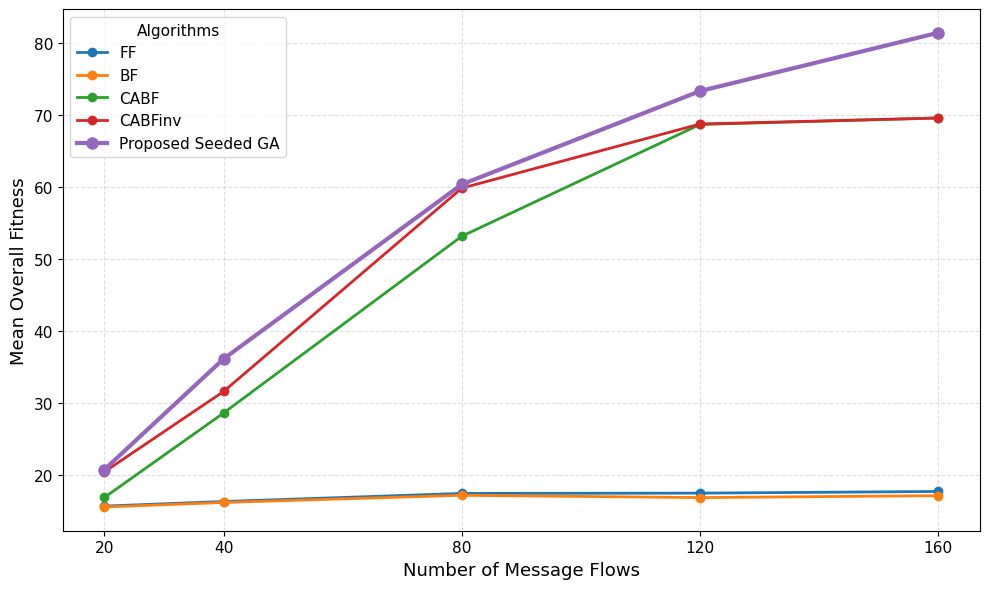

In [ ]:
# ==========================================
#
# ==========================================

import matplotlib.pyplot as plt

plot_df = benchmark_summary_df.copy()

plot_df["Algorithm"] = plot_df["Algorithm"].replace(
    "Enhanced Seeded GA",
    "Proposed Seeded GA"
)

algorithm_order = [
    "FF",
    "BF",
    "CABF",
    "CABFinv",
    "Proposed Seeded GA"
]

plt.figure(figsize=(10, 6))

for algorithm in algorithm_order:

    data = (
        plot_df[plot_df["Algorithm"] == algorithm]
        .sort_values("Flows")
    )

    if algorithm == "Proposed Seeded GA":
        plt.plot(
            data["Flows"],
            data["Mean_Fitness"],
            marker="o",
            linewidth=3,
            markersize=8,
            label=algorithm
        )
    else:
        plt.plot(
            data["Flows"],
            data["Mean_Fitness"],
            marker="o",
            linewidth=2,
            markersize=6,
            label=algorithm
        )

plt.xlabel("Number of Message Flows", fontsize=13)
plt.ylabel("Mean Overall Fitness", fontsize=13)

plt.xticks([20, 40, 80, 120, 160], fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True, linestyle="--", alpha=0.4)

plt.legend(
    title="Algorithms",
    fontsize=11,
    title_fontsize=11
)

plt.tight_layout()

plt.savefig(
    "Figure_4_3_Overall_Fitness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_4_3_Overall_Fitness.pdf",
    bbox_inches="tight"
)

plt.show()

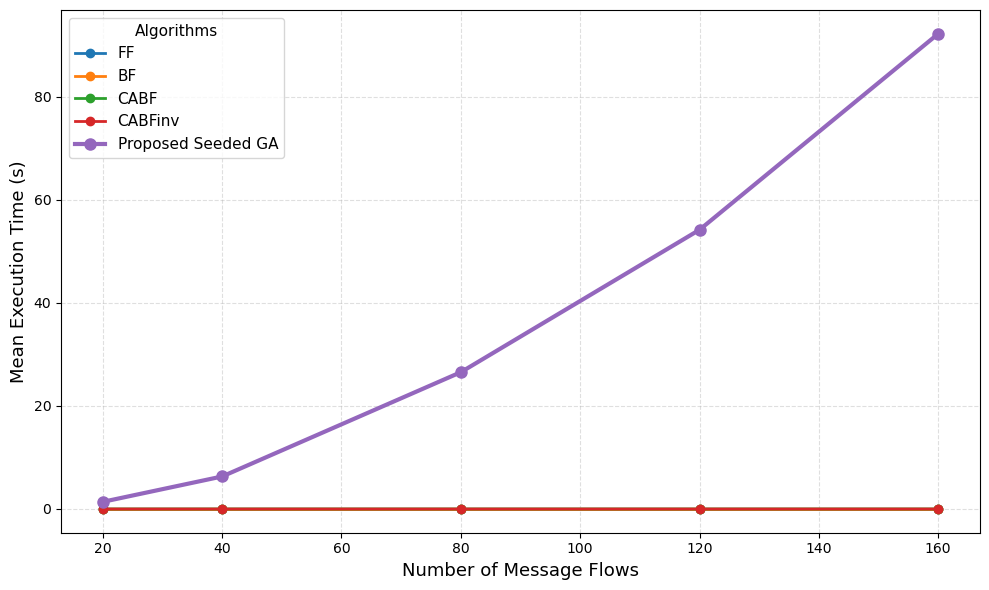

In [ ]:
# ==========================================
# 
# ==========================================

import matplotlib.pyplot as plt

plot_df = benchmark_summary_df.copy()

plot_df["Algorithm"] = plot_df["Algorithm"].replace(
    "Enhanced Seeded GA",
    "Proposed Seeded GA"
)

algorithm_order = [
    "FF",
    "BF",
    "CABF",
    "CABFinv",
    "Proposed Seeded GA"
]

plt.figure(figsize=(10,6))

for algorithm in algorithm_order:

    data = (
        plot_df[
            plot_df["Algorithm"] == algorithm
        ]
        .sort_values("Flows")
    )

    if algorithm == "Proposed Seeded GA":

        plt.plot(
            data["Flows"],
            data["Mean_Execution_Time_s"],
            marker="o",
            linewidth=3,
            markersize=8,
            label=algorithm
        )

    else:

        plt.plot(
            data["Flows"],
            data["Mean_Execution_Time_s"],
            marker="o",
            linewidth=2,
            markersize=6,
            label=algorithm
        )

plt.xlabel(
    "Number of Message Flows",
    fontsize=13
)

plt.ylabel(
    "Mean Execution Time (s)",
    fontsize=13
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.legend(
    title="Algorithms",
    fontsize=11,
    title_fontsize=11
)

plt.tight_layout()

plt.savefig(
    "Figure_4_3_Execution_Time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_4_3_Execution_Time.pdf",
    bbox_inches="tight"
)

plt.show()

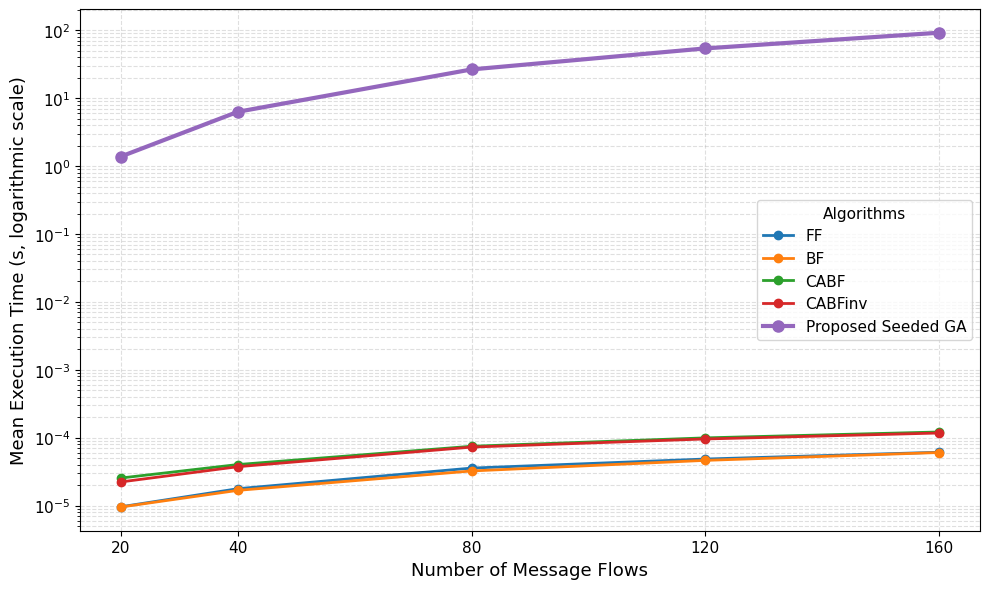

In [ ]:
# ==========================================
# — Mean Execution Time
# Logarithmic Scale
# ==========================================

import matplotlib.pyplot as plt

plot_df = benchmark_summary_df.copy()

plot_df["Algorithm"] = plot_df["Algorithm"].replace(
    "Enhanced Seeded GA",
    "Proposed Seeded GA"
)

algorithm_order = [
    "FF",
    "BF",
    "CABF",
    "CABFinv",
    "Proposed Seeded GA"
]

plt.figure(figsize=(10, 6))

for algorithm in algorithm_order:

    data = (
        plot_df[
            plot_df["Algorithm"] == algorithm
        ]
        .sort_values("Flows")
    )

    if algorithm == "Proposed Seeded GA":
        plt.plot(
            data["Flows"],
            data["Mean_Execution_Time_s"],
            marker="o",
            linewidth=3,
            markersize=8,
            label=algorithm
        )
    else:
        plt.plot(
            data["Flows"],
            data["Mean_Execution_Time_s"],
            marker="o",
            linewidth=2,
            markersize=6,
            label=algorithm
        )

plt.xlabel(
    "Number of Message Flows",
    fontsize=13
)

plt.ylabel(
    "Mean Execution Time (s, logarithmic scale)",
    fontsize=13
)

plt.xticks(
    [20, 40, 80, 120, 160],
    fontsize=11
)

plt.yticks(fontsize=11)

# Logarithmic y-axis
plt.yscale("log")

plt.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.4
)

plt.legend(
    title="Algorithms",
    fontsize=11,
    title_fontsize=11
)

plt.tight_layout()

plt.savefig(
    "Figure_4_3_Execution_Time_Log.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_4_3_Execution_Time_Log.pdf",
    bbox_inches="tight"
)

plt.show()

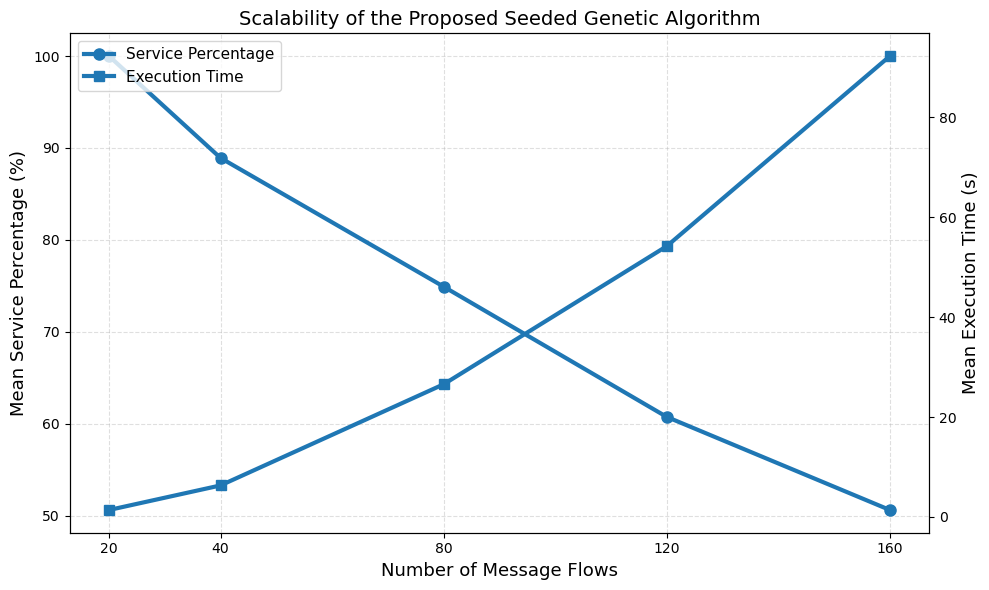

In [ ]:
# ==========================================
# Scalability of the Proposed
# Seeded Genetic Algorithm
# ==========================================

import matplotlib.pyplot as plt

ga_data = (
    benchmark_summary_df[
        benchmark_summary_df["Algorithm"] == "Enhanced Seeded GA"
    ]
    .sort_values("Flows")
)

fig, ax1 = plt.subplots(figsize=(10, 6))

# ------------------------------------------
# Left axis: Service Percentage
# ------------------------------------------

line1 = ax1.plot(
    ga_data["Flows"],
    ga_data["Mean_servP"] * 100,
    marker="o",
    linewidth=3,
    markersize=8,
    label="Service Percentage"
)

ax1.set_xlabel(
    "Number of Message Flows",
    fontsize=13
)

ax1.set_ylabel(
    "Mean Service Percentage (%)",
    fontsize=13
)

ax1.set_xticks([20, 40, 80, 120, 160])

ax1.grid(
    True,
    linestyle="--",
    alpha=0.4
)

# ------------------------------------------
# Right axis: Execution Time
# ------------------------------------------

ax2 = ax1.twinx()

line2 = ax2.plot(
    ga_data["Flows"],
    ga_data["Mean_Execution_Time_s"],
    marker="s",
    linewidth=3,
    markersize=7,
    label="Execution Time"
)

ax2.set_ylabel(
    "Mean Execution Time (s)",
    fontsize=13
)

# ------------------------------------------
# Combined legend
# ------------------------------------------

lines = line1 + line2
labels = [l.get_label() for l in lines]

ax1.legend(
    lines,
    labels,
    loc="upper left",
    fontsize=11
)

plt.title(
    "Scalability of the Proposed Seeded Genetic Algorithm",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "Figure_4_4_Scalability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_4_4_Scalability.pdf",
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ==========================================================
# REPRESENTATIVE 160-FLOW ALLOCATION ANALYSIS
# ==
# ==========================================================

import random
import pandas as pd
from collections import Counter

SELECTED_FLOW_SIZE = 160
SELECTED_RUN_INDEX = 0

# Matches the seed construction used by the final benchmark:
# base_seed + num_flows * 1000 + run_index
SELECTED_SEED = (
    FINAL_BASE_SEED
    + SELECTED_FLOW_SIZE * 1000
    + SELECTED_RUN_INDEX
)

random.seed(SELECTED_SEED)

networks_selected, flows_selected = generate_scenario(
    num_flows=SELECTED_FLOW_SIZE,
    hC=0.8
)

baseline_algorithms = {
    "FF": first_fit,
    "BF": best_fit,
    "CABF": cabf,
    "CABFinv": cabf_inv
}

selected_allocations = {}
selected_metrics = {}

# ----------------------------------------------------------
# Execute baseline algorithms
# ----------------------------------------------------------
for algorithm_name, algorithm_function in baseline_algorithms.items():

    allocation = algorithm_function(
        flows_selected,
        networks_selected
    )

    metrics = evaluate_solution(
        allocation,
        flows_selected,
        networks_selected
    )

    selected_allocations[algorithm_name] = allocation
    selected_metrics[algorithm_name] = metrics

# ----------------------------------------------------------
# Execute the frozen Proposed Seeded GA
# ----------------------------------------------------------
ga_allocation, ga_metrics, _, _ = run_ga(
    flows_selected,
    networks_selected,
    population_size=FINAL_POPULATION_SIZE,
    generations=FINAL_GENERATIONS,
    mutation_rate=FINAL_MUTATION_RATE,
    tournament_size=FINAL_TOURNAMENT_SIZE,
    local_search_passes=FINAL_LOCAL_SEARCH_PASSES
)

selected_allocations["Proposed Seeded GA"] = ga_allocation
selected_metrics["Proposed Seeded GA"] = ga_metrics

# ----------------------------------------------------------
# Verify feasibility
# ----------------------------------------------------------
for algorithm_name, metrics in selected_metrics.items():

    assert metrics["CapacityViolation"] == 0, (
        f"{algorithm_name} produced an infeasible solution."
    )

print("Representative scenario completed.")
print(f"Flow size : {SELECTED_FLOW_SIZE}")
print(f"Seed      : {SELECTED_SEED}")

Representative scenario completed.
Flow size : 160
Seed      : 210000


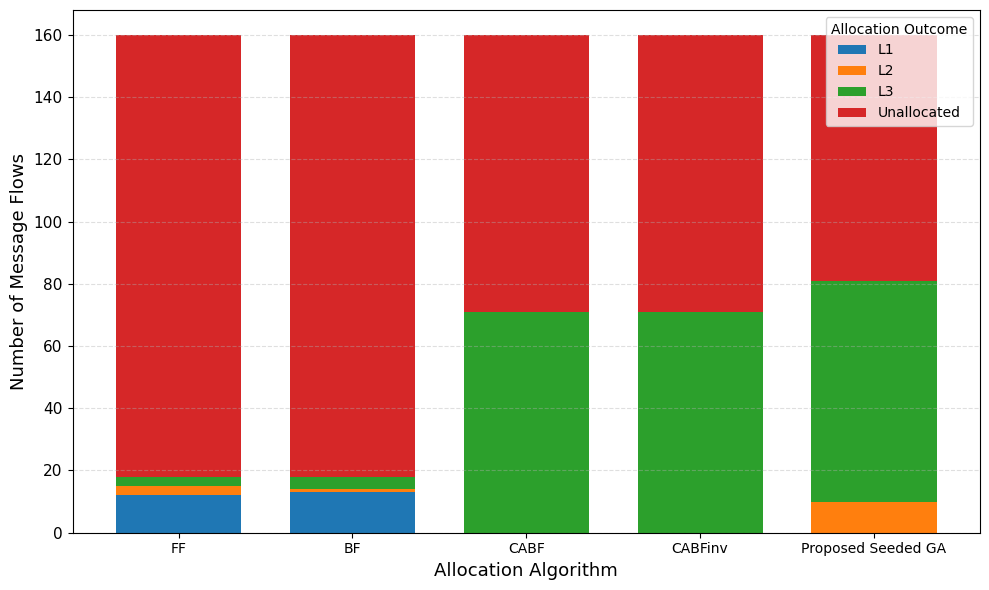

                    L1  L2  L3  Unallocated
Algorithm                                  
FF                  12   3   3          142
BF                  13   1   4          142
CABF                 0   0  71           89
CABFinv              0   0  71           89
Proposed Seeded GA   0  10  71           79


In [ ]:
# ==========================================================
#  QOS-LEVEL DISTRIBUTION
# ==========================================================

import matplotlib.pyplot as plt

algorithm_order = [
    "FF",
    "BF",
    "CABF",
    "CABFinv",
    "Proposed Seeded GA"
]

qos_distribution_rows = []

for algorithm_name in algorithm_order:

    allocation = selected_allocations[algorithm_name]

    level_counts = Counter()

    for flow in flows_selected:

        network, level = allocation.get(
            flow,
            (None, None)
        )

        if network is None or level is None:
            level_counts["Unallocated"] += 1
        else:
            level_counts[f"L{level}"] += 1

    qos_distribution_rows.append({
        "Algorithm": algorithm_name,
        "L1": level_counts["L1"],
        "L2": level_counts["L2"],
        "L3": level_counts["L3"],
        "Unallocated": level_counts["Unallocated"]
    })

qos_distribution_df = pd.DataFrame(
    qos_distribution_rows
).set_index("Algorithm")

ax = qos_distribution_df[
    ["L1", "L2", "L3", "Unallocated"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    width=0.72
)

ax.set_xlabel("Allocation Algorithm", fontsize=13)
ax.set_ylabel("Number of Message Flows", fontsize=13)

ax.tick_params(
    axis="x",
    labelrotation=0,
    labelsize=10
)

ax.tick_params(
    axis="y",
    labelsize=11
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

ax.legend(
    title="Allocation Outcome",
    fontsize=10,
    title_fontsize=10
)

plt.tight_layout()

plt.savefig(
    "Figure_4_4_QoS_Level_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_4_4_QoS_Level_Distribution.pdf",
    bbox_inches="tight"
)

plt.show()

print(qos_distribution_df)

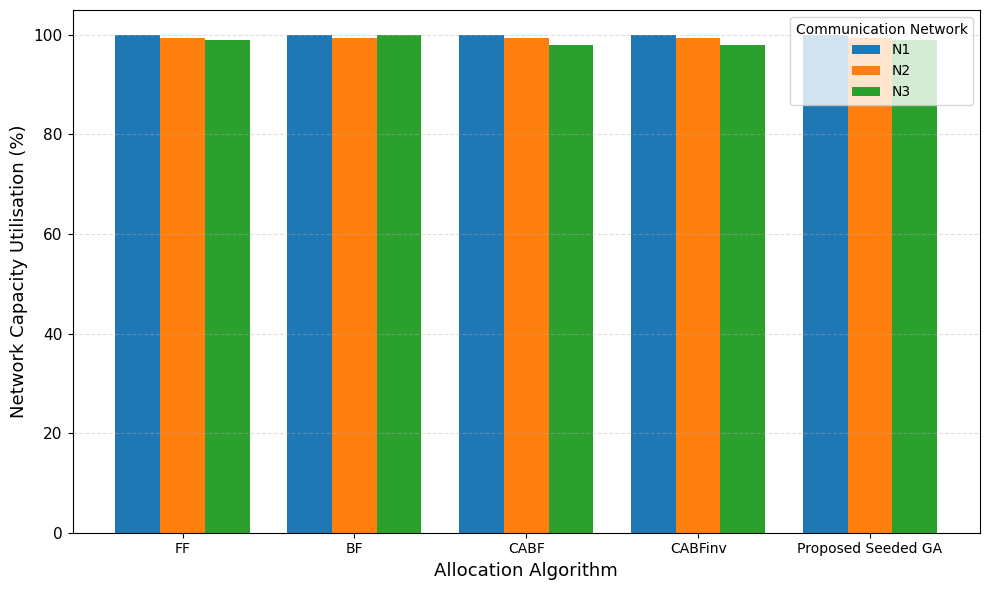

Network                N1     N2     N3
Algorithm                              
FF                  100.0  99.33   99.0
BF                  100.0  99.33  100.0
CABF                100.0  99.33   98.0
CABFinv             100.0  99.33   98.0
Proposed Seeded GA  100.0  99.33   99.0


In [ ]:
# ==========================================================
#  COMMUNICATION-NETWORK UTILISATION
# ==========================================================

network_utilisation_rows = []

for algorithm_name in algorithm_order:

    loads = selected_metrics[algorithm_name]["Loads"]

    for network_name, capacity in networks_selected.items():

        used_bandwidth = loads[network_name]

        utilisation_percentage = (
            used_bandwidth / capacity
        ) * 100

        network_utilisation_rows.append({
            "Algorithm": algorithm_name,
            "Network": network_name,
            "Utilisation (%)": utilisation_percentage
        })

network_utilisation_df = pd.DataFrame(
    network_utilisation_rows
)

network_utilisation_pivot = (
    network_utilisation_df
    .pivot(
        index="Algorithm",
        columns="Network",
        values="Utilisation (%)"
    )
    .reindex(algorithm_order)
)

ax = network_utilisation_pivot.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.78
)

ax.set_xlabel("Allocation Algorithm", fontsize=13)
ax.set_ylabel("Network Capacity Utilisation (%)", fontsize=13)

ax.set_ylim(0, 105)

ax.tick_params(
    axis="x",
    labelrotation=0,
    labelsize=10
)

ax.tick_params(
    axis="y",
    labelsize=11
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

ax.legend(
    title="Communication Network",
    fontsize=10,
    title_fontsize=10
)

plt.tight_layout()

plt.savefig(
    "Figure_4_5_Network_Utilisation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_4_5_Network_Utilisation.pdf",
    bbox_inches="tight"
)

plt.show()

print(
    network_utilisation_pivot
    .round(2)
)

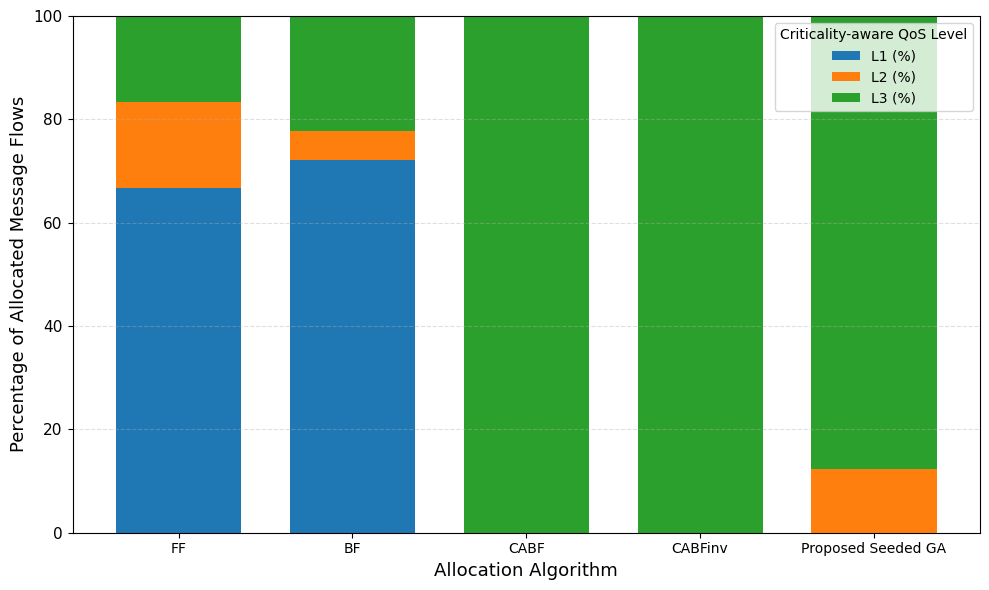

                    L1 (%)  L2 (%)  L3 (%)  Allocated Flows
Algorithm                                                  
FF                   66.67   16.67   16.67               18
BF                   72.22    5.56   22.22               18
CABF                  0.00    0.00  100.00               71
CABFinv               0.00    0.00  100.00               71
Proposed Seeded GA    0.00   12.35   87.65               81


In [ ]:
# ==========================================================
# QOS COMPOSITION OF ALLOCATED FLOWS
# ==========================================================
#
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

algorithm_order = [
    "FF",
    "BF",
    "CABF",
    "CABFinv",
    "Proposed Seeded GA"
]

qos_composition_rows = []

for algorithm_name in algorithm_order:

    allocation = selected_allocations[algorithm_name]

    level_counts = Counter()

    for flow in flows_selected:

        network, level = allocation.get(
            flow,
            (None, None)
        )

        if network is not None and level is not None:
            level_counts[f"L{level}"] += 1

    allocated_total = (
        level_counts["L1"]
        + level_counts["L2"]
        + level_counts["L3"]
    )

    if allocated_total == 0:
        l1_percentage = 0
        l2_percentage = 0
        l3_percentage = 0
    else:
        l1_percentage = (
            level_counts["L1"] / allocated_total
        ) * 100

        l2_percentage = (
            level_counts["L2"] / allocated_total
        ) * 100

        l3_percentage = (
            level_counts["L3"] / allocated_total
        ) * 100

    qos_composition_rows.append({
        "Algorithm": algorithm_name,
        "L1 (%)": l1_percentage,
        "L2 (%)": l2_percentage,
        "L3 (%)": l3_percentage,
        "Allocated Flows": allocated_total
    })

qos_composition_df = pd.DataFrame(
    qos_composition_rows
).set_index("Algorithm")

ax = qos_composition_df[
    ["L1 (%)", "L2 (%)", "L3 (%)"]
].plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    width=0.72
)

ax.set_xlabel(
    "Allocation Algorithm",
    fontsize=13
)

ax.set_ylabel(
    "Percentage of Allocated Message Flows",
    fontsize=13
)

ax.set_ylim(0, 100)

ax.tick_params(
    axis="x",
    labelrotation=0,
    labelsize=10
)

ax.tick_params(
    axis="y",
    labelsize=11
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

ax.legend(
    title="Criticality-aware QoS Level",
    fontsize=10,
    title_fontsize=10
)

plt.tight_layout()

plt.savefig(
    "Figure_4_4_QoS_Composition_Allocated_Flows.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_4_4_QoS_Composition_Allocated_Flows.pdf",
    bbox_inches="tight"
)

plt.show()

print(
    qos_composition_df.round(2)
)

In [ ]:
for alg in ["CABF", "CABFinv"]:

    allocation = selected_allocations[alg]

    levels = [
        level
        for (_, level) in allocation.values()
        if level is not None
    ]

    print("\n", alg)
    print("L1:", levels.count(1))
    print("L2:", levels.count(2))
    print("L3:", levels.count(3))


 CABF
L1: 0
L2: 0
L3: 71

 CABFinv
L1: 0
L2: 0
L3: 71


In [ ]:
# ==========================================================
# SELECT REPRESENTATIVE 80-FLOW RUN
# ==========================================================
#
# ==========================================================

import numpy as np
import pandas as pd

REPRESENTATIVE_FLOW_SIZE = 80

algorithm_names = [
    "CABF",
    "CABFinv",
    "Enhanced Seeded GA"
]

# Mean benchmark values for the selected workload
target_means = (
    benchmark_summary_df[
        (benchmark_summary_df["Flows"] == REPRESENTATIVE_FLOW_SIZE)
        & (benchmark_summary_df["Algorithm"].isin(algorithm_names))
    ]
    .set_index("Algorithm")
)

candidate_rows = []

for run_index in range(FINAL_RUNS):

    seed = (
        FINAL_BASE_SEED
        + REPRESENTATIVE_FLOW_SIZE * 1000
        + run_index
    )

    run_data = benchmark_raw_df[
        (benchmark_raw_df["Flows"] == REPRESENTATIVE_FLOW_SIZE)
        & (benchmark_raw_df["Run"] == run_index + 1)
        & (benchmark_raw_df["Algorithm"].isin(algorithm_names))
    ].set_index("Algorithm")

    if len(run_data) != len(algorithm_names):
        continue

    distance = 0.0

    for algorithm in algorithm_names:

        # Normalised distance across the principal metrics
        distance += (
            abs(
                run_data.loc[algorithm, "servP"]
                - target_means.loc[algorithm, "Mean_servP"]
            )
            / max(target_means.loc[algorithm, "SD_servP"], 1e-9)
        )

        distance += (
            abs(
                run_data.loc[algorithm, "Criticality Quality"]
                - target_means.loc[
                    algorithm,
                    "Mean_Criticality_Quality"
                ]
            )
            / max(
                target_means.loc[
                    algorithm,
                    "SD_Criticality_Quality"
                ],
                1e-9
            )
        )

    candidate_rows.append({
        "Run Index": run_index,
        "Run Number": run_index + 1,
        "Seed": seed,
        "Distance from Mean": distance
    })

representative_candidates_df = (
    pd.DataFrame(candidate_rows)
    .sort_values("Distance from Mean")
    .reset_index(drop=True)
)

print("Most representative candidate runs:")
print(
    representative_candidates_df
    .head(10)
    .round(4)
    .to_string(index=False)
)

SELECTED_RUN_INDEX = int(
    representative_candidates_df.iloc[0]["Run Index"]
)

SELECTED_SEED = int(
    representative_candidates_df.iloc[0]["Seed"]
)

print("\nSelected representative scenario")
print("Flows     :", REPRESENTATIVE_FLOW_SIZE)
print("Run index :", SELECTED_RUN_INDEX)
print("Seed      :", SELECTED_SEED)

Most representative candidate runs:
 Run Index  Run Number   Seed  Distance from Mean
         7           8 130007              1.1736
         5           6 130005              1.5039
         0           1 130000              1.5570
        16          17 130016              1.7246
        14          15 130014              1.8930
         4           5 130004              1.8984
        19          20 130019              1.9112
        26          27 130026              1.9284
         8           9 130008              2.2878
        20          21 130020              2.4669

Selected representative scenario
Flows     : 80
Run index : 7
Seed      : 130007


In [ ]:
# ==========================================================
# NEW CELL — REGENERATE REPRESENTATIVE 80-FLOW SCENARIO
# ==========================================================
#
# ==========================================================

import random

# ----------------------------------------------------------
# Representative benchmark scenario
# ----------------------------------------------------------

REPRESENTATIVE_FLOW_SIZE = 80
REPRESENTATIVE_RUN = 8
REPRESENTATIVE_SEED = 130007

random.seed(REPRESENTATIVE_SEED)

networks_selected, flows_selected = generate_scenario(
    num_flows=REPRESENTATIVE_FLOW_SIZE,
    hC=0.8
)

baseline_algorithms = {
    "FF": first_fit,
    "BF": best_fit,
    "CABF": cabf,
    "CABFinv": cabf_inv
}

selected_allocations = {}
selected_metrics = {}

# ----------------------------------------------------------
# Run baseline algorithms
# ----------------------------------------------------------

for algorithm_name, algorithm_function in baseline_algorithms.items():

    allocation = algorithm_function(
        flows_selected,
        networks_selected
    )

    metrics = evaluate_solution(
        allocation,
        flows_selected,
        networks_selected
    )

    selected_allocations[algorithm_name] = allocation
    selected_metrics[algorithm_name] = metrics

# ----------------------------------------------------------
# Run Proposed Seeded GA
# ----------------------------------------------------------

ga_allocation, ga_metrics, _, _ = run_ga(
    flows_selected,
    networks_selected,
    population_size=FINAL_POPULATION_SIZE,
    generations=FINAL_GENERATIONS,
    mutation_rate=FINAL_MUTATION_RATE,
    tournament_size=FINAL_TOURNAMENT_SIZE,
    local_search_passes=FINAL_LOCAL_SEARCH_PASSES
)

selected_allocations["Proposed Seeded GA"] = ga_allocation
selected_metrics["Proposed Seeded GA"] = ga_metrics

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------

print("=" * 60)
print("Representative Benchmark Scenario")
print("=" * 60)
print(f"Flow size : {REPRESENTATIVE_FLOW_SIZE}")
print(f"Run       : {REPRESENTATIVE_RUN}")
print(f"Seed      : {REPRESENTATIVE_SEED}")

print("\nAlgorithm Summary")
print("-" * 60)

for algorithm in [
    "FF",
    "BF",
    "CABF",
    "CABFinv",
    "Proposed Seeded GA"
]:

    m = selected_metrics[algorithm]

    print(
        f"{algorithm:20}"
        f" Allocated={m['AllocatedFlows']:2d}"
        f"  servP={m['servP']:.3f}"
        f"  QoS={m['CriticalityQuality']:.3f}"
    )

Representative Benchmark Scenario
Flow size : 80
Run       : 8
Seed      : 130007

Algorithm Summary
------------------------------------------------------------
FF                   Allocated=17  servP=0.212  QoS=0.843
BF                   Allocated=16  servP=0.200  QoS=0.854
CABF                 Allocated=52  servP=0.650  QoS=0.417
CABFinv              Allocated=60  servP=0.750  QoS=0.383
Proposed Seeded GA   Allocated=60  servP=0.750  QoS=0.400


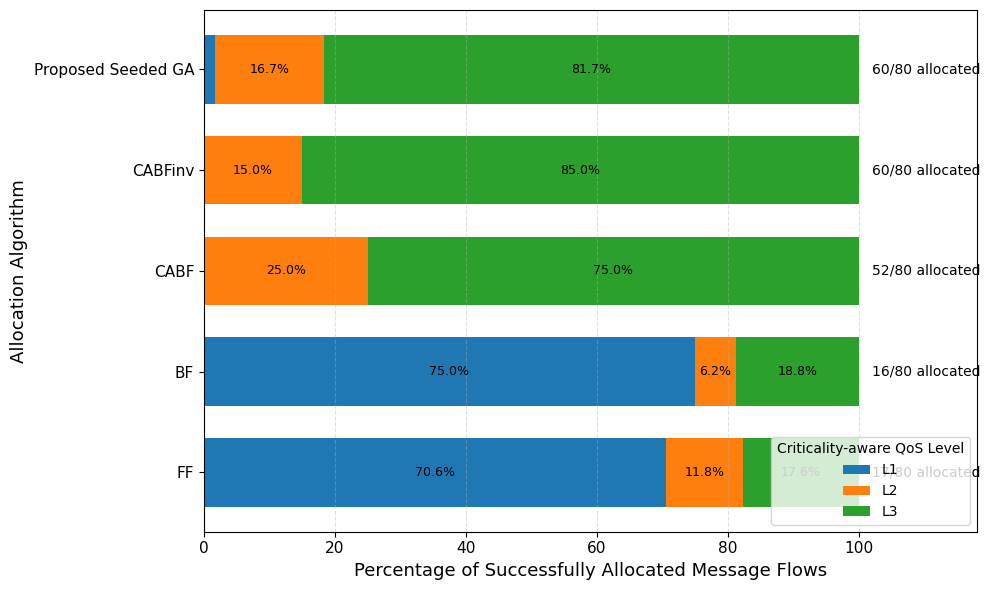


QoS counts:
                    L1  L2  L3  Allocated
Algorithm                                
FF                  12   2   3         17
BF                  12   1   3         16
CABF                 0  13  39         52
CABFinv              0   9  51         60
Proposed Seeded GA   1  10  49         60

QoS percentages:
                       L1     L2     L3
Algorithm                              
FF                  70.59  11.76  17.65
BF                  75.00   6.25  18.75
CABF                 0.00  25.00  75.00
CABFinv              0.00  15.00  85.00
Proposed Seeded GA   1.67  16.67  81.67


In [ ]:
# ==========================================================
# — QOS COMPOSITION OF ALLOCATED FLOWS
# Representative 80-Flow Scenario
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

algorithm_order = [
    "FF",
    "BF",
    "CABF",
    "CABFinv",
    "Proposed Seeded GA"
]

rows = []

for algorithm_name in algorithm_order:

    allocation = selected_allocations[algorithm_name]
    counts = Counter()

    for flow in flows_selected:

        network, level = allocation.get(
            flow,
            (None, None)
        )

        if network is not None and level is not None:
            counts[f"L{level}"] += 1

    allocated_total = (
        counts["L1"]
        + counts["L2"]
        + counts["L3"]
    )

    rows.append({
        "Algorithm": algorithm_name,
        "L1": counts["L1"],
        "L2": counts["L2"],
        "L3": counts["L3"],
        "Allocated": allocated_total
    })

qos_counts_df = pd.DataFrame(rows).set_index("Algorithm")

# Convert counts to percentages of allocated flows
qos_percent_df = qos_counts_df[["L1", "L2", "L3"]].div(
    qos_counts_df["Allocated"],
    axis=0
) * 100

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

ax = qos_percent_df.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 6),
    width=0.68
)

ax.set_xlabel(
    "Percentage of Successfully Allocated Message Flows",
    fontsize=13
)

ax.set_ylabel(
    "Allocation Algorithm",
    fontsize=13
)

ax.set_xlim(0, 118)

ax.tick_params(
    axis="x",
    labelsize=11
)

ax.tick_params(
    axis="y",
    labelsize=11
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

ax.legend(
    title="Criticality-aware QoS Level",
    fontsize=10,
    title_fontsize=10,
    loc="lower right"
)

# ----------------------------------------------------------
# Add percentage labels inside each QoS segment
# ----------------------------------------------------------

for row_index, algorithm_name in enumerate(algorithm_order):

    cumulative = 0

    for level_name in ["L1", "L2", "L3"]:

        percentage = qos_percent_df.loc[
            algorithm_name,
            level_name
        ]

        if percentage >= 4:

            ax.text(
                cumulative + percentage / 2,
                row_index,
                f"{percentage:.1f}%",
                ha="center",
                va="center",
                fontsize=9
            )

        cumulative += percentage

    allocated = int(
        qos_counts_df.loc[
            algorithm_name,
            "Allocated"
        ]
    )

    ax.text(
        102,
        row_index,
        f"{allocated}/80 allocated",
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "Figure_4_4_QoS_Composition_Representative_80_Flows.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_4_4_QoS_Composition_Representative_80_Flows.pdf",
    bbox_inches="tight"
)

plt.show()

print("\nQoS counts:")
print(qos_counts_df)

print("\nQoS percentages:")
print(qos_percent_df.round(2))

In [ ]:
# ==========================================
# Example: Resource Allocation Evaluation
# ==========================================

# -----------------------------
# Networks and capacities
# -----------------------------
networks = {
    "N1": 100,
    "N2": 80,
    "N3": 60
}

# -----------------------------
# Flows
# -----------------------------
flows = ["F1", "F2", "F3", "F4", "F5"]

# -----------------------------
# Bandwidth demand for each
# criticality-aware QoS level
# L1 = Highest QoS
# L2 = Medium QoS
# L3 = Lowest QoS
# -----------------------------
bandwidth = {
    "F1": {"L1": 30, "L2": 20, "L3": 10},
    "F2": {"L1": 25, "L2": 15, "L3": 8},
    "F3": {"L1": 20, "L2": 12, "L3": 6},
    "F4": {"L1": 18, "L2": 10, "L3": 5},
    "F5": {"L1": 15, "L2": 8,  "L3": 4}
}

# -----------------------------------------
# Example chromosome
# (Network, Criticality-aware QoS level)
# -----------------------------------------
chromosome = {
    "F1": ("N1", "L1"),
    "F2": ("N1", "L2"),
    "F3": ("N2", "L1"),
    "F4": ("N3", "L3"),
    "F5": ("N2", "L2")
}

# -----------------------------------------
# Evaluate solution
# -----------------------------------------

remaining = networks.copy()

served = 0
capacity_violation = 0

for flow, (network, level) in chromosome.items():

    demand = bandwidth[flow][level]

    if remaining[network] >= demand:
        remaining[network] -= demand
        served += 1
    else:
        capacity_violation += demand - remaining[network]
        remaining[network] = 0

service_percentage = served / len(flows)

# Average QoS Level
# L1=3, L2=2, L3=1
level_score = {"L1":3, "L2":2, "L3":1}

average_qos = sum(
    level_score[level]
    for _, level in chromosome.values()
) / len(flows)

# Example fitness
fitness = (
    0.5 * service_percentage +
    0.4 * (average_qos / 3) -
    0.1 * capacity_violation
)

# -----------------------------------------
# Output
# -----------------------------------------

print("Remaining Network Capacity")
print("--------------------------")
for n in remaining:
    print(f"{n}: {remaining[n]}")

print("\nService Percentage:", round(service_percentage,2))
print("Average QoS Level:", round(average_qos,2))
print("Capacity Violation:", capacity_violation)
print("Fitness:", round(fitness,3))

Remaining Network Capacity
--------------------------
N1: 55
N2: 52
N3: 55

Service Percentage: 1.0
Average QoS Level: 2.2
Capacity Violation: 0
Fitness: 0.793


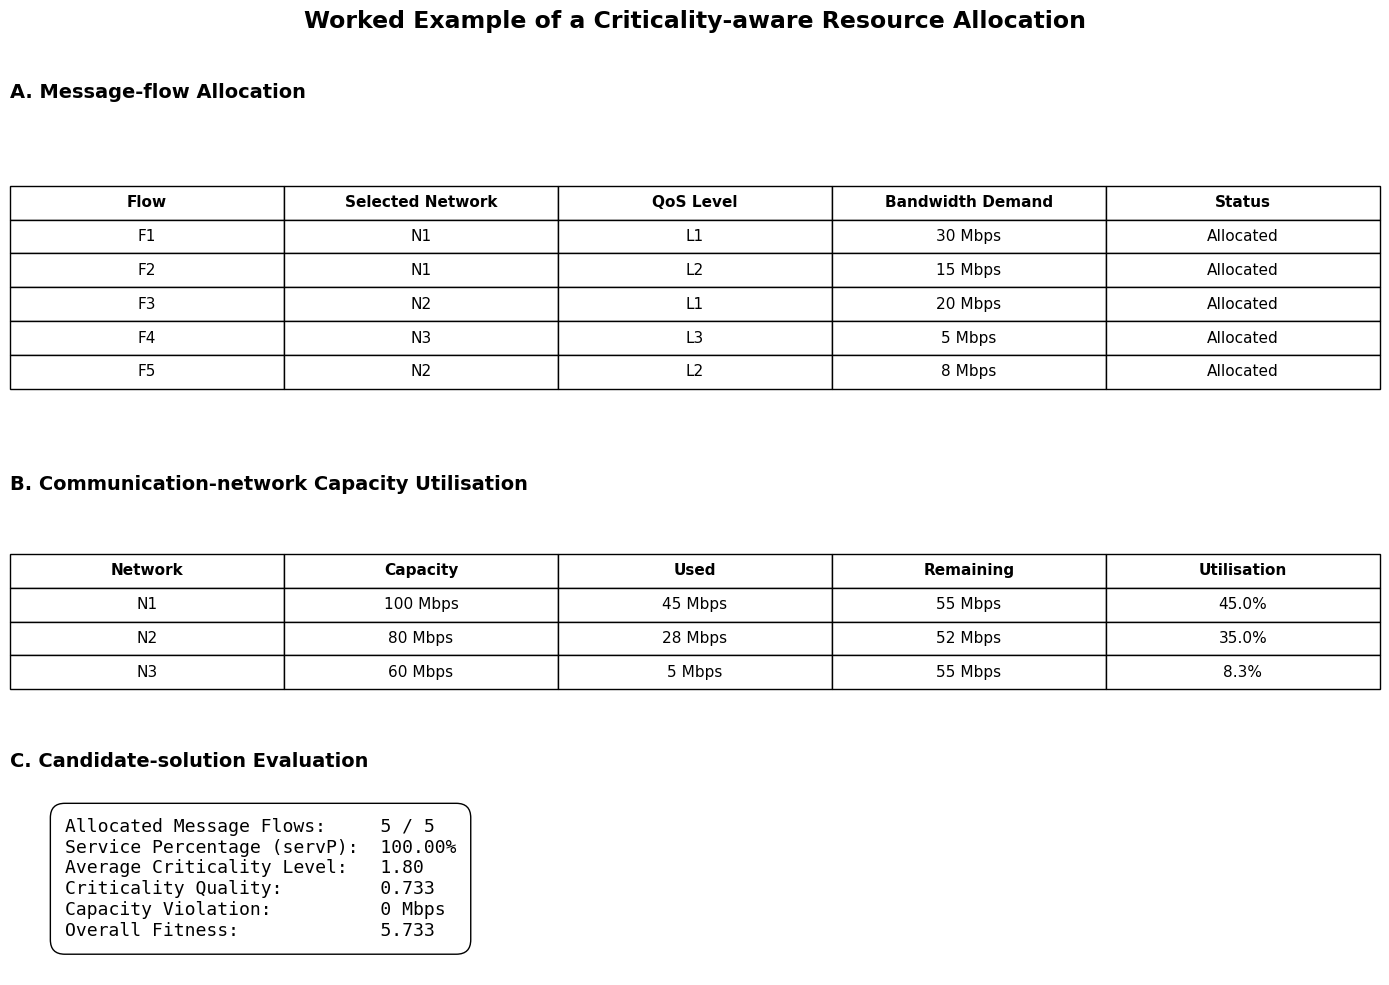


Message-flow Allocation
Flow Selected Network QoS Level Bandwidth Demand    Status
  F1               N1        L1          30 Mbps Allocated
  F2               N1        L2          15 Mbps Allocated
  F3               N2        L1          20 Mbps Allocated
  F4               N3        L3           5 Mbps Allocated
  F5               N2        L2           8 Mbps Allocated

Communication-network Utilisation
Network Capacity    Used Remaining Utilisation
     N1 100 Mbps 45 Mbps   55 Mbps       45.0%
     N2  80 Mbps 28 Mbps   52 Mbps       35.0%
     N3  60 Mbps  5 Mbps   55 Mbps        8.3%

Evaluation Summary
Allocated Message Flows:     5 / 5
Service Percentage (servP):  100.00%
Average Criticality Level:   1.80
Criticality Quality:         0.733
Capacity Violation:          0 Mbps
Overall Fitness:             5.733


In [ ]:
# ==========================================================
# RESOURCE-ALLOCATION DASHBOARD
#
# ==========================================================
#
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Example communication networks
# ----------------------------------------------------------

example_networks = {
    "N1": 100,
    "N2": 80,
    "N3": 60
}

# ----------------------------------------------------------
# 
# ----------------------------------------------------------

example_flows = {
    "F1": {1: 30, 2: 20, 3: 10},
    "F2": {1: 25, 2: 15, 3: 8},
    "F3": {1: 20, 2: 12, 3: 6},
    "F4": {1: 18, 2: 10, 3: 5},
    "F5": {1: 15, 2: 8,  3: 4}
}

# ----------------------------------------------------------
# 3. Example chromosome
#
# Gene_m = (Selected Network, Criticality-aware QoS Level)
# ----------------------------------------------------------

example_chromosome = {
    "F1": ("N1", 1),
    "F2": ("N1", 2),
    "F3": ("N2", 1),
    "F4": ("N3", 3),
    "F5": ("N2", 2)
}

# ----------------------------------------------------------
# 4. Evaluate the candidate solution
# ----------------------------------------------------------

network_loads = {
    network: 0
    for network in example_networks
}

allocation_rows = []

allocated_flows = 0
total_level = 0
total_score = 0

L_MAX = 3

for flow, profile in example_flows.items():

    network, level = example_chromosome.get(
        flow,
        (None, None)
    )

    if (
        network is None
        or level is None
        or network not in example_networks
        or level not in profile
    ):
        allocation_rows.append({
            "Flow": flow,
            "Selected Network": "—",
            "QoS Level": "—",
            "Bandwidth Demand": "—",
            "Status": "Unallocated"
        })
        continue

    demand = profile[level]

    network_loads[network] += demand
    allocated_flows += 1
    total_level += level

    # L1 -> 3, L2 -> 2, L3 -> 1
    level_score = 1 + L_MAX - level
    total_score += level_score

    allocation_rows.append({
        "Flow": flow,
        "Selected Network": network,
        "QoS Level": f"L{level}",
        "Bandwidth Demand": f"{demand} Mbps",
        "Status": "Allocated"
    })

# ----------------------------------------------------------
# 5. Calculate network utilisation
# ----------------------------------------------------------

network_rows = []

capacity_violation = 0

for network, capacity in example_networks.items():

    used = network_loads[network]
    remaining = capacity - used
    violation = max(0, used - capacity)

    capacity_violation += violation

    utilisation = (
        used / capacity
    ) * 100

    network_rows.append({
        "Network": network,
        "Capacity": f"{capacity} Mbps",
        "Used": f"{used} Mbps",
        "Remaining": f"{max(0, remaining)} Mbps",
        "Utilisation": f"{utilisation:.1f}%"
    })

# ----------------------------------------------------------
# 6. Calculate dissertation-aligned metrics
# ----------------------------------------------------------

total_flows = len(example_flows)

service_percentage = (
    allocated_flows / total_flows
)

average_criticality_level = (
    total_level / allocated_flows
    if allocated_flows > 0
    else 0
)

if capacity_violation > 0 or allocated_flows == 0:

    criticality_quality = 0
    fitness = 0

else:

    criticality_quality = (
        total_score
        / (allocated_flows * L_MAX)
    )

    fitness = (
        allocated_flows
        + criticality_quality
    )

allocation_df = pd.DataFrame(allocation_rows)
network_df = pd.DataFrame(network_rows)

# ----------------------------------------------------------
# 7. Create the dashboard figure
# ----------------------------------------------------------

fig = plt.figure(figsize=(14, 10))

grid = fig.add_gridspec(
    nrows=3,
    ncols=1,
    height_ratios=[0.45, 0.30, 0.25]
)

# Main title
fig.suptitle(
    "Worked Example of a Criticality-aware Resource Allocation",
    fontsize=17,
    fontweight="bold",
    y=0.98
)

# ----------------------------------------------------------
# Panel A: Flow allocations
# ----------------------------------------------------------

ax1 = fig.add_subplot(grid[0])
ax1.axis("off")

ax1.set_title(
    "A. Message-flow Allocation",
    fontsize=14,
    fontweight="bold",
    loc="left",
    pad=12
)

table1 = ax1.table(
    cellText=allocation_df.values,
    colLabels=allocation_df.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table1.auto_set_font_size(False)
table1.set_fontsize(11)
table1.scale(1, 1.8)

for column_index in range(len(allocation_df.columns)):
    table1[(0, column_index)].set_text_props(
        weight="bold"
    )

# ----------------------------------------------------------
# Panel B: Network capacity utilisation
# ----------------------------------------------------------

ax2 = fig.add_subplot(grid[1])
ax2.axis("off")

ax2.set_title(
    "B. Communication-network Capacity Utilisation",
    fontsize=14,
    fontweight="bold",
    loc="left",
    pad=12
)

table2 = ax2.table(
    cellText=network_df.values,
    colLabels=network_df.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table2.auto_set_font_size(False)
table2.set_fontsize(11)
table2.scale(1, 1.8)

for column_index in range(len(network_df.columns)):
    table2[(0, column_index)].set_text_props(
        weight="bold"
    )

# ----------------------------------------------------------
# Panel C: Evaluation summary
# ----------------------------------------------------------

ax3 = fig.add_subplot(grid[2])
ax3.axis("off")

ax3.set_title(
    "C. Candidate-solution Evaluation",
    fontsize=14,
    fontweight="bold",
    loc="left",
    pad=12
)

summary_text = (
    f"Allocated Message Flows:     "
    f"{allocated_flows} / {total_flows}\n"
    f"Service Percentage (servP):  "
    f"{service_percentage * 100:.2f}%\n"
    f"Average Criticality Level:   "
    f"{average_criticality_level:.2f}\n"
    f"Criticality Quality:         "
    f"{criticality_quality:.3f}\n"
    f"Capacity Violation:          "
    f"{capacity_violation} Mbps\n"
    f"Overall Fitness:             "
    f"{fitness:.3f}"
)

ax3.text(
    0.04,
    0.82,
    summary_text,
    fontsize=13,
    family="monospace",
    verticalalignment="top",
    bbox={
        "boxstyle": "round,pad=0.8",
        "facecolor": "white",
        "edgecolor": "black"
    }
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.savefig(
    "Worked_Example_Resource_Allocation_Dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Worked_Example_Resource_Allocation_Dashboard.pdf",
    bbox_inches="tight"
)

plt.show()

# ----------------------------------------------------------
# 8. Print the numerical tables
# ----------------------------------------------------------

print("\nMessage-flow Allocation")
print("=" * 75)
print(allocation_df.to_string(index=False))

print("\nCommunication-network Utilisation")
print("=" * 75)
print(network_df.to_string(index=False))

print("\nEvaluation Summary")
print("=" * 75)
print(summary_text)

In [ ]:
# ==========================================================

# ==========================================================

import inspect

print("=" * 70)
print("run_ga() FUNCTION")
print("=" * 70)

source = inspect.getsource(run_ga)

keywords = [
    "fitness_history",
    "history",
    "best_history",
    "best_fitness",
    "generation",
    "append",
    "log",
    "trace",
    "convergence"
]

found = False

for keyword in keywords:

    if keyword in source:

        found = True
        print(f"✓ Found keyword: {keyword}")

print()

if not found:
    print("❌ No obvious convergence history found.")
    print("The GA probably returns only the final solution.")
else:
    print("✓ The GA may already store convergence information.")

print("\n")
print("=" * 70)
print("run_ga SOURCE CODE")
print("=" * 70)

print(source)

run_ga() FUNCTION
✓ Found keyword: fitness_history
✓ Found keyword: history
✓ Found keyword: best_fitness
✓ Found keyword: generation
✓ Found keyword: append

✓ The GA may already store convergence information.


run_ga SOURCE CODE
def run_ga(
    flows,
    networks,
    population_size=30,
    generations=50,
    mutation_rate=0.05,
    tournament_size=3,
    local_search_passes=5,
    show_progress=False
):
    """
    Run the Enhanced Seeded Genetic Algorithm.

    Parameters
    ----------
    flows : dict
        Message-flow bandwidth-demand profiles.

    networks : dict
        Communication-network capacities.

    population_size : int, optional
        Number of chromosomes in the population.

    generations : int, optional
        Number of evolutionary generations.

    mutation_rate : float, optional
        Probability of mutating each gene.

    tournament_size : int, optional
        Number of chromosomes sampled during
        tournament selection.

    local_search

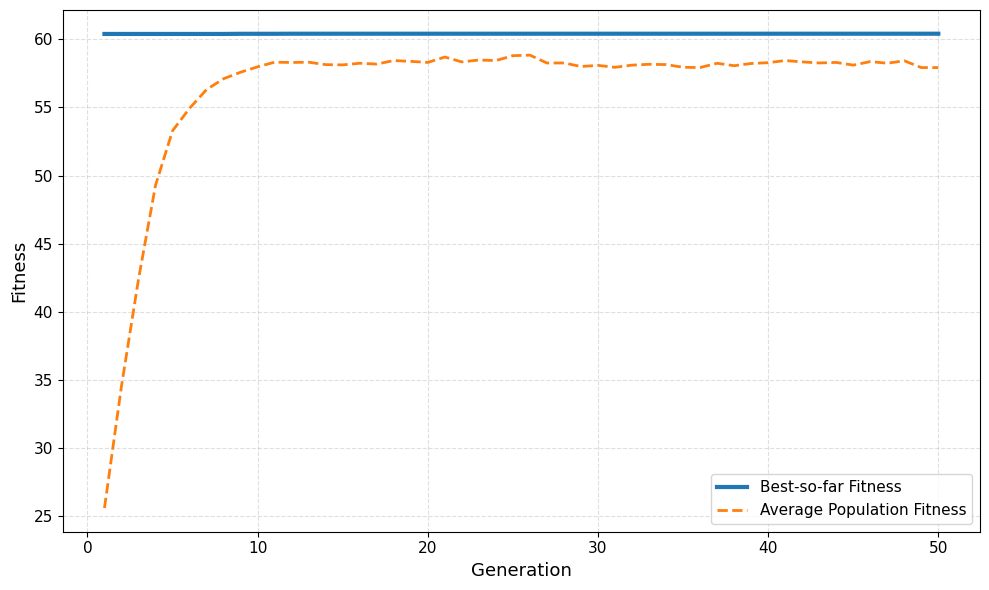

Convergence Analysis Summary
Flow size          : 80
Seed               : 130007
Initial best fitness: 60.3833
Final best fitness  : 60.4000
Initial avg fitness : 25.6204
Final avg fitness   : 57.9173
Final servP         : 0.7500
Final QoS quality   : 0.4000
Capacity violation  : 0


In [ ]:
# ==========================================================
# GA CONVERGENCE ANALYSIS
# ==========================================================
#
# P
# ==========================================================

import random
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Representative convergence scenario
# ----------------------------------------------------------

CONVERGENCE_FLOW_SIZE = 80
CONVERGENCE_SEED = 130007

random.seed(CONVERGENCE_SEED)

convergence_networks, convergence_flows = generate_scenario(
    num_flows=CONVERGENCE_FLOW_SIZE,
    hC=0.8
)

# ----------------------------------------------------------
# ----------------------------------------------------------

(
    convergence_best_solution,
    convergence_best_result,
    best_fitness_history,
    avg_fitness_history
) = run_ga(
    convergence_flows,
    convergence_networks,
    population_size=FINAL_POPULATION_SIZE,
    generations=FINAL_GENERATIONS,
    mutation_rate=FINAL_MUTATION_RATE,
    tournament_size=FINAL_TOURNAMENT_SIZE,
    local_search_passes=FINAL_LOCAL_SEARCH_PASSES
)

# Generation numbers
generations_axis = range(
    1,
    len(best_fitness_history) + 1
)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    generations_axis,
    best_fitness_history,
    linewidth=3,
    label="Best-so-far Fitness"
)

plt.plot(
    generations_axis,
    avg_fitness_history,
    linewidth=2,
    linestyle="--",
    label="Average Population Fitness"
)

plt.xlabel(
    "Generation",
    fontsize=13
)

plt.ylabel(
    "Fitness",
    fontsize=13
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.legend(
    fontsize=11
)

plt.tight_layout()

plt.savefig(
    "Figure_4_4_GA_Convergence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_4_4_GA_Convergence.pdf",
    bbox_inches="tight"
)

plt.show()

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------

print("=" * 60)
print("Convergence Analysis Summary")
print("=" * 60)
print(f"Flow size          : {CONVERGENCE_FLOW_SIZE}")
print(f"Seed               : {CONVERGENCE_SEED}")
print(f"Initial best fitness: {best_fitness_history[0]:.4f}")
print(f"Final best fitness  : {best_fitness_history[-1]:.4f}")
print(f"Initial avg fitness : {avg_fitness_history[0]:.4f}")
print(f"Final avg fitness   : {avg_fitness_history[-1]:.4f}")
print(f"Final servP         : {convergence_best_result['servP']:.4f}")
print(
    f"Final QoS quality   : "
    f"{convergence_best_result['CriticalityQuality']:.4f}"
)
print(
    f"Capacity violation  : "
    f"{convergence_best_result['CapacityViolation']}"
)

In [ ]:
# ==========================================================
# ==========================================================
#
# ==========================================================

ORIGINAL_CREATE_INITIAL_POPULATION = create_initial_population


def create_fully_random_initial_population(
    flows,
    networks,
    population_size=30
):
    """
    Create a fully random feasible population.

    The original seeded initializer creates:
        4 heuristic chromosomes
        + random feasible chromosomes.

    By requesting population_size + 4 and discarding the
    first four chromosomes, this function retains exactly
    population_size random feasible chromosomes.
    """

    if population_size < 1:
        raise ValueError(
            "population_size must be at least 1."
        )

    # IMPORTANT:
    # Call the preserved original function directly,
    # not the temporarily patched global function.
    expanded_population = (
        ORIGINAL_CREATE_INITIAL_POPULATION(
            flows,
            networks,
            population_size=population_size + 4
        )
    )

    random_population = [
        chromosome.copy()
        for chromosome in expanded_population[4:]
    ]

    if len(random_population) != population_size:
        raise RuntimeError(
            "The random population does not have the "
            "requested population size."
        )

    random_population = [
        repair_solution(
            chromosome,
            flows,
            networks
        )
        for chromosome in random_population
    ]

    return random_population


def run_random_ga(
    flows,
    networks,
    population_size=30,
    generations=50,
    mutation_rate=0.05,
    tournament_size=3,
    local_search_passes=5,
    show_progress=False
):
    """
    Run the same GA implementation using a fully random
    initial population instead of heuristic seeding.
    """

    current_initializer = run_ga.__globals__[
        "create_initial_population"
    ]

    try:
        run_ga.__globals__[
            "create_initial_population"
        ] = create_fully_random_initial_population

        result = run_ga(
            flows,
            networks,
            population_size=population_size,
            generations=generations,
            mutation_rate=mutation_rate,
            tournament_size=tournament_size,
            local_search_passes=local_search_passes,
            show_progress=show_progress
        )

    finally:
        # Restore the normal seeded implementation.
        run_ga.__globals__[
            "create_initial_population"
        ] = current_initializer

    return result


print(
    "Corrected randomly initialized GA variant "
    "created successfully."
)

Corrected randomly initialized GA variant created successfully.


In [ ]:
# ==========================================================
#
# ==========================================================

import random

VALIDATION_SEED = 130007
VALIDATION_FLOW_SIZE = 80

random.seed(VALIDATION_SEED)

validation_networks, validation_flows = generate_scenario(
    num_flows=VALIDATION_FLOW_SIZE,
    hC=0.8
)

# Use controlled GA seeds
random.seed(VALIDATION_SEED + 1_000_000)

(
    seeded_solution,
    seeded_result,
    seeded_best_history,
    seeded_avg_history
) = run_ga(
    validation_flows,
    validation_networks,
    population_size=FINAL_POPULATION_SIZE,
    generations=FINAL_GENERATIONS,
    mutation_rate=FINAL_MUTATION_RATE,
    tournament_size=FINAL_TOURNAMENT_SIZE,
    local_search_passes=FINAL_LOCAL_SEARCH_PASSES
)

random.seed(VALIDATION_SEED + 1_000_000)

(
    random_solution,
    random_result,
    random_best_history,
    random_avg_history
) = run_random_ga(
    validation_flows,
    validation_networks,
    population_size=FINAL_POPULATION_SIZE,
    generations=FINAL_GENERATIONS,
    mutation_rate=FINAL_MUTATION_RATE,
    tournament_size=FINAL_TOURNAMENT_SIZE,
    local_search_passes=FINAL_LOCAL_SEARCH_PASSES
)

print("=" * 72)
print("Seeded GA versus Random GA — Quick Validation")
print("=" * 72)

for name, result in [
    ("Seeded GA", seeded_result),
    ("Random GA", random_result)
]:
    print(f"\n{name}")
    print("-" * 40)
    print(
        f"Allocated Flows    : "
        f"{result['AllocatedFlows']}"
    )
    print(
        f"Service Percentage : "
        f"{result['servP']:.4f}"
    )
    print(
        f"Criticality Quality: "
        f"{result['CriticalityQuality']:.4f}"
    )
    print(
        f"Fitness            : "
        f"{result['Fitness']:.4f}"
    )
    print(
        f"Capacity Violation : "
        f"{result['CapacityViolation']}"
    )

assert seeded_result["CapacityViolation"] == 0
assert random_result["CapacityViolation"] == 0

print("\nAblation validation passed.")

Seeded GA versus Random GA — Quick Validation

Seeded GA
----------------------------------------
Allocated Flows    : 60
Service Percentage : 0.7500
Criticality Quality: 0.4000
Fitness            : 60.4000
Capacity Violation : 0

Random GA
----------------------------------------
Allocated Flows    : 59
Service Percentage : 0.7375
Criticality Quality: 0.4181
Fitness            : 59.4181
Capacity Violation : 0

Ablation validation passed.


In [ ]:
# ==========================================================
# 
# ==========================================================

import random
import time
import pandas as pd

ABLATION_FLOW_SIZES = (20, 40, 80, 120, 160)
ABLATION_RUNS = 30

ABLATION_BASE_SEED = 300000
ABLATION_GA_SEED_OFFSET = 1_000_000

ablation_rows = []
convergence_rows = []

for num_flows in ABLATION_FLOW_SIZES:

    print(
        f"\nAblation benchmark: {num_flows} flows "
        f"across {ABLATION_RUNS} paired runs..."
    )

    for run_index in range(ABLATION_RUNS):

        scenario_seed = (
            ABLATION_BASE_SEED
            + num_flows * 1000
            + run_index
        )

        ga_seed = (
            scenario_seed
            + ABLATION_GA_SEED_OFFSET
        )

        # ----------------------------------------------
        # Generate one shared benchmark scenario
        # ----------------------------------------------
        random.seed(scenario_seed)

        networks, flows = generate_scenario(
            num_flows=num_flows,
            hC=0.8
        )

        # ----------------------------------------------
        # Proposed Seeded GA
        # ----------------------------------------------
        random.seed(ga_seed)

        start_time = time.perf_counter()

        (
            seeded_allocation,
            seeded_metrics,
            seeded_best_history,
            seeded_avg_history
        ) = run_ga(
            flows,
            networks,
            population_size=FINAL_POPULATION_SIZE,
            generations=FINAL_GENERATIONS,
            mutation_rate=FINAL_MUTATION_RATE,
            tournament_size=FINAL_TOURNAMENT_SIZE,
            local_search_passes=FINAL_LOCAL_SEARCH_PASSES
        )

        seeded_time = (
            time.perf_counter() - start_time
        )

        ablation_rows.append({
            "Flows": num_flows,
            "Run": run_index + 1,
            "Scenario Seed": scenario_seed,
            "GA Seed": ga_seed,
            "Variant": "Seeded GA",
            "servP": seeded_metrics["servP"],
            "avCL": seeded_metrics["avCL"],
            "Allocated Flows":
                seeded_metrics["AllocatedFlows"],
            "Criticality Quality":
                seeded_metrics["CriticalityQuality"],
            "Fitness": seeded_metrics["Fitness"],
            "Capacity Violation":
                seeded_metrics["CapacityViolation"],
            "Execution Time (s)": seeded_time
        })

        for generation_index, (
            best_value,
            avg_value
        ) in enumerate(
            zip(
                seeded_best_history,
                seeded_avg_history
            ),
            start=1
        ):
            convergence_rows.append({
                "Flows": num_flows,
                "Run": run_index + 1,
                "Variant": "Seeded GA",
                "Generation": generation_index,
                "Best Fitness": best_value,
                "Average Fitness": avg_value
            })

        # ----------------------------------------------
        # Randomly Initialised GA
        # ----------------------------------------------
        random.seed(ga_seed)

        start_time = time.perf_counter()

        (
            random_allocation,
            random_metrics,
            random_best_history,
            random_avg_history
        ) = run_random_ga(
            flows,
            networks,
            population_size=FINAL_POPULATION_SIZE,
            generations=FINAL_GENERATIONS,
            mutation_rate=FINAL_MUTATION_RATE,
            tournament_size=FINAL_TOURNAMENT_SIZE,
            local_search_passes=FINAL_LOCAL_SEARCH_PASSES
        )

        random_time = (
            time.perf_counter() - start_time
        )

        ablation_rows.append({
            "Flows": num_flows,
            "Run": run_index + 1,
            "Scenario Seed": scenario_seed,
            "GA Seed": ga_seed,
            "Variant": "Random GA",
            "servP": random_metrics["servP"],
            "avCL": random_metrics["avCL"],
            "Allocated Flows":
                random_metrics["AllocatedFlows"],
            "Criticality Quality":
                random_metrics["CriticalityQuality"],
            "Fitness": random_metrics["Fitness"],
            "Capacity Violation":
                random_metrics["CapacityViolation"],
            "Execution Time (s)": random_time
        })

        for generation_index, (
            best_value,
            avg_value
        ) in enumerate(
            zip(
                random_best_history,
                random_avg_history
            ),
            start=1
        ):
            convergence_rows.append({
                "Flows": num_flows,
                "Run": run_index + 1,
                "Variant": "Random GA",
                "Generation": generation_index,
                "Best Fitness": best_value,
                "Average Fitness": avg_value
            })

        print(
            f"  Paired run {run_index + 1}/"
            f"{ABLATION_RUNS} completed",
            flush=True
        )

ablation_raw_df = pd.DataFrame(
    ablation_rows
)

ablation_convergence_df = pd.DataFrame(
    convergence_rows
)

# Confirm feasibility
assert (
    ablation_raw_df["Capacity Violation"] == 0
).all(), (
    "At least one GA variant produced an "
    "infeasible allocation."
)

ablation_summary_df = (
    ablation_raw_df
    .groupby(
        ["Flows", "Variant"],
        as_index=False
    )
    .agg(
        Mean_servP=("servP", "mean"),
        SD_servP=("servP", "std"),
        Mean_Allocated_Flows=(
            "Allocated Flows",
            "mean"
        ),
        SD_Allocated_Flows=(
            "Allocated Flows",
            "std"
        ),
        Mean_Criticality_Quality=(
            "Criticality Quality",
            "mean"
        ),
        SD_Criticality_Quality=(
            "Criticality Quality",
            "std"
        ),
        Mean_Fitness=("Fitness", "mean"),
        SD_Fitness=("Fitness", "std"),
        Mean_Execution_Time_s=(
            "Execution Time (s)",
            "mean"
        ),
        SD_Execution_Time_s=(
            "Execution Time (s)",
            "std"
        )
    )
)

print("\n" + "=" * 110)
print("Seeded GA versus Random GA — Ablation Summary")
print("=" * 110)

print(
    ablation_summary_df
    .round(5)
    .to_string(index=False)
)

ablation_raw_df.to_csv(
    "GA_Ablation_Raw.csv",
    index=False
)

ablation_summary_df.to_csv(
    "GA_Ablation_Summary.csv",
    index=False
)

ablation_convergence_df.to_csv(
    "GA_Ablation_Convergence.csv",
    index=False
)

print("\nAblation files exported successfully.")


Ablation benchmark: 20 flows across 30 paired runs...
  Paired run 1/30 completed
  Paired run 2/30 completed
  Paired run 3/30 completed
  Paired run 4/30 completed
  Paired run 5/30 completed
  Paired run 6/30 completed
  Paired run 7/30 completed
  Paired run 8/30 completed
  Paired run 9/30 completed
  Paired run 10/30 completed
  Paired run 11/30 completed
  Paired run 12/30 completed
  Paired run 13/30 completed
  Paired run 14/30 completed
  Paired run 15/30 completed
  Paired run 16/30 completed
  Paired run 17/30 completed
  Paired run 18/30 completed
  Paired run 19/30 completed
  Paired run 20/30 completed
  Paired run 21/30 completed
  Paired run 22/30 completed
  Paired run 23/30 completed
  Paired run 24/30 completed
  Paired run 25/30 completed
  Paired run 26/30 completed
  Paired run 27/30 completed
  Paired run 28/30 completed
  Paired run 29/30 completed
  Paired run 30/30 completed

Ablation benchmark: 40 flows across 30 paired runs...
  Paired run 1/30 completed
 

In [ ]:
# ==========================================================
# 
# ==========================================================

import numpy as np
import pandas as pd

try:
    from scipy.stats import wilcoxon
except ImportError as exc:
    raise ImportError(
        "SciPy is required for the Wilcoxon test. "
        "Install it with: pip install scipy"
    ) from exc


def paired_cohens_dz(differences):
    """
    Paired-samples Cohen's dz.
    Positive values favour the Proposed Seeded GA.
    """
    differences = np.asarray(
        differences,
        dtype=float
    )

    sd_difference = differences.std(ddof=1)

    if sd_difference == 0:
        return np.inf if differences.mean() > 0 else 0.0

    return differences.mean() / sd_difference


def bootstrap_mean_difference_ci(
    differences,
    confidence=0.95,
    bootstrap_samples=10000,
    seed=42
):
    """
    Bootstrap confidence interval for the paired mean
    difference.
    """
    differences = np.asarray(
        differences,
        dtype=float
    )

    rng = np.random.default_rng(seed)

    bootstrap_means = np.empty(
        bootstrap_samples
    )

    for index in range(bootstrap_samples):

        sample = rng.choice(
            differences,
            size=len(differences),
            replace=True
        )

        bootstrap_means[index] = sample.mean()

    alpha = 1 - confidence

    lower = np.quantile(
        bootstrap_means,
        alpha / 2
    )

    upper = np.quantile(
        bootstrap_means,
        1 - alpha / 2
    )

    return lower, upper


# Standardise the GA label used in the original benchmark
stats_source_df = benchmark_raw_df.copy()

stats_source_df["Algorithm"] = (
    stats_source_df["Algorithm"]
    .replace(
        "Enhanced Seeded GA",
        "Proposed Seeded GA"
    )
)

metrics_to_test = {
    "servP": "Service Percentage",
    "Criticality Quality": "Criticality Quality",
    "Fitness": "Overall Fitness"
}

statistical_rows = []

for num_flows in sorted(
    stats_source_df["Flows"].unique()
):

    flow_df = stats_source_df[
        stats_source_df["Flows"] == num_flows
    ]

    for metric_column, metric_name in (
        metrics_to_test.items()
    ):

        paired_df = (
            flow_df[
                flow_df["Algorithm"].isin([
                    "Proposed Seeded GA",
                    "CABFinv"
                ])
            ]
            .pivot(
                index="Run",
                columns="Algorithm",
                values=metric_column
            )
            .dropna()
        )

        proposed_values = paired_df[
            "Proposed Seeded GA"
        ].to_numpy()

        baseline_values = paired_df[
            "CABFinv"
        ].to_numpy()

        differences = (
            proposed_values - baseline_values
        )

        nonzero_differences = differences[
            differences != 0
        ]

        if len(nonzero_differences) == 0:

            statistic = 0.0
            p_value = 1.0

        else:

            test_result = wilcoxon(
                proposed_values,
                baseline_values,
                alternative="two-sided",
                zero_method="wilcox"
            )

            statistic = test_result.statistic
            p_value = test_result.pvalue

        ci_lower, ci_upper = (
            bootstrap_mean_difference_ci(
                differences,
                confidence=0.95,
                bootstrap_samples=10000,
                seed=5000 + num_flows
            )
        )

        effect_size = paired_cohens_dz(
            differences
        )

        statistical_rows.append({
            "Flows": num_flows,
            "Metric": metric_name,
            "Pairs": len(paired_df),
            "Proposed Mean":
                proposed_values.mean(),
            "CABFinv Mean":
                baseline_values.mean(),
            "Mean Difference":
                differences.mean(),
            "95% CI Lower": ci_lower,
            "95% CI Upper": ci_upper,
            "Wilcoxon Statistic": statistic,
            "p-value": p_value,
            "Significant at 0.05":
                p_value < 0.05,
            "Cohen dz": effect_size
        })

significance_df = pd.DataFrame(
    statistical_rows
)

print("=" * 140)
print(
    "Paired Statistical Analysis: "
    "Proposed Seeded GA versus CABFinv"
)
print("=" * 140)

print(
    significance_df
    .round(6)
    .to_string(index=False)
)

significance_df.to_csv(
    "Seeded_GA_vs_CABFinv_Statistical_Tests.csv",
    index=False
)

Paired Statistical Analysis: Proposed Seeded GA versus CABFinv
 Flows              Metric  Pairs  Proposed Mean  CABFinv Mean  Mean Difference  95% CI Lower  95% CI Upper  Wilcoxon Statistic  p-value  Significant at 0.05  Cohen dz
    20  Service Percentage     30       1.000000      0.985000         0.015000      0.006667      0.025000                 0.0 0.006656                 True  0.560765
    20 Criticality Quality     30       0.793333      0.778298         0.015036      0.004515      0.024452                97.0 0.008866                 True  0.532414
    20     Overall Fitness     30      20.793333     20.478298         0.315036      0.154269      0.506858                 0.0 0.000002                 True  0.615580
    40  Service Percentage     30       0.889167      0.775000         0.114167      0.104167      0.124167                 0.0 0.000001                 True  4.135245
    40 Criticality Quality     30       0.570861      0.616933        -0.046072     -0.055216    

In [ ]:
# ==========================================
# LARGE-SCALE DISSERTATION BENCHMARK
# ==========================================

LARGE_FLOW_SIZES = (320, 500, 750, 1000)
LARGE_RUNS = 30

large_benchmark_raw_df, large_benchmark_summary_df = run_ga_benchmark(
    flow_sizes=LARGE_FLOW_SIZES,
    runs=LARGE_RUNS,
    population_size=FINAL_POPULATION_SIZE,
    generations=FINAL_GENERATIONS,
    mutation_rate=FINAL_MUTATION_RATE,
    tournament_size=FINAL_TOURNAMENT_SIZE,
    local_search_passes=FINAL_LOCAL_SEARCH_PASSES,
    base_seed=FINAL_BASE_SEED
)

display(large_benchmark_summary_df)


Benchmarking 320 flows across 30 runs...
  Run 1/30 completed
  Run 2/30 completed
  Run 3/30 completed
  Run 4/30 completed
  Run 5/30 completed
  Run 6/30 completed
  Run 7/30 completed
  Run 8/30 completed
  Run 9/30 completed
  Run 10/30 completed
  Run 11/30 completed
  Run 12/30 completed
  Run 13/30 completed
  Run 14/30 completed
  Run 15/30 completed
  Run 16/30 completed
  Run 17/30 completed
  Run 18/30 completed
  Run 19/30 completed
  Run 20/30 completed
  Run 21/30 completed
  Run 22/30 completed
  Run 23/30 completed
  Run 24/30 completed
  Run 25/30 completed
  Run 26/30 completed
  Run 27/30 completed
  Run 28/30 completed
  Run 29/30 completed
  Run 30/30 completed

Benchmarking 500 flows across 30 runs...
  Run 1/30 completed
  Run 2/30 completed
  Run 3/30 completed
  Run 4/30 completed
  Run 5/30 completed
  Run 6/30 completed
  Run 7/30 completed
  Run 8/30 completed
  Run 9/30 completed
  Run 10/30 completed
  Run 11/30 completed
  Run 12/30 completed
  Run 13/3

,Flows,Algorithm,Mean_servP,SD_servP,Mean_avCL,SD_avCL,Mean_Allocated_Flows,SD_Allocated_Flows,Mean_Criticality_Quality,SD_Criticality_Quality,Mean_Fitness,SD_Fitness,Mean_Execution_Time_s,SD_Execution_Time_s
0,320,BF,0.052604,0.005064,1.493535,0.118908,16.833333,1.620629,0.835488,0.039636,17.668822,1.601390,0.000126,0.000007
1,320,CABF,0.214479,0.014414,3.000000,0.000000,68.633333,4.612452,0.333333,0.000000,68.966667,4.612452,0.000227,0.000016
2,320,CABFinv,0.214479,0.014414,3.000000,0.000000,68.633333,4.612452,0.333333,0.000000,68.966667,4.612452,0.000213,0.000008
3,320,Enhanced Seeded GA,0.319479,0.014016,2.970466,0.014838,102.233333,4.485097,0.343178,0.004946,102.576511,4.483614,354.870288,16.455252
4,320,FF,0.053646,0.005131,1.523495,0.119592,17.166667,1.641768,0.825502,0.039864,17.992168,1.625365,0.000136,0.000014
5,500,BF,0.033133,0.003224,1.510454,0.113625,16.566667,1.612095,0.829849,0.037875,17.396515,1.596032,0.000191,0.000004
6,500,CABF,0.136533,0.007519,3.000000,0.000000,68.266667,3.759433,0.333333,0.000000,68.600000,3.759433,0.000318,0.000007
7,500,CABFinv,0.136533,0.007519,3.000000,0.000000,68.266667,3.759433,0.333333,0.000000,68.600000,3.759433,0.000308,0.000009
8,500,Enhanced Seeded GA,0.231333,0.004823,2.986074,0.011186,115.666667,2.411658,0.337975,0.003729,116.004642,2.410125,853.972559,18.276434
9,500,FF,0.034400,0.003035,1.556113,0.134344,17.200000,1.517712,0.814629,0.044781,18.014629,1.495136,0.000188,0.000008


In [ ]:
# ==========================================================
# HOLM CORRECTION FOR MULTIPLE COMPARISONS
# Proposed Seeded GA versus CABFinv
# ==========================================================

import numpy as np
import pandas as pd


def holm_adjust(p_values):
    """
    Apply Holm's step-down correction to a sequence of p-values.
    Returns adjusted p-values in the original order.
    """
    p_values = np.asarray(p_values, dtype=float)

    m = len(p_values)
    order = np.argsort(p_values)
    sorted_p = p_values[order]

    adjusted_sorted = np.empty(m, dtype=float)

    running_max = 0.0

    for i, p_value in enumerate(sorted_p):
        adjusted = (m - i) * p_value
        running_max = max(running_max, adjusted)
        adjusted_sorted[i] = min(running_max, 1.0)

    adjusted = np.empty(m, dtype=float)
    adjusted[order] = adjusted_sorted

    return adjusted


# ----------------------------------------------------------
# Apply Holm correction to the paired statistical tests
# ----------------------------------------------------------

final_statistical_results = significance_df.copy()

final_statistical_results["Holm-adjusted p-value"] = holm_adjust(
    final_statistical_results["p-value"].values
)

final_statistical_results[
    "Significant after Holm (p < 0.05)"
] = (
    final_statistical_results["Holm-adjusted p-value"]
    < 0.05
)


# ----------------------------------------------------------
# 
# ----------------------------------------------------------

def effect_size_label(d):
    abs_d = abs(d)

    if abs_d < 0.2:
        return "Negligible"
    elif abs_d < 0.5:
        return "Small"
    elif abs_d < 0.8:
        return "Medium"
    else:
        return "Large"


final_statistical_results["Effect Size"] = (
    final_statistical_results["Cohen dz"]
    .apply(effect_size_label)
)


# ----------------------------------------------------------
# Dissertation-friendly column names
# ----------------------------------------------------------

final_statistical_results = (
    final_statistical_results.rename(
        columns={
            "Proposed Mean": "GA Mean",
            "Cohen dz": "Paired Cohen's d"
        }
    )
)


# ----------------------------------------------------------
# Display final statistical table
# ----------------------------------------------------------

display_columns = [
    "Flows",
    "Metric",
    "GA Mean",
    "CABFinv Mean",
    "Mean Difference",
    "p-value",
    "Holm-adjusted p-value",
    "Paired Cohen's d",
    "Effect Size",
    "Significant after Holm (p < 0.05)"
]

print(
    final_statistical_results[
        display_columns
    ]
    .round(6)
    .to_string(index=False)
)


# ----------------------------------------------------------
# Save final results
# ----------------------------------------------------------

final_statistical_results[
    display_columns
].to_csv(
    "final_statistical_results.csv",
    index=False
)

print(
    "\nSaved: final_statistical_results.csv"
)

 Flows              Metric   GA Mean  CABFinv Mean  Mean Difference  p-value  Holm-adjusted p-value  Paired Cohen's d Effect Size  Significant after Holm (p < 0.05)
    20  Service Percentage  1.000000      0.985000         0.015000 0.006656               0.013311          0.560765      Medium                               True
    20 Criticality Quality  0.793333      0.778298         0.015036 0.008866               0.013311          0.532414      Medium                               True
    20     Overall Fitness 20.793333     20.478298         0.315036 0.000002               0.000023          0.615580      Medium                               True
    40  Service Percentage  0.889167      0.775000         0.114167 0.000001               0.000021          4.135245       Large                               True
    40 Criticality Quality  0.570861      0.616933        -0.046072 0.000002               0.000023         -1.783405       Large                               True
    40    

In [ ]:
large_benchmark_raw_df.to_csv(
    "Large_Scale_Benchmark_Raw.csv",
    index=False
)

large_benchmark_summary_df.to_csv(
    "Large_Scale_Benchmark_Summary.csv",
    index=False
)

print("Large-scale benchmark safely saved.")

Large-scale benchmark safely saved.


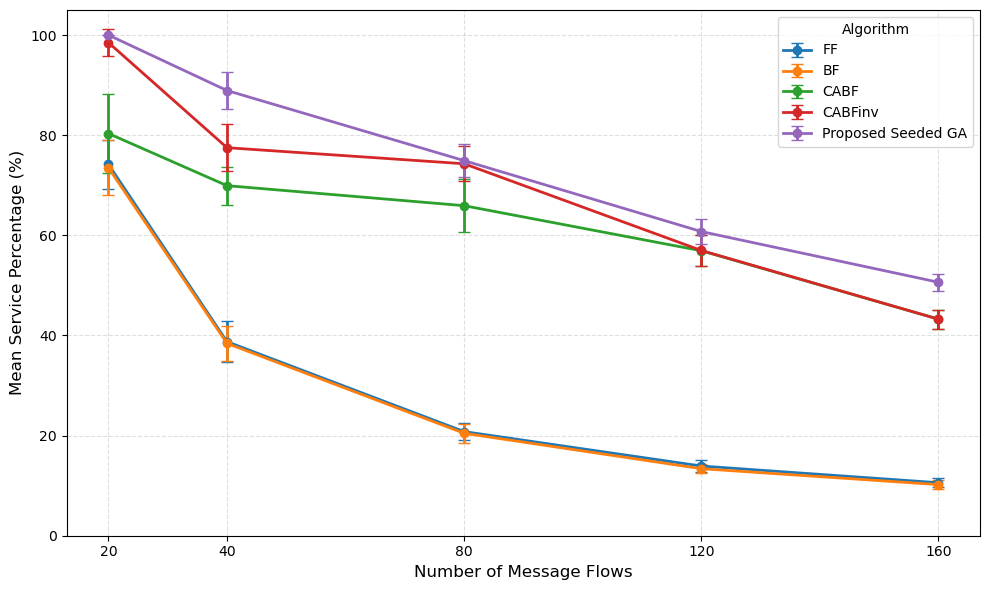

In [ ]:
# ==========================================================
#  Mean Service Percentage vs Message Flows
# ==========================================================

import matplotlib.pyplot as plt

plot_df = benchmark_summary_df.copy()

plot_df["Algorithm"] = plot_df["Algorithm"].replace(
    "Enhanced Seeded GA",
    "Proposed Seeded GA"
)

algorithm_order = [
    "FF",
    "BF",
    "CABF",
    "CABFinv",
    " Seeded GA"
]

plt.figure(figsize=(10, 6))

for algorithm in algorithm_order:

    data = (
        plot_df[
            plot_df["Algorithm"] == algorithm
        ]
        .sort_values("Flows")
    )

    plt.errorbar(
        data["Flows"],
        data["Mean_servP"] * 100,
        yerr=data["SD_servP"] * 100,
        marker="o",
        linewidth=2,
        markersize=6,
        capsize=4,
        label=algorithm
    )

plt.xlabel(
    "Number of Message Flows",
    fontsize=12
)

plt.ylabel(
    "Mean Service Percentage (%)",
    fontsize=12
)

plt.xticks(
    [20, 40, 80, 120, 160]
)

plt.ylim(
    0,
    105
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.legend(
    title="Algorithm"
)

plt.tight_layout()

plt.savefig(
    "Figure_5_1_Service_Percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_5_1_Service_Percentage.pdf",
    bbox_inches="tight"
)

plt.show()

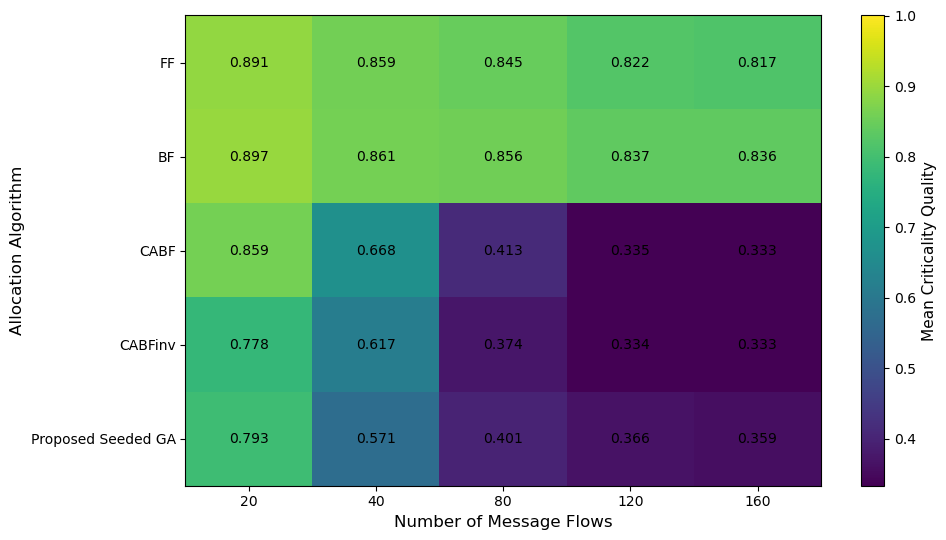

In [ ]:
# ==========================================================
#  Mean Criticality Quality
# ==========================================================

import matplotlib.pyplot as plt
import pandas as pd

# Copy final benchmark summary
plot_df = benchmark_summary_df.copy()

# Dissertation naming
plot_df["Algorithm"] = plot_df["Algorithm"].replace(
    "Enhanced Seeded GA",
    "Proposed Seeded GA"
)

algorithm_order = [
    "FF",
    "BF",
    "CABF",
    "CABFinv",
    "Proposed Seeded GA"
]

flow_order = [20, 40, 80, 120, 160]

# Create matrix from ACTUAL 30-run means
heatmap_data = (
    plot_df.pivot(
        index="Algorithm",
        columns="Flows",
        values="Mean_Criticality_Quality"
    )
    .reindex(index=algorithm_order, columns=flow_order)
)

# Safety check
if heatmap_data.isna().any().any():
    raise ValueError(
        "Missing Criticality Quality values in benchmark_summary_df."
    )

fig, ax = plt.subplots(figsize=(10, 5.5))

im = ax.imshow(
    heatmap_data.values,
    aspect="auto",
    vmin=1/3,
    vmax=1.0
)

# Axis labels
ax.set_xticks(range(len(flow_order)))
ax.set_xticklabels(flow_order)

ax.set_yticks(range(len(algorithm_order)))
ax.set_yticklabels(algorithm_order)

ax.set_xlabel("Number of Message Flows", fontsize=12)
ax.set_ylabel("Allocation Algorithm", fontsize=12)

# Actual values inside cells
for i in range(len(algorithm_order)):
    for j in range(len(flow_order)):
        value = heatmap_data.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.3f}",
            ha="center",
            va="center"
        )

# Colour bar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Mean Criticality Quality", fontsize=11)

plt.tight_layout()

# Save dissertation-quality versions
plt.savefig(
    "Figure_5_2_Criticality_Quality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_5_2_Criticality_Quality.pdf",
    bbox_inches="tight"
)

plt.show()

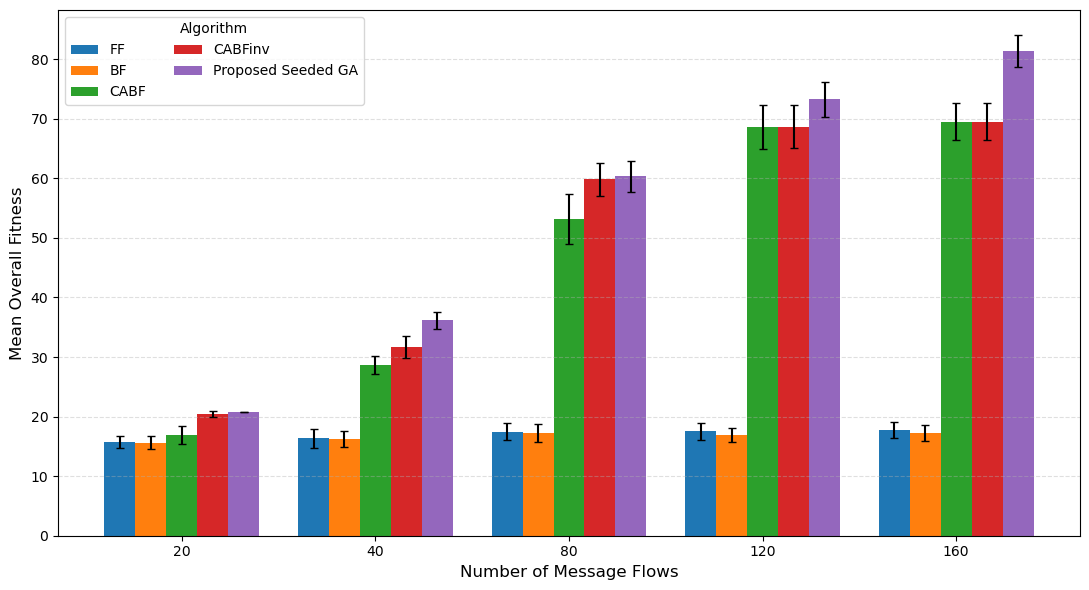

In [ ]:
# ==========================================================
#  Mean Overall Fitness vs Number of Message Flows
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

plot_df = benchmark_summary_df.copy()

# Dissertation naming
plot_df["Algorithm"] = plot_df["Algorithm"].replace(
    "Enhanced Seeded GA",
    "Proposed Seeded GA"
)

algorithm_order = [
    "FF",
    "BF",
    "CABF",
    "CABFinv",
    "Proposed Seeded GA"
]

flow_order = [20, 40, 80, 120, 160]

# Check that all required results exist
required_columns = [
    "Flows",
    "Algorithm",
    "Mean_Fitness",
    "SD_Fitness"
]

missing = [
    col for col in required_columns
    if col not in plot_df.columns
]

if missing:
    raise ValueError(
        f"Missing required columns: {missing}"
    )

x = np.arange(len(flow_order))
bar_width = 0.16

fig, ax = plt.subplots(figsize=(11, 6))

for i, algorithm in enumerate(algorithm_order):

    data = (
        plot_df[
            plot_df["Algorithm"] == algorithm
        ]
        .set_index("Flows")
        .reindex(flow_order)
    )

    if data["Mean_Fitness"].isna().any():
        raise ValueError(
            f"Missing fitness data for {algorithm}"
        )

    positions = x + (
        i - (len(algorithm_order) - 1) / 2
    ) * bar_width

    ax.bar(
        positions,
        data["Mean_Fitness"],
        width=bar_width,
        yerr=data["SD_Fitness"],
        capsize=3,
        label=algorithm
    )

ax.set_xlabel(
    "Number of Message Flows",
    fontsize=12
)

ax.set_ylabel(
    "Mean Overall Fitness",
    fontsize=12
)

ax.set_xticks(x)
ax.set_xticklabels(flow_order)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

ax.legend(
    title="Algorithm",
    ncol=2
)

plt.tight_layout()

plt.savefig(
    "Figure_5_3_Overall_Fitness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_5_3_Overall_Fitness.pdf",
    bbox_inches="tight"
)

plt.show()

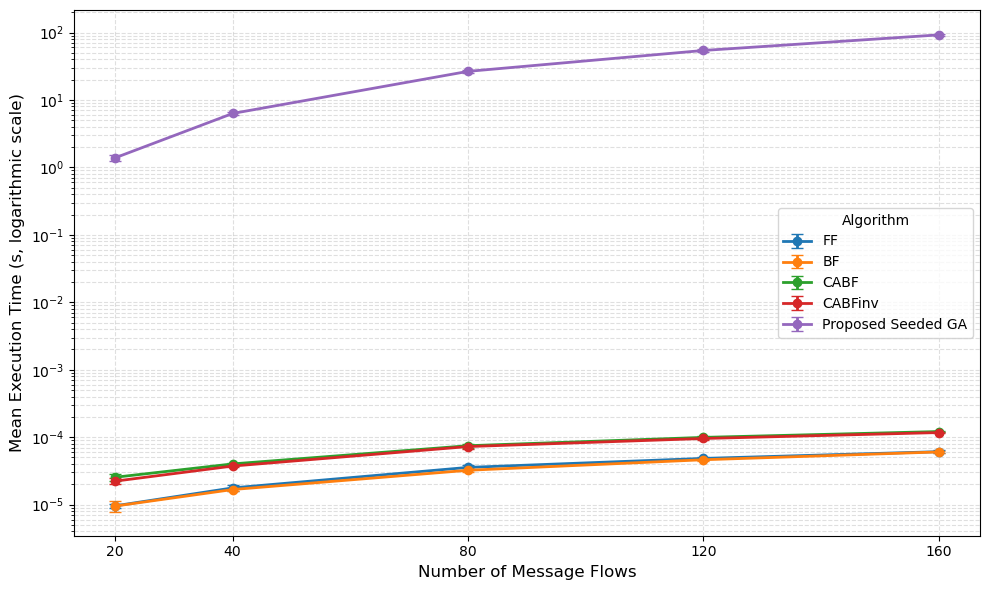

In [ ]:
# ==========================================================
#  Mean Execution Time vs Number of Message Flows
# ==========================================================

import matplotlib.pyplot as plt

plot_df = benchmark_summary_df.copy()

# Dissertation naming
plot_df["Algorithm"] = plot_df["Algorithm"].replace(
    "Enhanced Seeded GA",
    "Proposed Seeded GA"
)

algorithm_order = [
    "FF",
    "BF",
    "CABF",
    "CABFinv",
    "Proposed Seeded GA"
]

flow_order = [20, 40, 80, 120, 160]

required_columns = [
    "Flows",
    "Algorithm",
    "Mean_Execution_Time_s",
    "SD_Execution_Time_s"
]

missing = [
    col for col in required_columns
    if col not in plot_df.columns
]

if missing:
    raise ValueError(
        f"Missing required columns: {missing}"
    )

plt.figure(figsize=(10, 6))

for algorithm in algorithm_order:

    data = (
        plot_df[
            plot_df["Algorithm"] == algorithm
        ]
        .sort_values("Flows")
    )

    if data["Mean_Execution_Time_s"].isna().any():
        raise ValueError(
            f"Missing execution-time data for {algorithm}"
        )

    plt.errorbar(
        data["Flows"],
        data["Mean_Execution_Time_s"],
        yerr=data["SD_Execution_Time_s"],
        marker="o",
        linewidth=2,
        markersize=6,
        capsize=4,
        label=algorithm
    )

plt.yscale("log")

plt.xlabel(
    "Number of Message Flows",
    fontsize=12
)

plt.ylabel(
    "Mean Execution Time (s, logarithmic scale)",
    fontsize=12
)

plt.xticks(flow_order)

plt.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.4
)

plt.legend(
    title="Algorithm"
)

plt.tight_layout()

plt.savefig(
    "Figure_5_4_Execution_Time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_5_4_Execution_Time.pdf",
    bbox_inches="tight"
)

plt.show()

Convergence run 1/30 completed
Convergence run 2/30 completed
Convergence run 3/30 completed
Convergence run 4/30 completed
Convergence run 5/30 completed
Convergence run 6/30 completed
Convergence run 7/30 completed
Convergence run 8/30 completed
Convergence run 9/30 completed
Convergence run 10/30 completed
Convergence run 11/30 completed
Convergence run 12/30 completed
Convergence run 13/30 completed
Convergence run 14/30 completed
Convergence run 15/30 completed
Convergence run 16/30 completed
Convergence run 17/30 completed
Convergence run 18/30 completed
Convergence run 19/30 completed
Convergence run 20/30 completed
Convergence run 21/30 completed
Convergence run 22/30 completed
Convergence run 23/30 completed
Convergence run 24/30 completed
Convergence run 25/30 completed
Convergence run 26/30 completed
Convergence run 27/30 completed
Convergence run 28/30 completed
Convergence run 29/30 completed
Convergence run 30/30 completed


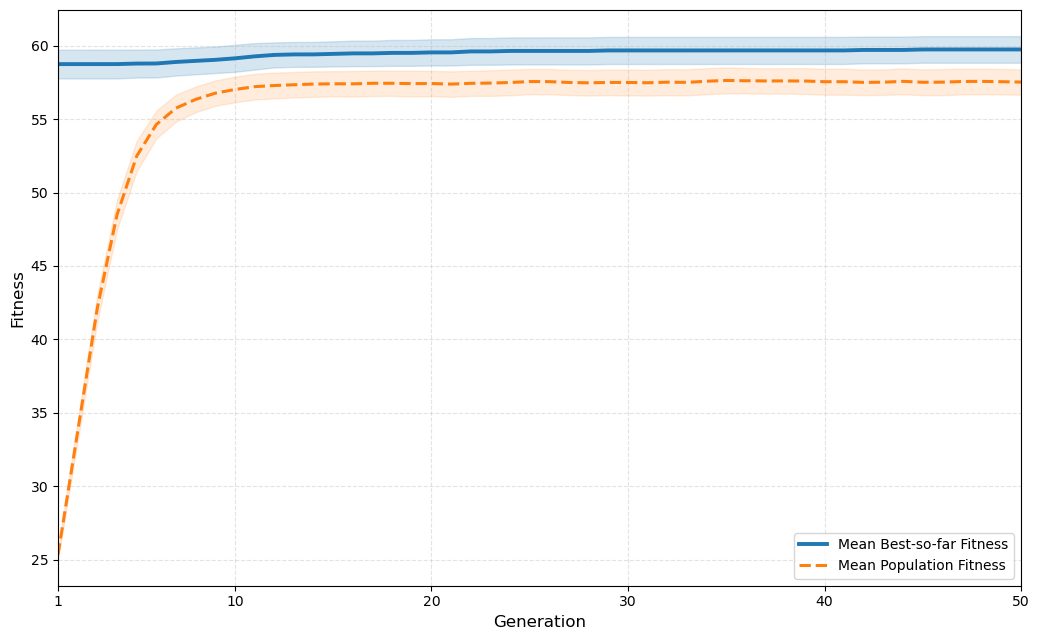

30-Run Convergence Analysis
Workload: 80 flows
Runs: 30
Initial mean best fitness: 58.7418
Final mean best fitness: 59.7390
Initial mean population fitness: 25.3643
Final mean population fitness: 57.5180
Final best-fitness 95% CI: [58.8345, 60.6435]
Final population-fitness 95% CI: [56.6603, 58.3756]


In [ ]:
# ==========================================================
#  GA CONVERGENCE WITH 95% CONFIDENCE INTERVAL
# ==========================================================

import random
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Configuration
# ----------------------------------------------------------

CONVERGENCE_FLOW_SIZE = 80
CONVERGENCE_RUNS = 30
CONVERGENCE_BASE_SEED = 15000

all_best_histories = []
all_avg_histories = []

# ----------------------------------------------------------
# Run 30 independent convergence experiments
# ----------------------------------------------------------

for run in range(CONVERGENCE_RUNS):

    run_seed = (
        CONVERGENCE_BASE_SEED
        + CONVERGENCE_FLOW_SIZE * 100
        + run
    )

    random.seed(run_seed)

    networks, flows = generate_scenario(
        num_flows=CONVERGENCE_FLOW_SIZE,
        hC=0.8
    )

    (
        best_solution,
        best_result,
        best_history,
        avg_history
    ) = run_ga(
        flows,
        networks,
        population_size=FINAL_POPULATION_SIZE,
        generations=FINAL_GENERATIONS,
        mutation_rate=FINAL_MUTATION_RATE,
        tournament_size=FINAL_TOURNAMENT_SIZE,
        local_search_passes=FINAL_LOCAL_SEARCH_PASSES
    )

    if len(best_history) != FINAL_GENERATIONS:
        raise ValueError(
            f"Run {run + 1}: incorrect best-history length."
        )

    if len(avg_history) != FINAL_GENERATIONS:
        raise ValueError(
            f"Run {run + 1}: incorrect average-history length."
        )

    all_best_histories.append(best_history)
    all_avg_histories.append(avg_history)

    print(
        f"Convergence run "
        f"{run + 1}/{CONVERGENCE_RUNS} completed"
    )

# ----------------------------------------------------------
# Convert to NumPy arrays
# ----------------------------------------------------------

best_array = np.asarray(
    all_best_histories,
    dtype=float
)

avg_array = np.asarray(
    all_avg_histories,
    dtype=float
)

# ----------------------------------------------------------
# Mean convergence histories
# ----------------------------------------------------------

mean_best = np.mean(
    best_array,
    axis=0
)

mean_avg = np.mean(
    avg_array,
    axis=0
)

# ----------------------------------------------------------
# 95% confidence intervals
# CI = mean ± 1.96 * standard error
# ----------------------------------------------------------

best_se = (
    np.std(
        best_array,
        axis=0,
        ddof=1
    )
    / np.sqrt(CONVERGENCE_RUNS)
)

avg_se = (
    np.std(
        avg_array,
        axis=0,
        ddof=1
    )
    / np.sqrt(CONVERGENCE_RUNS)
)

best_ci = 1.96 * best_se
avg_ci = 1.96 * avg_se

best_lower = mean_best - best_ci
best_upper = mean_best + best_ci

avg_lower = mean_avg - avg_ci
avg_upper = mean_avg + avg_ci

generations_axis = np.arange(
    1,
    FINAL_GENERATIONS + 1
)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10.5, 6.5)
)

# Best-so-far mean
best_line = ax.plot(
    generations_axis,
    mean_best,
    linewidth=2.8,
    label="Mean Best-so-far Fitness"
)[0]

# Best-so-far 95% CI
ax.fill_between(
    generations_axis,
    best_lower,
    best_upper,
    alpha=0.18,
    color=best_line.get_color()
)

# Population mean
avg_line = ax.plot(
    generations_axis,
    mean_avg,
    linewidth=2.2,
    linestyle="--",
    label="Mean Population Fitness"
)[0]

# Population mean 95% CI
ax.fill_between(
    generations_axis,
    avg_lower,
    avg_upper,
    alpha=0.14,
    color=avg_line.get_color()
)

# ----------------------------------------------------------
# Labels and formatting
# ----------------------------------------------------------

ax.set_xlabel(
    "Generation",
    fontsize=12
)

ax.set_ylabel(
    "Fitness",
    fontsize=12
)

ax.set_xlim(
    1,
    FINAL_GENERATIONS
)

ax.set_xticks(
    [1, 10, 20, 30, 40, 50]
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.35
)

ax.legend(
    fontsize=10,
    loc="lower right"
)

plt.tight_layout()

# ----------------------------------------------------------
# Save dissertation-quality versions
# ----------------------------------------------------------

plt.savefig(
    "Figure_5_5_GA_Convergence_95CI.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_5_5_GA_Convergence_95CI.pdf",
    bbox_inches="tight"
)

plt.show()

# ----------------------------------------------------------
# Numerical summary
# ----------------------------------------------------------

print("=" * 65)
print("30-Run Convergence Analysis")
print("=" * 65)

print(
    f"Workload: "
    f"{CONVERGENCE_FLOW_SIZE} flows"
)

print(
    f"Runs: "
    f"{CONVERGENCE_RUNS}"
)

print(
    f"Initial mean best fitness: "
    f"{mean_best[0]:.4f}"
)

print(
    f"Final mean best fitness: "
    f"{mean_best[-1]:.4f}"
)

print(
    f"Initial mean population fitness: "
    f"{mean_avg[0]:.4f}"
)

print(
    f"Final mean population fitness: "
    f"{mean_avg[-1]:.4f}"
)

print(
    f"Final best-fitness 95% CI: "
    f"[{best_lower[-1]:.4f}, "
    f"{best_upper[-1]:.4f}]"
)

print(
    f"Final population-fitness 95% CI: "
    f"[{avg_lower[-1]:.4f}, "
    f"{avg_upper[-1]:.4f}]"
)

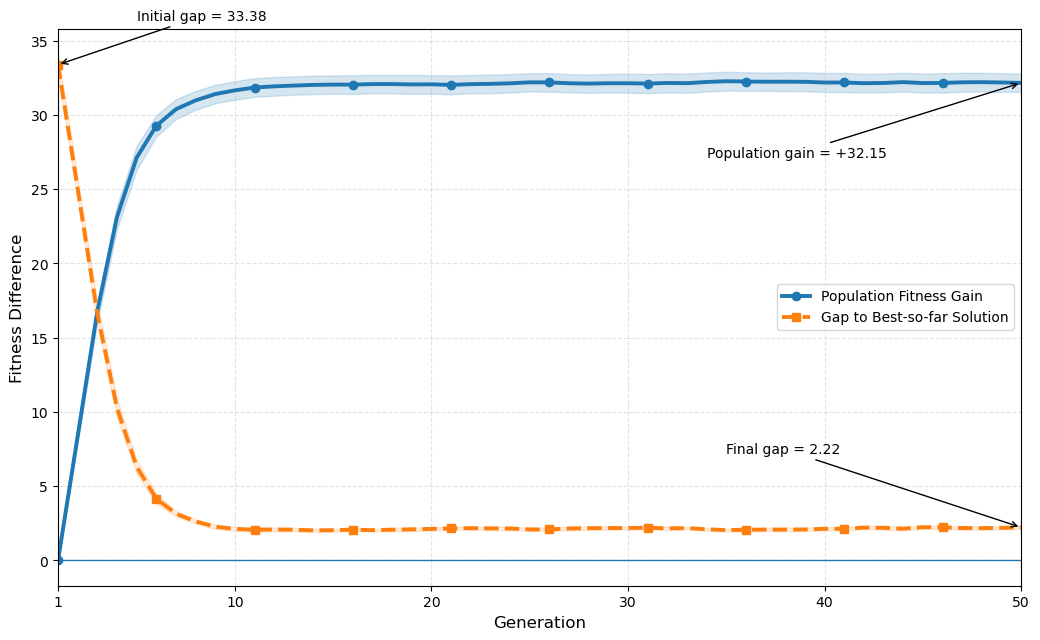

Seeded GA Convergence-Gain Analysis
Initial population-to-best gap: 33.3775
Final population-to-best gap: 2.2210
Gap reduction: 93.35%
Final population fitness gain: +32.1537
Runs analysed: 30


In [ ]:
# ==========================================================
#  
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Use the 30-run histories already generated previously
# ----------------------------------------------------------

best_array = np.asarray(all_best_histories, dtype=float)
avg_array  = np.asarray(all_avg_histories, dtype=float)

n_runs = best_array.shape[0]
n_generations = best_array.shape[1]

generations_axis = np.arange(1, n_generations + 1)

# ----------------------------------------------------------
# 1. Population fitness improvement relative to Generation 1
# ----------------------------------------------------------

population_gain = (
    avg_array
    - avg_array[:, [0]]
)

mean_population_gain = np.mean(
    population_gain,
    axis=0
)

population_gain_se = (
    np.std(
        population_gain,
        axis=0,
        ddof=1
    )
    / np.sqrt(n_runs)
)

population_gain_ci = (
    1.96 * population_gain_se
)

population_gain_lower = (
    mean_population_gain
    - population_gain_ci
)

population_gain_upper = (
    mean_population_gain
    + population_gain_ci
)

# ----------------------------------------------------------
# 2. Gap between best-so-far and population mean
# ----------------------------------------------------------

fitness_gap = (
    best_array
    - avg_array
)

mean_gap = np.mean(
    fitness_gap,
    axis=0
)

gap_se = (
    np.std(
        fitness_gap,
        axis=0,
        ddof=1
    )
    / np.sqrt(n_runs)
)

gap_ci = 1.96 * gap_se

gap_lower = mean_gap - gap_ci
gap_upper = mean_gap + gap_ci

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10.5, 6.5)
)

# Population improvement
gain_line = ax.plot(
    generations_axis,
    mean_population_gain,
    linewidth=2.8,
    marker="o",
    markevery=5,
    label="Population Fitness Gain"
)[0]

ax.fill_between(
    generations_axis,
    population_gain_lower,
    population_gain_upper,
    alpha=0.18,
    color=gain_line.get_color()
)

# Remaining fitness gap
gap_line = ax.plot(
    generations_axis,
    mean_gap,
    linewidth=2.8,
    linestyle="--",
    marker="s",
    markevery=5,
    label="Gap to Best-so-far Solution"
)[0]

ax.fill_between(
    generations_axis,
    gap_lower,
    gap_upper,
    alpha=0.15,
    color=gap_line.get_color()
)

# ----------------------------------------------------------
# Important annotations
# ----------------------------------------------------------

initial_gap = mean_gap[0]
final_gap = mean_gap[-1]
final_gain = mean_population_gain[-1]

ax.annotate(
    f"Initial gap = {initial_gap:.2f}",
    xy=(1, initial_gap),
    xytext=(5, initial_gap + 3),
    arrowprops=dict(
        arrowstyle="->"
    ),
    fontsize=10
)

ax.annotate(
    f"Population gain = +{final_gain:.2f}",
    xy=(
        n_generations,
        final_gain
    ),
    xytext=(
        n_generations - 16,
        final_gain - 5
    ),
    arrowprops=dict(
        arrowstyle="->"
    ),
    fontsize=10
)

ax.annotate(
    f"Final gap = {final_gap:.2f}",
    xy=(
        n_generations,
        final_gap
    ),
    xytext=(
        n_generations - 15,
        final_gap + 5
    ),
    arrowprops=dict(
        arrowstyle="->"
    ),
    fontsize=10
)

# ----------------------------------------------------------
# Formatting
# ----------------------------------------------------------

ax.set_xlabel(
    "Generation",
    fontsize=12
)

ax.set_ylabel(
    "Fitness Difference",
    fontsize=12
)

ax.set_xlim(
    1,
    n_generations
)

ax.set_xticks(
    [1, 10, 20, 30, 40, 50]
)

ax.axhline(
    0,
    linewidth=1
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.35
)

ax.legend(
    fontsize=10,
    loc="center right"
)

plt.tight_layout()

# ----------------------------------------------------------
# Save
# ----------------------------------------------------------

plt.savefig(
    "Figure_5_5_Seeded_GA_Convergence_Gain.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_5_5_Seeded_GA_Convergence_Gain.pdf",
    bbox_inches="tight"
)

plt.show()

# ----------------------------------------------------------
# Numerical interpretation
# ----------------------------------------------------------

gap_reduction = (
    (
        initial_gap - final_gap
    )
    / initial_gap
) * 100

print("=" * 70)
print("Seeded GA Convergence-Gain Analysis")
print("=" * 70)

print(
    f"Initial population-to-best gap: "
    f"{initial_gap:.4f}"
)

print(
    f"Final population-to-best gap: "
    f"{final_gap:.4f}"
)

print(
    f"Gap reduction: "
    f"{gap_reduction:.2f}%"
)

print(
    f"Final population fitness gain: "
    f"+{final_gain:.4f}"
)

print(
    f"Runs analysed: {n_runs}"
)

In [ ]:
# ==========================================================
# RANDOM INITIAL POPULATION
# ==========================================================

def create_random_initial_population(
    flows,
    networks,
    population_size=30
):
    """
    Create a fully random GA initial population.

    No FF, BF, CABF, or CABFinv heuristic solutions
    are inserted.

    Each gene may be:
        (network, supported QoS level)
        or
        (None, None)

    Feasibility is restored afterward by the same
    repair procedure used by the Seeded GA.
    """

    population = []

    network_names = list(networks.keys())

    for _ in range(population_size):

        chromosome = {}

        for flow, levels in flows.items():

            # Supported states for this flow
            possible_states = [
                (network, level)
                for network in network_names
                for level in levels.keys()
            ]

            # Include unallocated state
            possible_states.append(
                (None, None)
            )

            chromosome[flow] = random.choice(
                possible_states
            )

        population.append(chromosome)

    return population

In [ ]:
# ==========================================================
# RANDOMLY INITIALISED GA
# Same GA mechanism as run_ga()
# Only the initial population is random
# ==========================================================

import random


def create_random_initial_population(
    flows,
    networks,
    population_size=30
):
    """
    Create a fully random initial population.

    No FF, BF, CABF, or CABFinv heuristic solutions
    are inserted.

    Each flow is assigned either:
        (network, supported QoS level)
    or:
        (None, None)

    Feasibility is restored afterward using repair_solution().
    """

    population = []
    network_names = list(networks.keys())

    for _ in range(population_size):

        chromosome = {}

        for flow, levels in flows.items():

            possible_states = [
                (network, level)
                for network in network_names
                for level in levels.keys()
            ]

            # Allow a flow to remain unallocated
            possible_states.append(
                (None, None)
            )

            chromosome[flow] = random.choice(
                possible_states
            )

        population.append(
            chromosome
        )

    return population


def run_ga_random_initialisation(
    flows,
    networks,
    population_size=30,
    generations=50,
    mutation_rate=0.05,
    tournament_size=3,
    local_search_passes=5,
    show_progress=False
):
    """
    Run the same Genetic Algorithm as run_ga(),
    but with a fully random initial population.

    The evolutionary operators, repair procedure,
    local improvement, elitism, fitness evaluation,
    and stopping criterion remain unchanged.
    """

    # ------------------------------------------------------
    # Parameter validation
    # ------------------------------------------------------

    if population_size < 1:
        raise ValueError(
            "population_size must be at least 1."
        )

    if generations < 1:
        raise ValueError(
            "generations must be at least 1."
        )

    if not 0 <= mutation_rate <= 1:
        raise ValueError(
            "mutation_rate must be between 0 and 1."
        )

    if tournament_size < 1:
        raise ValueError(
            "tournament_size must be at least 1."
        )

    if tournament_size > population_size:
        raise ValueError(
            "tournament_size cannot exceed population_size."
        )

    if local_search_passes < 0:
        raise ValueError(
            "local_search_passes cannot be negative."
        )

    # ------------------------------------------------------
    # RANDOM INITIAL POPULATION
    # 
    # ------------------------------------------------------

    population = create_random_initial_population(
        flows,
        networks,
        population_size=population_size
    )

    # Restore feasibility using the same repair mechanism
    population = [
        repair_solution(
            chromosome,
            flows,
            networks
        )
        for chromosome in population
    ]

    # ------------------------------------------------------
    # Initial global best
    # ------------------------------------------------------

    best_solution = None
    best_fitness = float("-inf")

    best_fitness_history = []
    avg_fitness_history = []

    # ------------------------------------------------------
    # Main evolutionary loop
    # ------------------------------------------------------

    for generation in range(generations):

        if show_progress and (
            generation == 0
            or (generation + 1) % 10 == 0
            or generation + 1 == generations
        ):
            print(
                f"Generation {generation + 1}/{generations}",
                flush=True
            )

        evaluated_population = []

        # --------------------------------------------------
        # Evaluate population
        # --------------------------------------------------

        for chromosome in population:

            result = evaluate_solution(
                chromosome,
                flows,
                networks
            )

            fitness = result["Fitness"]

            evaluated_population.append(
                (
                    chromosome,
                    fitness
                )
            )

        # Sort best to worst
        evaluated_population.sort(
            key=lambda item: item[1],
            reverse=True
        )

        # --------------------------------------------------
        # Generation statistics
        # --------------------------------------------------

        generation_best_solution = (
            evaluated_population[0][0].copy()
        )

        generation_best_fitness = (
            evaluated_population[0][1]
        )

        generation_avg_fitness = (
            sum(
                fitness
                for _, fitness
                in evaluated_population
            )
            / len(evaluated_population)
        )

        # --------------------------------------------------
        # Update global best
        # --------------------------------------------------

        if generation_best_fitness > best_fitness:

            best_solution = (
                generation_best_solution.copy()
            )

            best_fitness = (
                generation_best_fitness
            )

        best_fitness_history.append(
            best_fitness
        )

        avg_fitness_history.append(
            generation_avg_fitness
        )

        # --------------------------------------------------
        # Elitism
        # --------------------------------------------------

        new_population = [
            generation_best_solution.copy()
        ]

        current_population = [
            chromosome
            for chromosome, _
            in evaluated_population
        ]

        # --------------------------------------------------
        # Generate offspring
        # --------------------------------------------------

        while len(new_population) < population_size:

            parent1 = tournament_selection(
                current_population,
                flows,
                networks,
                tournament_size=tournament_size
            )

            parent2 = tournament_selection(
                current_population,
                flows,
                networks,
                tournament_size=tournament_size
            )

            child = crossover(
                parent1,
                parent2,
                flows
            )

            child = mutate(
                child,
                flows,
                networks,
                mutation_rate=mutation_rate
            )

            # ----------------------------------------------
            # Repair
            # ----------------------------------------------

            child = repair_solution(
                child,
                flows,
                networks
            )

            # ----------------------------------------------
            # Correct local improvement function
            # ----------------------------------------------

            if local_search_passes > 0:

                child = improve_solution(
                    child,
                    flows,
                    networks,
                    max_passes=local_search_passes
                )

            # ----------------------------------------------
            # Defensive feasibility check
            # ----------------------------------------------

            child_result = evaluate_solution(
                child,
                flows,
                networks
            )

            if child_result["CapacityViolation"] != 0:
                raise RuntimeError(
                    "An infeasible offspring remained "
                    "after repair and local improvement."
                )

            new_population.append(
                child
            )

        population = new_population

    # ------------------------------------------------------
    # Final best evaluation
    # ------------------------------------------------------

    best_result = evaluate_solution(
        best_solution,
        flows,
        networks
    )

    if best_result["CapacityViolation"] != 0:
        raise RuntimeError(
            "Randomly initialised GA returned "
            "an infeasible final solution."
        )

    return (
        best_solution,
        best_result,
        best_fitness_history,
        avg_fitness_history
    )


# ==========================================================
# Verification
# ==========================================================

print(
    "run_ga_random_initialisation defined successfully."
)

print(
    "Random population function available:",
    callable(create_random_initial_population)
)

print(
    "Random GA function available:",
    callable(run_ga_random_initialisation)
)

print(
    "Local improvement function available:",
    callable(improve_solution)
)

run_ga_random_initialisation defined successfully.
Random population function available: True
Random GA function available: True
Local improvement function available: True


In [ ]:
# ==========================================================
# 30-RUN PAIRED SEEDING EXPERIMENT
# Proposed Seeded GA vs Randomly Initialised GA
# ==========================================================

import random
import time
import numpy as np
import pandas as pd


# ----------------------------------------------------------
# Experimental configuration
# ----------------------------------------------------------

N_RUNS = 30
N_FLOWS = 80
BASE_SEED = 25000

seeding_results = []


# ----------------------------------------------------------
# Run paired experiments
# ----------------------------------------------------------

for run in range(N_RUNS):

    scenario_seed = BASE_SEED + run
    ga_seed = BASE_SEED + 100000 + run

    # ------------------------------------------------------
    # Generate ONE scenario shared by both GA variants
    # ------------------------------------------------------

    random.seed(scenario_seed)

    networks, flows = generate_scenario(
        num_flows=N_FLOWS,
        hC=0.8
    )

    # ======================================================
    # 1. PROPOSED SEEDED GA
    # ======================================================

    random.seed(ga_seed)

    start = time.perf_counter()

    (
        seeded_solution,
        seeded_result,
        seeded_best_history,
        seeded_avg_history
    ) = run_ga(
        flows,
        networks,
        population_size=FINAL_POPULATION_SIZE,
        generations=FINAL_GENERATIONS,
        mutation_rate=FINAL_MUTATION_RATE,
        tournament_size=FINAL_TOURNAMENT_SIZE,
        local_search_passes=FINAL_LOCAL_SEARCH_PASSES
    )

    seeded_time = time.perf_counter() - start


    # ======================================================
    # 2. RANDOMLY INITIALISED GA
    # ======================================================

    random.seed(ga_seed)

    start = time.perf_counter()

    (
        random_solution,
        random_result,
        random_best_history,
        random_avg_history
    ) = run_ga_random_initialisation(
        flows,
        networks,
        population_size=FINAL_POPULATION_SIZE,
        generations=FINAL_GENERATIONS,
        mutation_rate=FINAL_MUTATION_RATE,
        tournament_size=FINAL_TOURNAMENT_SIZE,
        local_search_passes=FINAL_LOCAL_SEARCH_PASSES
    )

    random_time = time.perf_counter() - start


    # ======================================================
    # Feasibility verification
    # ======================================================

    if seeded_result["CapacityViolation"] != 0:
        raise RuntimeError(
            f"Seeded GA produced an infeasible solution "
            f"in run {run + 1}."
        )

    if random_result["CapacityViolation"] != 0:
        raise RuntimeError(
            f"Random GA produced an infeasible solution "
            f"in run {run + 1}."
        )


    # ======================================================
    # Record Seeded GA
    # ======================================================

    seeding_results.append({
        "Run": run + 1,
        "Algorithm": "Proposed Seeded GA",
        "Fitness": seeded_result["Fitness"],
        "Allocated_Flows": seeded_result["AllocatedFlows"],
        "Criticality_Quality":
            seeded_result["CriticalityQuality"],
        "Service_Percentage": seeded_result["servP"],
        "Capacity_Violation":
            seeded_result["CapacityViolation"],
        "Execution_Time_s": seeded_time
    })


    # ======================================================
    # Record Random GA
    # ======================================================

    seeding_results.append({
        "Run": run + 1,
        "Algorithm": "Randomly Initialised GA",
        "Fitness": random_result["Fitness"],
        "Allocated_Flows": random_result["AllocatedFlows"],
        "Criticality_Quality":
            random_result["CriticalityQuality"],
        "Service_Percentage": random_result["servP"],
        "Capacity_Violation":
            random_result["CapacityViolation"],
        "Execution_Time_s": random_time
    })


    # ======================================================
    # Save checkpoint after EVERY completed pair
    # ======================================================

    checkpoint_df = pd.DataFrame(seeding_results)

    checkpoint_df.to_csv(
        "Seeding_Comparison_Checkpoint.csv",
        index=False
    )



    print(
        f"Run {run + 1:02d}/{N_RUNS} completed | "
        f"Seeded={seeded_result['Fitness']:.4f} | "
        f"Random={random_result['Fitness']:.4f} | "
        f"Seeded time={seeded_time:.2f}s | "
        f"Random time={random_time:.2f}s"
    )


# ==========================================================
# Final raw results
# ==========================================================

seeding_comparison_df = pd.DataFrame(
    seeding_results
)


# ==========================================================
# Summary statistics
# ==========================================================

seeding_summary_df = (
    seeding_comparison_df
    .groupby("Algorithm")
    .agg(
        Mean_Fitness=(
            "Fitness",
            "mean"
        ),

        SD_Fitness=(
            "Fitness",
            "std"
        ),

        Median_Fitness=(
            "Fitness",
            "median"
        ),

        Mean_Allocated_Flows=(
            "Allocated_Flows",
            "mean"
        ),

        SD_Allocated_Flows=(
            "Allocated_Flows",
            "std"
        ),

        Mean_Criticality_Quality=(
            "Criticality_Quality",
            "mean"
        ),

        SD_Criticality_Quality=(
            "Criticality_Quality",
            "std"
        ),

        Mean_Service_Percentage=(
            "Service_Percentage",
            "mean"
        ),

        SD_Service_Percentage=(
            "Service_Percentage",
            "std"
        ),

        Mean_Execution_Time_s=(
            "Execution_Time_s",
            "mean"
        ),

        SD_Execution_Time_s=(
            "Execution_Time_s",
            "std"
        )
    )
    .reset_index()
)


# ==========================================================
# Display summary
# ==========================================================

print("\n" + "=" * 75)
print("30-RUN SEEDED VS RANDOM GA COMPARISON")
print("=" * 75)

display(seeding_summary_df)


# ==========================================================
# Paired fitness comparison
# ==========================================================

seeded_values = (
    seeding_comparison_df[
        seeding_comparison_df["Algorithm"]
        == "Proposed Seeded GA"
    ]
    .sort_values("Run")["Fitness"]
    .to_numpy()
)

random_values = (
    seeding_comparison_df[
        seeding_comparison_df["Algorithm"]
        == "Randomly Initialised GA"
    ]
    .sort_values("Run")["Fitness"]
    .to_numpy()
)

fitness_difference = (
    seeded_values - random_values
)


# ==========================================================
# Paired result counts
# ==========================================================

seeded_wins = int(
    np.sum(fitness_difference > 0)
)

ties = int(
    np.sum(np.isclose(
        fitness_difference,
        0
    ))
)

random_wins = int(
    np.sum(fitness_difference < 0)
)


print("\nPaired Fitness Comparison")
print("-" * 50)

print(
    f"Mean Seeded - Random difference: "
    f"{np.mean(fitness_difference):.4f}"
)

print(
    f"Median Seeded - Random difference: "
    f"{np.median(fitness_difference):.4f}"
)

print(
    f"Seeded GA better: "
    f"{seeded_wins}/{N_RUNS} runs"
)

print(
    f"Equal: "
    f"{ties}/{N_RUNS} runs"
)

print(
    f"Random GA better: "
    f"{random_wins}/{N_RUNS} runs"
)


# ==========================================================
# Save final datasets
# ==========================================================

seeding_comparison_df.to_csv(
    "Seeding_Comparison_Raw.csv",
    index=False
)

seeding_summary_df.to_csv(
    "Seeding_Comparison_Summary.csv",
    index=False
)

print("\nResults saved successfully:")
print("Seeding_Comparison_Checkpoint.csv")
print("Seeding_Comparison_Raw.csv")
print("Seeding_Comparison_Summary.csv")

Run 01/30 completed | Seeded=63.3862 | Random=62.4032 | Seeded time=28.64s | Random time=30.75s
Run 02/30 completed | Seeded=59.3898 | Random=59.3898 | Seeded time=26.26s | Random time=29.14s
Run 03/30 completed | Seeded=55.4121 | Random=55.4121 | Seeded time=24.11s | Random time=27.27s
Run 04/30 completed | Seeded=58.4080 | Random=58.4080 | Seeded time=26.80s | Random time=29.74s
Run 05/30 completed | Seeded=57.4152 | Random=57.4094 | Seeded time=24.46s | Random time=27.83s
Run 06/30 completed | Seeded=59.4011 | Random=59.4011 | Seeded time=26.34s | Random time=29.58s
Run 07/30 completed | Seeded=55.4182 | Random=55.4182 | Seeded time=23.75s | Random time=27.14s
Run 08/30 completed | Seeded=56.3988 | Random=55.4242 | Seeded time=24.81s | Random time=28.44s
Run 09/30 completed | Seeded=61.3934 | Random=61.3934 | Seeded time=27.16s | Random time=29.92s
Run 10/30 completed | Seeded=57.4152 | Random=57.4152 | Seeded time=24.49s | Random time=28.08s
Run 11/30 completed | Seeded=61.4098 | R

,Algorithm,Mean_Fitness,SD_Fitness,Median_Fitness,Mean_Allocated_Flows,SD_Allocated_Flows,Mean_Criticality_Quality,SD_Criticality_Quality,Mean_Service_Percentage,SD_Service_Percentage,Mean_Execution_Time_s,SD_Execution_Time_s
0,Proposed Seeded GA,58.939848,3.004571,59.389831,58.533333,3.014143,0.406515,0.017108,0.731667,0.037677,25.706224,1.743506
1,Randomly Initialised GA,58.676487,2.891580,58.910481,58.266667,2.899861,0.409821,0.017337,0.728333,0.036248,28.728463,1.404404



Paired Fitness Comparison
--------------------------------------------------
Mean Seeded - Random difference: 0.2634
Median Seeded - Random difference: 0.0028
Seeded GA better: 15/30 runs
Equal: 14/30 runs
Random GA better: 1/30 runs

Results saved successfully:
Seeding_Comparison_Checkpoint.csv
Seeding_Comparison_Raw.csv
Seeding_Comparison_Summary.csv


Rows loaded: 60
Algorithms: ['Proposed Seeded GA' 'Randomly Initialised GA']


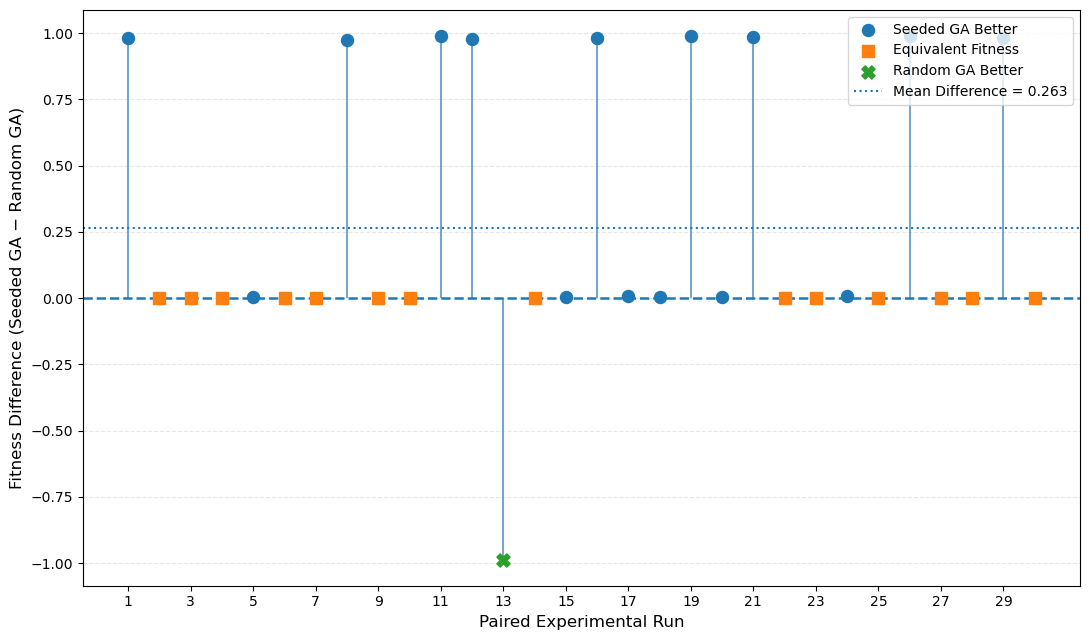


FIGURE 5.7 — PAIRED SEEDING ANALYSIS
Paired runs: 30
Mean paired fitness difference: 0.2634
Median paired fitness difference: 0.0028
Seeded GA better: 15/30
Equivalent fitness: 14/30
Random GA better: 1/30

Seeded GA mean runtime: 25.7062 s
Random GA mean runtime: 28.7285 s
Seeded GA runtime reduction: 10.52%


In [ ]:
# ==========================================================
# FIGURE 5.7
# Paired Fitness Difference:
# Proposed Seeded GA vs Randomly Initialised GA
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ----------------------------------------------------------
# 1. Load actual 30-run experimental results
# ----------------------------------------------------------

df = pd.read_csv("Seeding_Comparison_Raw.csv")

print("Rows loaded:", len(df))
print("Algorithms:", df["Algorithm"].unique())


# ----------------------------------------------------------
# 2. Extract paired fitness values
# ----------------------------------------------------------

seeded = (
    df[df["Algorithm"] == "Proposed Seeded GA"]
    .sort_values("Run")
    .set_index("Run")["Fitness"]
)

random_ga = (
    df[df["Algorithm"] == "Randomly Initialised GA"]
    .sort_values("Run")
    .set_index("Run")["Fitness"]
)


# Ensure exact paired runs
common_runs = seeded.index.intersection(
    random_ga.index
)

seeded = seeded.loc[common_runs]
random_ga = random_ga.loc[common_runs]

if len(common_runs) != 30:
    raise ValueError(
        f"Expected 30 paired runs, found {len(common_runs)}."
    )


# 
# ----------------------------------------------------------

difference = seeded - random_ga

runs = common_runs.to_numpy()
difference_values = difference.to_numpy()


# ----------------------------------------------------------
# 4. Classification
# ----------------------------------------------------------

TOLERANCE = 1e-9

seeded_better = difference_values > TOLERANCE
random_better = difference_values < -TOLERANCE
equal = np.isclose(
    difference_values,
    0.0,
    atol=TOLERANCE
)


# ----------------------------------------------------------
# 5. Plot
# ----------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 6.5)
)

# Vertical stems from zero
ax.vlines(
    runs,
    0,
    difference_values,
    linewidth=1.4,
    alpha=0.65
)

# Seeded wins
ax.scatter(
    runs[seeded_better],
    difference_values[seeded_better],
    s=75,
    marker="o",
    label="Seeded GA Better",
    zorder=3
)

# Equivalent final fitness
ax.scatter(
    runs[equal],
    difference_values[equal],
    s=70,
    marker="s",
    label="Equivalent Fitness",
    zorder=4
)

# Random GA wins
ax.scatter(
    runs[random_better],
    difference_values[random_better],
    s=90,
    marker="X",
    label="Random GA Better",
    zorder=5
)


# ----------------------------------------------------------
# 6. Zero reference line
# ----------------------------------------------------------

ax.axhline(
    0,
    linewidth=1.8,
    linestyle="--"
)


# ----------------------------------------------------------
# 7. Mean paired difference
# ----------------------------------------------------------

mean_difference = np.mean(
    difference_values
)

ax.axhline(
    mean_difference,
    linewidth=1.5,
    linestyle=":",
    label=(
        f"Mean Difference = "
        f"{mean_difference:.3f}"
    )
)


# ----------------------------------------------------------
# 8. Labels and formatting
# ----------------------------------------------------------

ax.set_xlabel(
    "Paired Experimental Run",
    fontsize=12
)

ax.set_ylabel(
    "Fitness Difference (Seeded GA − Random GA)",
    fontsize=12
)

ax.set_xticks(
    np.arange(1, 31, 2)
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)

ax.legend(
    loc="upper right",
    fontsize=10
)

plt.tight_layout()


# ----------------------------------------------------------
# 9. Save dissertation-quality figure
# ----------------------------------------------------------

plt.savefig(
    "Figure_5_7_Paired_Seeding_Fitness_Difference.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_5_7_Paired_Seeding_Fitness_Difference.pdf",
    bbox_inches="tight"
)

plt.show()


# ----------------------------------------------------------
# 10. Verification output
# ----------------------------------------------------------

print("\n" + "=" * 65)
print("FIGURE 5.7 — PAIRED SEEDING ANALYSIS")
print("=" * 65)

print(
    f"Paired runs: {len(common_runs)}"
)

print(
    f"Mean paired fitness difference: "
    f"{mean_difference:.4f}"
)

print(
    f"Median paired fitness difference: "
    f"{np.median(difference_values):.4f}"
)

print(
    f"Seeded GA better: "
    f"{np.sum(seeded_better)}/30"
)

print(
    f"Equivalent fitness: "
    f"{np.sum(equal)}/30"
)

print(
    f"Random GA better: "
    f"{np.sum(random_better)}/30"
)


# ----------------------------------------------------------
# 11. Execution-time comparison
# ----------------------------------------------------------

seeded_time = (
    df[df["Algorithm"] == "Proposed Seeded GA"]
    ["Execution_Time_s"]
    .mean()
)

random_time = (
    df[df["Algorithm"] == "Randomly Initialised GA"]
    ["Execution_Time_s"]
    .mean()
)

runtime_reduction = (
    (random_time - seeded_time)
    / random_time
) * 100

print(
    f"\nSeeded GA mean runtime: "
    f"{seeded_time:.4f} s"
)

print(
    f"Random GA mean runtime: "
    f"{random_time:.4f} s"
)

print(
    f"Seeded GA runtime reduction: "
    f"{runtime_reduction:.2f}%"
)

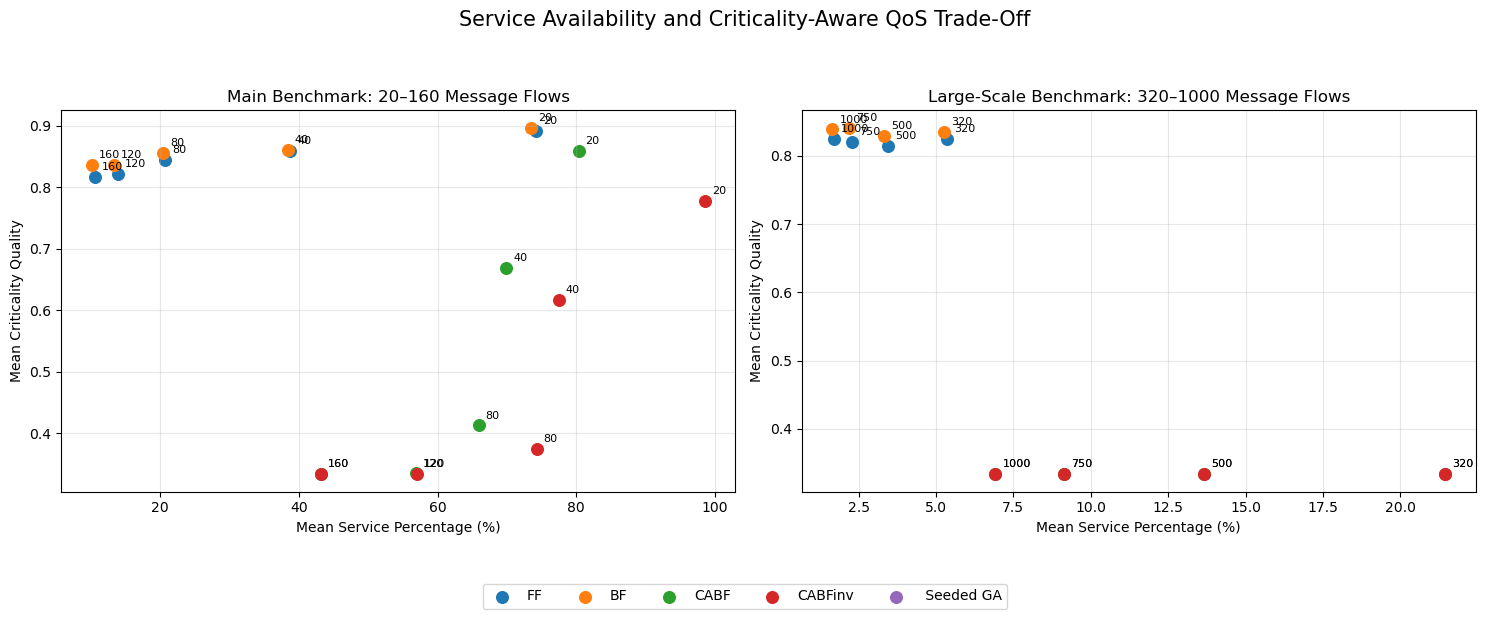

In [ ]:
# ============================================================
# 
# Service Availability vs Criticality-Aware QoS Trade-Off
# 
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Extract final experimental results
# ------------------------------------------------------------

main_plot = benchmark_summary_df[
    benchmark_summary_df["Flows"].isin([20, 40, 80, 120, 160])
].copy()

large_plot = large_benchmark_summary_df[
    large_benchmark_summary_df["Flows"].isin([320, 500, 750, 1000])
].copy()

algorithms = [
    "FF",
    "BF",
    "CABF",
    "CABFinv",
    " Seeded GA"
]

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

# ============================================================
# MAIN BENCHMARK
# ============================================================

ax = axes[0]

for algorithm in algorithms:

    temp = (
        main_plot[
            main_plot["Algorithm"] == algorithm
        ]
        .sort_values("Flows")
    )

    ax.scatter(
        temp["Mean_servP"] * 100,
        temp["Mean_Criticality_Quality"],
        s=70,
        label=algorithm
    )

    for _, row in temp.iterrows():

        ax.annotate(
            str(int(row["Flows"])),
            (
                row["Mean_servP"] * 100,
                row["Mean_Criticality_Quality"]
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8
        )

ax.set_title(
    "Main Benchmark: 20–160 Message Flows"
)

ax.set_xlabel(
    "Mean Service Percentage (%)"
)

ax.set_ylabel(
    "Mean Criticality Quality"
)

ax.grid(
    True,
    alpha=0.3
)

# ============================================================
# LARGE-SCALE BENCHMARK
# ============================================================

ax = axes[1]

for algorithm in algorithms:

    temp = (
        large_plot[
            large_plot["Algorithm"] == algorithm
        ]
        .sort_values("Flows")
    )

    ax.scatter(
        temp["Mean_servP"] * 100,
        temp["Mean_Criticality_Quality"],
        s=70,
        label=algorithm
    )

    for _, row in temp.iterrows():

        ax.annotate(
            str(int(row["Flows"])),
            (
                row["Mean_servP"] * 100,
                row["Mean_Criticality_Quality"]
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8
        )

ax.set_title(
    "Large-Scale Benchmark: 320–1000 Message Flows"
)

ax.set_xlabel(
    "Mean Service Percentage (%)"
)

ax.set_ylabel(
    "Mean Criticality Quality"
)

ax.grid(
    True,
    alpha=0.3
)

# ============================================================
# COMMON LEGEND
# ============================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=5,
    bbox_to_anchor=(0.5, -0.03),
    frameon=True
)

# ------------------------------------------------------------
# Main title
# ------------------------------------------------------------

fig.suptitle(
    "Service Availability and Criticality-Aware QoS Trade-Off",
    fontsize=15,
    y=0.98
)

plt.tight_layout(
    rect=[0, 0.08, 1, 0.93]
)

plt.show()

In [ ]:
# ============================================================
#
# ============================================================

import pandas as pd

print("Available DataFrames:\n")

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print(f"{name:35s} shape = {obj.shape}")
        print("Columns:", obj.columns.tolist())
        print("-" * 80)

Available DataFrames:

df_20                               shape = (4, 8)
Columns: ['Algorithm', 'Avg servP', 'Avg avCL', 'Avg Allocated Flows', 'Avg Criticality Score', 'Avg Criticality Quality', 'Avg Fitness', 'Avg Capacity Violation']
--------------------------------------------------------------------------------
df_40                               shape = (4, 8)
Columns: ['Algorithm', 'Avg servP', 'Avg avCL', 'Avg Allocated Flows', 'Avg Criticality Score', 'Avg Criticality Quality', 'Avg Fitness', 'Avg Capacity Violation']
--------------------------------------------------------------------------------
df_80                               shape = (4, 8)
Columns: ['Algorithm', 'Avg servP', 'Avg avCL', 'Avg Allocated Flows', 'Avg Criticality Score', 'Avg Criticality Quality', 'Avg Fitness', 'Avg Capacity Violation']
--------------------------------------------------------------------------------
df_120                              shape = (4, 8)
Columns: ['Algorithm', 'Avg servP', 'A

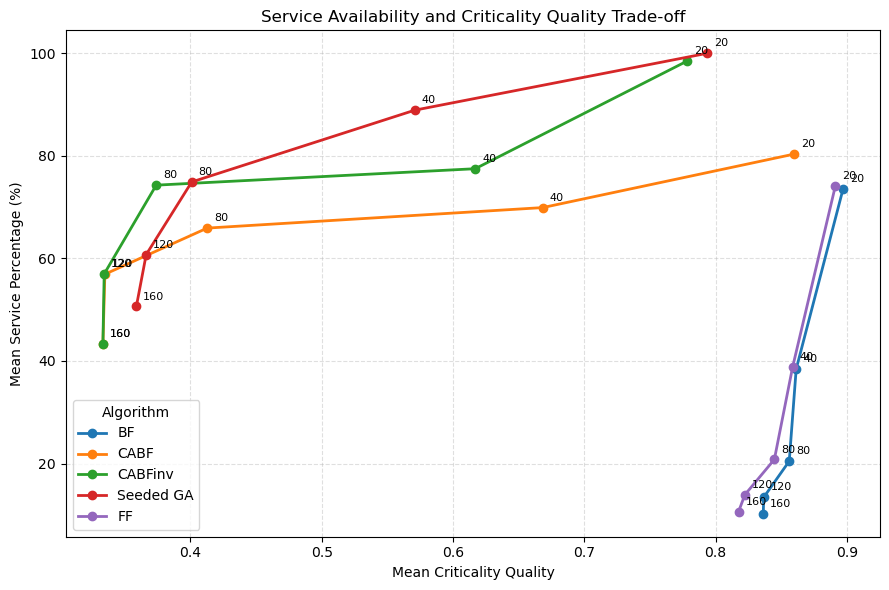

In [ ]:
import matplotlib.pyplot as plt

plot_df = benchmark_summary_df.copy()

plt.figure(figsize=(9, 6))

for algorithm in plot_df["Algorithm"].unique():

    data = plot_df[
        plot_df["Algorithm"] == algorithm
    ].sort_values("Flows")

    # Standardise the GA label only in the figure
    display_label = "Seeded GA" if "Seeded" in str(algorithm) else algorithm

    plt.plot(
        data["Mean_Criticality_Quality"],
        data["Mean_servP"] * 100,
        marker="o",
        linewidth=2,
        label=display_label
    )

    for _, row in data.iterrows():

        plt.annotate(
            str(int(row["Flows"])),
            (
                row["Mean_Criticality_Quality"],
                row["Mean_servP"] * 100
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8
        )

plt.xlabel("Mean Criticality Quality")
plt.ylabel("Mean Service Percentage (%)")
plt.title("Service Availability and Criticality Quality Trade-off")

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.legend(title="Algorithm")
plt.tight_layout()

plt.savefig(
    "Service_vs_Criticality_Quality_Tradeoff.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import numpy as np
import pandas as pd

# -------------------------------------------------
# Add Holm correction + paired Cohen's d
# to the existing wilcoxon_results_df
# -------------------------------------------------

results = wilcoxon_results_df.copy()

# Reconstruct paired differences for each row
effect_sizes = []

for _, row in results.iterrows():

    flows = row["Flows"]
    metric_name = row["Metric"]

    metric_column = {
        "Service Percentage": "servP",
        "Criticality Quality": "Criticality Quality",
        "Overall Fitness": "Fitness"
    }[metric_name]

    subset = benchmark_raw_df[
        benchmark_raw_df["Flows"] == flows
    ]

    ga = (
        subset[subset["Algorithm"] == "Enhanced Seeded GA"]
        .sort_values("Run")[metric_column]
        .to_numpy()
    )

    baseline = (
        subset[subset["Algorithm"] == "CABFinv"]
        .sort_values("Run")[metric_column]
        .to_numpy()
    )

    differences = ga - baseline

    # Paired Cohen's d = mean paired difference / SD of paired differences
    diff_sd = np.std(differences, ddof=1)

    if np.isclose(diff_sd, 0):
        cohens_d = np.nan
    else:
        cohens_d = np.mean(differences) / diff_sd

    effect_sizes.append(cohens_d)

results["Paired Cohen's d"] = effect_sizes


# -------------------------------------------------
# Holm-Bonferroni correction
# -------------------------------------------------

p_values = results["p-value"].to_numpy()
m = len(p_values)

order = np.argsort(p_values)
sorted_p = p_values[order]

holm_adjusted_sorted = np.empty(m)

for i, p in enumerate(sorted_p):
    holm_adjusted_sorted[i] = min(
        1.0,
        (m - i) * p
    )

# Enforce monotonicity
for i in range(1, m):
    holm_adjusted_sorted[i] = max(
        holm_adjusted_sorted[i],
        holm_adjusted_sorted[i - 1]
    )

holm_adjusted = np.empty(m)
holm_adjusted[order] = holm_adjusted_sorted

results["Holm-adjusted p-value"] = holm_adjusted
results["Significant after Holm (p < 0.05)"] = (
    results["Holm-adjusted p-value"] < 0.05
)

# Optional interpretation of absolute Cohen's d
def interpret_d(d):
    if pd.isna(d):
        return "Undefined"
    ad = abs(d)
    if ad < 0.2:
        return "Negligible"
    elif ad < 0.5:
        return "Small"
    elif ad < 0.8:
        return "Medium"
    else:
        return "Large"

results["Effect Size"] = (
    results["Paired Cohen's d"]
    .apply(interpret_d)
)

# Compact final table
final_statistical_results_df = results[
    [
        "Flows",
        "Metric",
        "GA Mean",
        "CABFinv Mean",
        "Mean Difference",
        "p-value",
        "Holm-adjusted p-value",
        "Paired Cohen's d",
        "Effect Size",
        "Significant after Holm (p < 0.05)"
    ]
].copy()

pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

display(final_statistical_results_df)

,Flows,Metric,GA Mean,CABFinv Mean,Mean Difference,p-value,Holm-adjusted p-value,Paired Cohen's d,Effect Size,Significant after Holm (p < 0.05)
0,20,Service Percentage,1.000000,0.985000,0.015000,0.006656,0.013311,0.560765,Medium,True
1,20,Criticality Quality,0.793333,0.778298,0.015036,0.008866,0.013311,0.532414,Medium,True
2,20,Overall Fitness,20.793333,20.478298,0.315036,0.000002,0.000023,0.615580,Medium,True
3,40,Service Percentage,0.889167,0.775000,0.114167,0.000001,0.000021,4.135245,Large,True
4,40,Criticality Quality,0.570861,0.616933,-0.046072,0.000002,0.000023,-1.783405,Large,True
5,40,Overall Fitness,36.137527,31.616933,4.520594,0.000002,0.000023,4.153652,Large,True
6,80,Service Percentage,0.749167,0.742917,0.006250,0.001886,0.005659,0.732828,Medium,True
7,80,Criticality Quality,0.400970,0.373938,0.027032,0.000002,0.000023,2.330105,Large,True
8,80,Overall Fitness,60.334303,59.807271,0.527032,0.000002,0.000023,0.769850,Medium,True
9,120,Service Percentage,0.607500,0.569722,0.037778,0.000002,0.000023,1.401397,Large,True


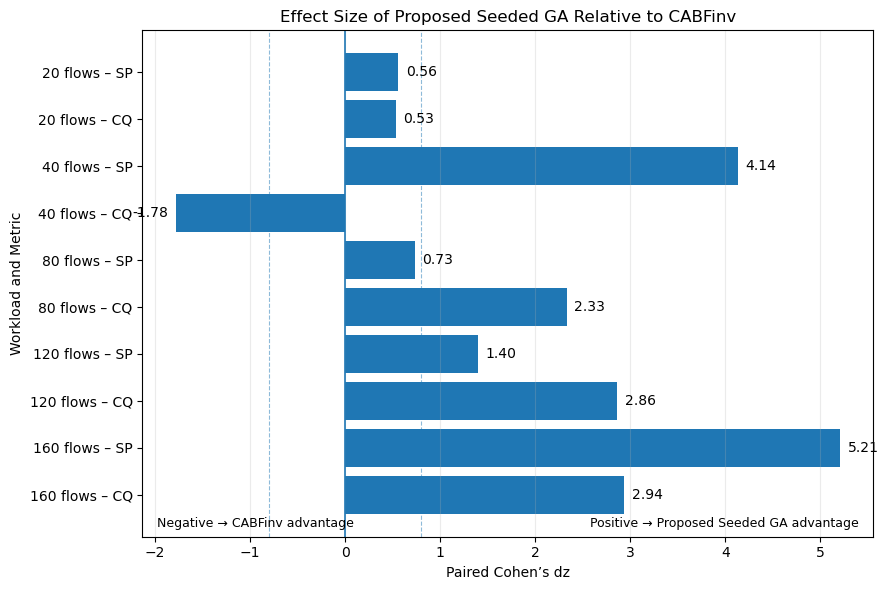

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Keep only Service Percentage and Criticality Quality
plot_df = final_statistical_results_df[
    final_statistical_results_df["Metric"].isin(
        ["Service Percentage", "Criticality Quality"]
    )
].copy()

# Short labels for the figure
plot_df["Label"] = (
    plot_df["Flows"].astype(int).astype(str)
    + " flows – "
    + plot_df["Metric"].replace({
        "Service Percentage": "SP",
        "Criticality Quality": "CQ"
    })
)

# Reverse order for horizontal presentation
plot_df = plot_df.iloc[::-1].reset_index(drop=True)

y = np.arange(len(plot_df))
values = plot_df["Paired Cohen's d"]

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    y,
    values
)

# Zero reference line
ax.axvline(0, linewidth=1.2)

# Conventional large-effect references
ax.axvline(0.8, linestyle="--", linewidth=0.8, alpha=0.5)
ax.axvline(-0.8, linestyle="--", linewidth=0.8, alpha=0.5)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["Label"])

ax.set_xlabel("Paired Cohen’s dz​")
ax.set_ylabel("Workload and Metric")

ax.set_title(
    "Effect Size of Proposed Seeded GA Relative to CABFinv"
)

# Add effect-size values to bars
for bar, value in zip(bars, values):
    y_pos = bar.get_y() + bar.get_height() / 2

    if value >= 0:
        ax.text(
            value + 0.08,
            y_pos,
            f"{value:.2f}",
            va="center"
        )
    else:
        ax.text(
            value - 0.08,
            y_pos,
            f"{value:.2f}",
            va="center",
            ha="right"
        )

# Explain direction directly on figure
ax.text(
    0.98, 0.02,
    "Positive → Proposed Seeded GA advantage",
    transform=ax.transAxes,
    ha="right",
    fontsize=9
)

ax.text(
    0.02, 0.02,
    "Negative → CABFinv advantage",
    transform=ax.transAxes,
    ha="left",
    fontsize=9
)

ax.grid(axis="x", alpha=0.25)

plt.tight_layout()

plt.savefig(
    "GA_vs_CABFinv_Effect_Size_Diverging.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

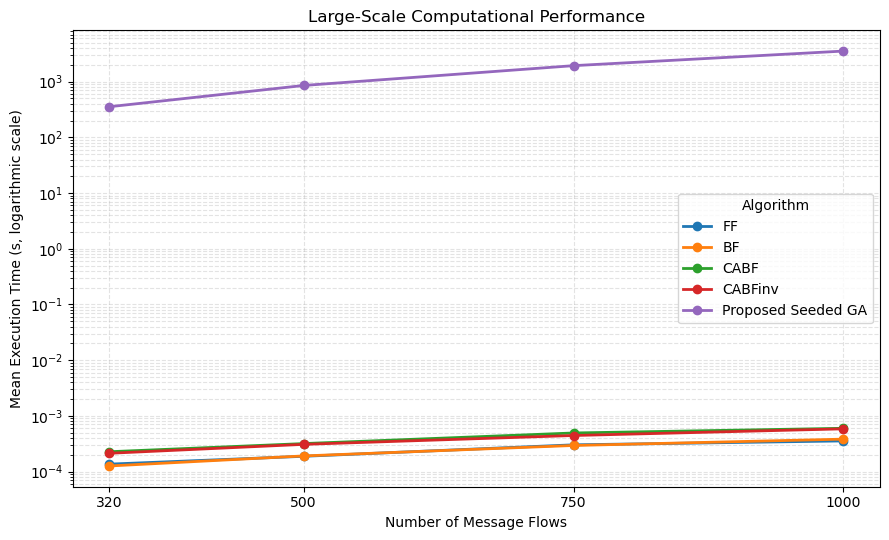

In [ ]:
import matplotlib.pyplot as plt

# Large-scale benchmark mean execution times
flows = [320, 500, 750, 1000]

execution_times = {
    "FF": [0.000136, 0.000188, 0.000302, 0.000355],
    "BF": [0.000126, 0.000191, 0.000294, 0.000382],
    "CABF": [0.000227, 0.000318, 0.000493, 0.000598],
    "CABFinv": [0.000213, 0.000308, 0.000444, 0.000585],
    "Proposed Seeded GA": [354.87, 853.97, 1936.19, 3538.28]
}

fig, ax = plt.subplots(figsize=(9, 5.5))

for algorithm, times in execution_times.items():
    ax.plot(
        flows,
        times,
        marker="o",
        linewidth=2,
        label=algorithm
    )

# Essential because of the very large runtime difference
ax.set_yscale("log")

ax.set_xlabel("Number of Message Flows")
ax.set_ylabel("Mean Execution Time (s, logarithmic scale)")
ax.set_title("Large-Scale Computational Performance")

ax.set_xticks(flows)

ax.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.35
)

ax.legend(title="Algorithm")

plt.tight_layout()

plt.savefig(
    "Large_Scale_Execution_Time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

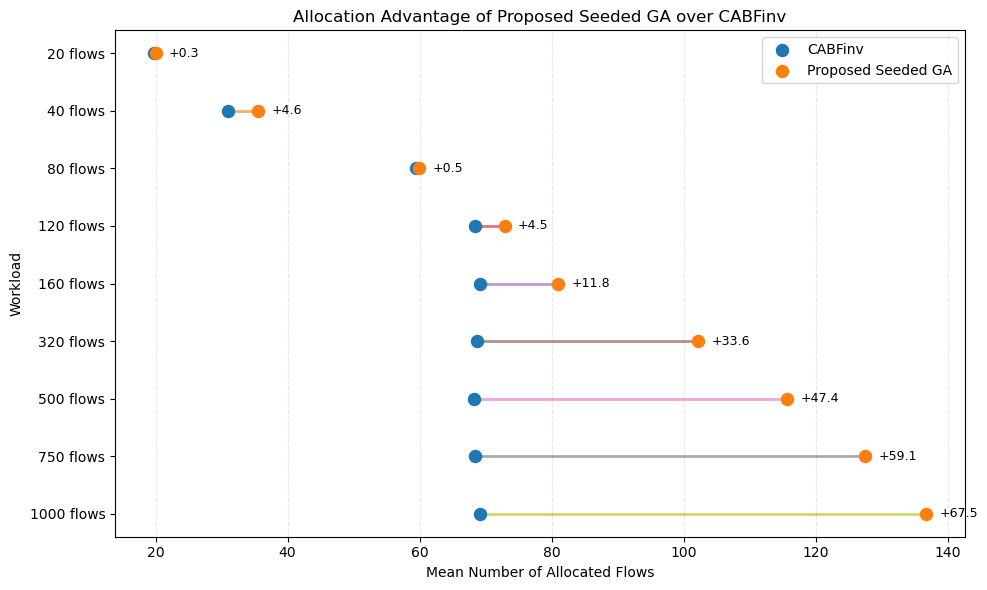

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Workloads
flows = np.array([20, 40, 80, 120, 160, 320, 500, 750, 1000])

# Mean allocated flows
# Main benchmark values = Service Percentage × workload
cabfinv_allocated = np.array([
    19.70, 31.00, 59.43, 68.37, 69.20,
    68.63, 68.27, 68.43, 69.20
])

ga_allocated = np.array([
    20.00, 35.57, 59.93, 72.90, 81.00,
    102.23, 115.67, 127.50, 136.73
])

y = np.arange(len(flows))

fig, ax = plt.subplots(figsize=(10, 6))

# Connecting lines
for i in range(len(flows)):
    ax.plot(
        [cabfinv_allocated[i], ga_allocated[i]],
        [y[i], y[i]],
        linewidth=2,
        alpha=0.65
    )

# End points
ax.scatter(
    cabfinv_allocated,
    y,
    s=75,
    label="CABFinv",
    zorder=3
)

ax.scatter(
    ga_allocated,
    y,
    s=75,
    label="Proposed Seeded GA",
    zorder=3
)

# Show the gain beside GA point
for i in range(len(flows)):
    difference = ga_allocated[i] - cabfinv_allocated[i]

    ax.text(
        ga_allocated[i] + 2,
        y[i],
        f"+{difference:.1f}",
        va="center",
        fontsize=9
    )

ax.set_yticks(y)
ax.set_yticklabels([f"{f} flows" for f in flows])

ax.set_xlabel("Mean Number of Allocated Flows")
ax.set_ylabel("Workload")
ax.set_title(
    "Allocation Advantage of Proposed Seeded GA over CABFinv"
)

ax.legend()
ax.grid(axis="x", linestyle="--", alpha=0.3)

# Small workloads at top
ax.invert_yaxis()

plt.tight_layout()

plt.savefig(
    "GA_CABFinv_Dumbbell.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from statsmodels.stats.multitest import multipletests

# Apply Holm correction only to the metrics reported

mask = significance_df["Metric"].isin([
    "Service Percentage",
    "Criticality Quality"
])

holm_pvalues = multipletests(
    significance_df.loc[mask, "p-value"],
    alpha=0.05,
    method="holm"
)[1]

significance_df.loc[mask, "Holm-adjusted p-value"] = holm_pvalues
significance_df.loc[mask, "Significant after Holm"] = (
    holm_pvalues < 0.05
)

print(
    significance_df.loc[
        mask,
        [
            "Flows",
            "Metric",
            "Mean Difference",
            "p-value",
            "Holm-adjusted p-value",
            "Cohen dz"
        ]
    ]
    .round(6)
    .to_string(index=False)
)

 Flows              Metric  Mean Difference  p-value  Holm-adjusted p-value  Cohen dz
    20  Service Percentage         0.015000 0.006656               0.013311  0.560765
    20 Criticality Quality         0.015036 0.008866               0.013311  0.532414
    40  Service Percentage         0.114167 0.000001               0.000014  4.135245
    40 Criticality Quality        -0.046072 0.000002               0.000015 -1.783405
    80  Service Percentage         0.006250 0.001886               0.005659  0.732828
    80 Criticality Quality         0.027032 0.000002               0.000015  2.330105
   120  Service Percentage         0.037778 0.000002               0.000015  1.401397
   120 Criticality Quality         0.031987 0.000002               0.000015  2.864168
   160  Service Percentage         0.073750 0.000002               0.000015  5.209302
   160 Criticality Quality         0.025470 0.000002               0.000015  2.936412


In [ ]:
import pandas as pd

print("=" * 80)
print("GA PARAMETER TUNING EXTRACTION")
print("=" * 80)

# Take a snapshot of globals to avoid:
# RuntimeError: dictionary changed size during iteration
global_items = list(globals().items())

# 1. Find relevant DataFrames
print("\n### DATAFRAMES ###\n")

for name, obj in global_items:
    if isinstance(obj, pd.DataFrame):
        name_lower = name.lower()

        if any(k in name_lower for k in
               ["tuning", "config", "result", "parameter", "ga"]):

            print(f"\nDataFrame name: {name}")
            print(f"Shape: {obj.shape}")
            display(obj)


# 2. Find relevant variables
print("\n### GA/TUNING VARIABLES ###\n")

keywords = [
    "population",
    "generation",
    "mutation",
    "tournament",
    "improvement",
    "config",
    "tuning",
    "weight"
]

for name, value in global_items:
    if (
        not name.startswith("_")
        and any(k in name.lower() for k in keywords)
        and not callable(value)
    ):
        try:
            if not isinstance(value, pd.DataFrame):
                print(f"{name} = {value}")
        except:
            pass

GA PARAMETER TUNING EXTRACTION

### DATAFRAMES ###


DataFrame name: all_results
Shape: (20, 9)


,Algorithm,Avg servP,Avg avCL,Avg Allocated Flows,Avg Criticality Score,Avg Criticality Quality,Avg Fitness,Avg Capacity Violation,Flows
0,FF,0.733300,1.323000,14.670000,39.170000,0.892300,15.559000,0.000000,20
1,BF,0.745000,1.351100,14.900000,39.400000,0.883000,15.783000,0.000000,20
2,CABF,0.820000,1.462000,16.400000,41.500000,0.846000,17.246000,0.000000,20
3,CABFinv,0.985000,1.673800,19.700000,45.830000,0.775400,20.475400,0.000000,20
4,FF,0.407500,1.460100,16.300000,41.300000,0.846600,17.146600,0.000000,40
5,BF,0.395800,1.415800,15.830000,40.830000,0.861400,16.694700,0.000000,40
6,CABF,0.727500,2.018100,29.100000,57.670000,0.660600,29.760600,0.000000,40
7,CABFinv,0.799200,2.158300,31.970000,58.600000,0.613900,32.580600,0.000000,40
8,FF,0.204600,1.427600,16.370000,41.930000,0.857500,17.224100,0.000000,80
9,BF,0.202900,1.426200,16.230000,41.670000,0.857900,17.091300,0.000000,80



DataFrame name: config_raw_df
Shape: (150, 12)


,Flows,Run,Seed,Algorithm,servP,avCL,Allocated Flows,Criticality Score,Criticality Quality,Fitness,Capacity Violation,Execution Time (s)
0,80,1,81000,FF,0.187500,1.400000,15,39,0.866667,15.866667,0,0.000029
1,80,1,81000,BF,0.187500,1.400000,15,39,0.866667,15.866667,0,0.000034
2,80,1,81000,CABF,0.700000,2.857143,56,64,0.380952,56.380952,0,0.000078
3,80,1,81000,CABFinv,0.750000,2.916667,60,65,0.361111,60.361111,0,0.000084
4,80,1,81000,Enhanced Seeded GA,0.762500,2.803279,61,73,0.398907,61.398907,0,67.189855
5,80,2,81001,FF,0.200000,1.375000,16,42,0.875000,16.875000,0,0.000038
6,80,2,81001,BF,0.212500,1.470588,17,43,0.843137,17.843137,0,0.000033
7,80,2,81001,CABF,0.662500,2.773585,53,65,0.408805,53.408805,0,0.000084
8,80,2,81001,CABFinv,0.750000,2.866667,60,68,0.377778,60.377778,0,0.000079
9,80,2,81001,Enhanced Seeded GA,0.750000,2.800000,60,72,0.400000,60.400000,0,68.245178



DataFrame name: config_summary_df
Shape: (15, 14)


...


DataFrame name: results
Shape: (15, 13)


,Flows,Metric,GA Mean,CABFinv Mean,Mean Difference,Median Difference,Wilcoxon Statistic,p-value,Significant (p < 0.05),Paired Cohen's d,Holm-adjusted p-value,Significant after Holm (p < 0.05),Effect Size
0,20,Service Percentage,1.000000,0.985000,0.015000,0.000000,0.000000,0.006656,True,0.560765,0.013311,True,Medium
1,20,Criticality Quality,0.793333,0.778298,0.015036,0.016667,97.000000,0.008866,True,0.532414,0.013311,True,Medium
2,20,Overall Fitness,20.793333,20.478298,0.315036,0.033333,0.000000,0.000002,True,0.615580,0.000023,True,Medium
3,40,Service Percentage,0.889167,0.775000,0.114167,0.100000,0.000000,0.000001,True,4.135245,0.000021,True,Large
4,40,Criticality Quality,0.570861,0.616933,-0.046072,-0.047536,3.000000,0.000002,True,-1.783405,0.000023,True,Large
5,40,Overall Fitness,36.137527,31.616933,4.520594,3.991980,0.000000,0.000002,True,4.153652,0.000023,True,Large
6,80,Service Percentage,0.749167,0.742917,0.006250,0.000000,0.000000,0.001886,True,0.732828,0.005659,True,Medium
7,80,Criticality Quality,0.400970,0.373938,0.027032,0.027322,0.000000,0.000002,True,2.330105,0.000023,True,Large
8,80,Overall Fitness,60.334303,59.807271,0.527032,0.037644,0.000000,0.000002,True,0.769850,0.000023,True,Medium
9,120,Service Percentage,0.607500,0.569722,0.037778,0.029167,0.000000,0.000002,True,1.401397,0.000023,True,Large



DataFrame name: final_statistical_results_df
Shape: (15, 10)


,Flows,Metric,GA Mean,CABFinv Mean,Mean Difference,p-value,Holm-adjusted p-value,Paired Cohen's d,Effect Size,Significant after Holm (p < 0.05)
0,20,Service Percentage,1.000000,0.985000,0.015000,0.006656,0.013311,0.560765,Medium,True
1,20,Criticality Quality,0.793333,0.778298,0.015036,0.008866,0.013311,0.532414,Medium,True
2,20,Overall Fitness,20.793333,20.478298,0.315036,0.000002,0.000023,0.615580,Medium,True
3,40,Service Percentage,0.889167,0.775000,0.114167,0.000001,0.000021,4.135245,Large,True
4,40,Criticality Quality,0.570861,0.616933,-0.046072,0.000002,0.000023,-1.783405,Large,True
5,40,Overall Fitness,36.137527,31.616933,4.520594,0.000002,0.000023,4.153652,Large,True
6,80,Service Percentage,0.749167,0.742917,0.006250,0.001886,0.005659,0.732828,Medium,True
7,80,Criticality Quality,0.400970,0.373938,0.027032,0.000002,0.000023,2.330105,Large,True
8,80,Overall Fitness,60.334303,59.807271,0.527032,0.000002,0.000023,0.769850,Medium,True
9,120,Service Percentage,0.607500,0.569722,0.037778,0.000002,0.000023,1.401397,Large,True



### GA/TUNING VARIABLES ###

population = [{'F1': ('N1', 1), 'F2': ('N1', 1), 'F3': ('N1', 1), 'F4': ('N1', 1), 'F5': ('N1', 1), 'F6': ('N2', 1), 'F7': ('N1', 1), 'F8': ('N2', 1), 'F9': ('N2', 1), 'F10': ('N3', 1), 'F11': ('N3', 1), 'F12': ('N3', 1), 'F13': ('N1', 2), 'F14': ('N2', 3), 'F15': ('N2', 3), 'F16': (None, None), 'F17': (None, None), 'F18': (None, None), 'F19': (None, None), 'F20': (None, None), 'F21': (None, None), 'F22': (None, None), 'F23': (None, None), 'F24': (None, None), 'F25': (None, None), 'F26': (None, None), 'F27': ('N2', 3), 'F28': (None, None), 'F29': (None, None), 'F30': (None, None), 'F31': (None, None), 'F32': (None, None), 'F33': (None, None), 'F34': (None, None), 'F35': (None, None), 'F36': (None, None), 'F37': (None, None), 'F38': (None, None), 'F39': (None, None), 'F40': (None, None)}, {'F1': ('N3', 1), 'F2': ('N3', 1), 'F3': ('N2', 1), 'F4': ('N2', 1), 'F5': ('N2', 1), 'F6': ('N1', 1), 'F7': ('N3', 1), 'F8': ('N1', 1), 'F9': ('N1', 1), 'F10': ('N1', 1),

In [ ]:
import pandas as pd

print("DataFrames in notebook:\n")

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print(f"{name:40} {obj.shape}")

DataFrames in notebook:

df_20                                    (4, 8)
df_40                                    (4, 8)
df_80                                    (4, 8)
df_120                                   (4, 8)
df_160                                   (4, 8)
df                                       (60, 8)
all_results                              (20, 9)
data                                     (5, 14)
plot_df                                  (25, 14)
comparison_large_df                      (5, 9)
debug_comparison_df                      (10, 10)
benchmark_raw_df                         (750, 12)
benchmark_summary_df                     (25, 14)
group                                    (5, 12)
statistics_df                            (15, 17)
comparison                               (2, 14)
runtime_comparison                       (2, 2)
subset                                   (150, 12)
config_raw_df                            (150, 12)
config_summary_df                        

In [ ]:
# Export complete GA parameter-tuning evidence

ga_tuning_raw_df.to_csv(
    "GA_tuning_raw_results.csv",
    index=False
)

ga_tuning_by_flow_df.to_csv(
    "GA_tuning_by_flow.csv",
    index=False
)

ga_tuning_comparison_df.to_csv(
    "GA_tuning_comparison.csv",
    index=False
)

print("Export complete:")
print("1. GA_tuning_raw_results.csv")
print("2. GA_tuning_by_flow.csv")
print("3. GA_tuning_comparison.csv")

Export complete:
1. GA_tuning_raw_results.csv
2. GA_tuning_by_flow.csv
3. GA_tuning_comparison.csv


In [ ]:
benchmark_summary_df.to_csv(
    "main_benchmark_summary.csv",
    index=False
)

print("Saved as: main_benchmark_summary.csv")

Saved as: main_benchmark_summary.csv


In [ ]:
large_benchmark_summary_df.to_csv(
    "large_benchmark_summary.csv",
    index=False
)

print("Saved as: large_benchmark_summary.csv")

Saved as: large_benchmark_summary.csv


In [ ]:
seeding_summary_df.to_csv(
    "seeding_summary.csv",
    index=False
)

print("Saved as: seeding_summary.csv")

Saved as: seeding_summary.csv


In [ ]:
final_statistical_results_df.to_csv(
    "final_statistical_results.csv",
    index=False
)

print("Saved as: final_statistical_results.csv")

Saved as: final_statistical_results.csv


In [ ]:
print(ga_tuning_comparison_df.to_string(index=False))

Configuration  Population Size  Generations  Mutation Rate  Tournament Size  Local Search Passes  Mean_servP  SD_servP  Mean_avCL  SD_avCL  Mean_Allocated_Flows  SD_Allocated_Flows  Mean_Criticality_Quality  SD_Criticality_Quality  Mean_Fitness  SD_Fitness  Mean_Execution_Time_s  Maximum_Capacity_Violation  Service Rank  QoS Rank  Fitness Rank  Stability Rank  Runtime Rank  Selection Score
            D               50          100       0.050000                3                    5    0.613611  0.094877   2.879730 0.065086             70.700000           10.082932                  0.373423                0.021695     71.073423   10.066878             115.895632                           0      1.000000  4.000000      1.000000        4.000000      4.000000         2.200000
            C               50           50       0.050000                3                    5    0.612708  0.094389   2.879096 0.064100             70.600000           10.060507                  0.373635        

In [ ]:
print(ga_tuning_by_flow_df.to_string(index=False))

 Flows          Algorithm  Mean_servP  SD_servP  Mean_avCL  SD_avCL  Mean_Allocated_Flows  SD_Allocated_Flows  Mean_Criticality_Quality  SD_Criticality_Quality  Mean_Fitness  SD_Fitness  Mean_Execution_Time_s  SD_Execution_Time_s Configuration  Population Size  Generations  Mutation Rate  Tournament Size  Local Search Passes
    80 Enhanced Seeded GA    0.731250  0.029610   2.814501 0.060761             58.500000            2.368778                  0.395166                0.020254     58.895166    2.360767              13.751729             0.738155             A               30           50       0.050000                3                    2
   120 Enhanced Seeded GA    0.595833  0.016316   2.907724 0.028880             71.500000            1.957890                  0.364092                0.009627     71.864092    1.958348              29.472615             0.820267             A               30           50       0.050000                3                    2
   160 Enhanced See

In [ ]:
print(benchmark_summary_df.to_string(index=False))

 Flows          Algorithm  Mean_servP  SD_servP  Mean_avCL  SD_avCL  Mean_Allocated_Flows  SD_Allocated_Flows  Mean_Criticality_Quality  SD_Criticality_Quality  Mean_Fitness  SD_Fitness  Mean_Execution_Time_s  SD_Execution_Time_s
    20                 BF    0.735000  0.054377   1.308974 0.129092             14.700000            1.087547                  0.897009                0.043031     15.597009    1.069837               0.000010             0.000002
    20               CABF    0.803333  0.078711   1.421591 0.176606             16.066667            1.574218                  0.859470                0.058869     16.926136    1.532465               0.000025             0.000003
    20            CABFinv    0.985000  0.026749   1.665107 0.079791             19.700000            0.534983                  0.778298                0.026597     20.478298    0.537323               0.000022             0.000002
    20 Enhanced Seeded GA    1.000000  0.000000   1.620000 0.107959             

In [ ]:
print(large_benchmark_summary_df.to_string(index=False))

 Flows          Algorithm  Mean_servP  SD_servP  Mean_avCL  SD_avCL  Mean_Allocated_Flows  SD_Allocated_Flows  Mean_Criticality_Quality  SD_Criticality_Quality  Mean_Fitness  SD_Fitness  Mean_Execution_Time_s  SD_Execution_Time_s
   320                 BF    0.052604  0.005064   1.493535 0.118908             16.833333            1.620629                  0.835488                0.039636     17.668822    1.601390               0.000126             0.000007
   320               CABF    0.214479  0.014414   3.000000 0.000000             68.633333            4.612452                  0.333333                0.000000     68.966667    4.612452               0.000227             0.000016
   320            CABFinv    0.214479  0.014414   3.000000 0.000000             68.633333            4.612452                  0.333333                0.000000     68.966667    4.612452               0.000213             0.000008
   320 Enhanced Seeded GA    0.319479  0.014016   2.970466 0.014838            1

In [ ]:
# ==========================================================
# 
# ==========================================================

import numpy as np

from scipy.optimize import milp
from scipy.optimize import LinearConstraint
from scipy.optimize import Bounds
from scipy.sparse import lil_matrix


def solve_exact_allocation(flows, networks):
    """
    Compute an exact optimal allocation for a scenario.

    Objective hierarchy
    -------------------
    1. Maximise AllocatedFlows.
    2. Among solutions with the same maximum number of
       allocated flows, maximise QoS score.

    Returns
    -------
    allocation : dict
        allocation[flow] = (network, level)
        or (None, None) when unallocated.

    metrics : dict
        Metrics produced by the existing
        evaluate_solution() function.
    """

    # ------------------------------------------------------
    # Determine the maximum supported QoS level index.
    # This follows the same scoring convention used by
    # evaluate_solution().
    # ------------------------------------------------------

    Lmax = max(
        max(profile.keys())
        for profile in flows.values()
    )

    # ------------------------------------------------------
    # Build one binary decision variable for every
    # (flow, network, supported QoS level) combination.
    # ------------------------------------------------------

    variables = []

    for flow, levels in flows.items():
        for network in networks:
            for level, demand in levels.items():

                # QoS reward used by evaluate_solution():
                # score = 1 + Lmax - level
                #
                # When Lmax = 3:
                # L1 -> 3
                # L2 -> 2
                # L3 -> 1

                qos_score = (
                    1 + Lmax - level
                )

                variables.append(
                    (
                        flow,
                        network,
                        level,
                        demand,
                        qos_score
                    )
                )

    n_variables = len(variables)

    if n_variables == 0:
        raise ValueError(
            "No feasible decision variables could be created."
        )

    # All decision variables are binary.

    integrality = np.ones(
        n_variables,
        dtype=int
    )

    bounds = Bounds(
        lb=np.zeros(n_variables),
        ub=np.ones(n_variables)
    )

    # ------------------------------------------------------
    # Construct common constraints
    # ------------------------------------------------------

    flow_names = list(flows.keys())
    network_names = list(networks.keys())

    n_flow_constraints = len(flow_names)
    n_network_constraints = len(network_names)

    n_constraints = (
        n_flow_constraints
        + n_network_constraints
    )

    constraint_matrix = lil_matrix(
        (n_constraints, n_variables),
        dtype=float
    )

    lower_bounds = np.full(
        n_constraints,
        -np.inf
    )

    upper_bounds = np.zeros(
        n_constraints
    )

    # ------------------------------------------------------
    # Constraint 1:
    # Each flow can be assigned to at most one
    # (network, QoS level) combination.
    # ------------------------------------------------------

    for row, flow in enumerate(flow_names):

        for column, variable in enumerate(variables):

            variable_flow = variable[0]

            if variable_flow == flow:
                constraint_matrix[
                    row,
                    column
                ] = 1.0

        upper_bounds[row] = 1.0

    # ------------------------------------------------------
    # Constraint 2:
    # Total bandwidth assigned to each network cannot
    # exceed that network's capacity.
    # ------------------------------------------------------

    offset = n_flow_constraints

    for network_index, network in enumerate(
        network_names
    ):

        row = offset + network_index

        for column, variable in enumerate(variables):

            (
                flow,
                variable_network,
                level,
                demand,
                qos_score
            ) = variable

            if variable_network == network:
                constraint_matrix[
                    row,
                    column
                ] = demand

        upper_bounds[row] = networks[network]

    common_constraints = LinearConstraint(
        constraint_matrix.tocsr(),
        lower_bounds,
        upper_bounds
    )

    # ======================================================
    # STAGE 1
    # Maximise number of allocated flows.
    #
    # scipy.optimize.milp performs minimisation,
    # therefore maximise sum(x) by minimising -sum(x).
    # ======================================================

    stage1_objective = -np.ones(
        n_variables
    )

    stage1_result = milp(
        c=stage1_objective,
        integrality=integrality,
        bounds=bounds,
        constraints=common_constraints,
        options={
            "disp": False
        }
    )

    if not stage1_result.success:
        raise RuntimeError(
            "Stage 1 exact optimisation failed: "
            + stage1_result.message
        )

    stage1_solution = np.rint(
        stage1_result.x
    ).astype(int)

    optimal_allocated = int(
        stage1_solution.sum()
    )

    # ======================================================
    # STAGE 2
    # Fix AllocatedFlows = optimal_allocated and maximise
    # retained criticality-aware QoS quality.
    # ======================================================

    allocation_count_row = np.ones(
        (1, n_variables)
    )

    allocation_count_constraint = LinearConstraint(
        allocation_count_row,
        lb=np.array(
            [optimal_allocated]
        ),
        ub=np.array(
            [optimal_allocated]
        )
    )

    qos_scores = np.array(
        [
            variable[4]
            for variable in variables
        ],
        dtype=float
    )

  
    stage2_objective = -qos_scores

    stage2_result = milp(
        c=stage2_objective,
        integrality=integrality,
        bounds=bounds,
        constraints=[
            common_constraints,
            allocation_count_constraint
        ],
        options={
            "disp": False
        }
    )

    if not stage2_result.success:
        raise RuntimeError(
            "Stage 2 exact optimisation failed: "
            + stage2_result.message
        )

    exact_solution = np.rint(
        stage2_result.x
    ).astype(int)

    # ------------------------------------------------------
    # Convert the binary MILP solution into the same
    # chromosome representation used by the GA.
    # ------------------------------------------------------

    allocation = {
        flow: (None, None)
        for flow in flows
    }

    for selected, variable in zip(
        exact_solution,
        variables
    ):

        if selected != 1:
            continue

        (
            flow,
            network,
            level,
            demand,
            qos_score
        ) = variable

        allocation[flow] = (
            network,
            level
        )

    # ------------------------------------------------------
    # Evaluate using the existing dissertation evaluator.
    # This ensures that the exact and GA solutions are
    # assessed using the same metrics and fitness function.
    # ------------------------------------------------------

    metrics = evaluate_solution(
        allocation,
        flows,
        networks
    )

    # ------------------------------------------------------
    # Defensive validation
    # ------------------------------------------------------

    if metrics["CapacityViolation"] != 0:
        raise RuntimeError(
            "Exact solver returned an infeasible allocation."
        )

    if (
        metrics["AllocatedFlows"]
        != optimal_allocated
    ):
        raise RuntimeError(
            "Exact allocation count does not match "
            "the Stage 1 optimum."
        )

    return allocation, metrics


print(
    "Exact two-stage MILP function defined successfully."
)

Exact two-stage MILP function defined successfully.


In [ ]:
# ==========================================================
# EXACT OPTIMISATION VALIDATION — SINGLE 20-FLOW SCENARIO
# Proposed Seeded GA vs Exact MILP
# ==========================================================

import random
import time

# ----------------------------------------------------------
# Controlled scenario
# ----------------------------------------------------------



TEST_FLOW_SIZE = 80
TEST_SCENARIO_SEED = 87001
TEST_GA_SEED = 187001
random.seed(TEST_SCENARIO_SEED)

test_networks, test_flows = generate_scenario(
    num_flows=TEST_FLOW_SIZE,
    hC=0.8
)

# ----------------------------------------------------------
# 1. Exact optimisation
# ----------------------------------------------------------

start = time.perf_counter()

exact_allocation, exact_metrics = solve_exact_allocation(
    test_flows,
    test_networks
)

exact_time = time.perf_counter() - start

# ----------------------------------------------------------
# 2. Proposed Seeded GA
# Use the frozen final dissertation configuration
# ----------------------------------------------------------

random.seed(TEST_GA_SEED)

start = time.perf_counter()

ga_allocation, ga_metrics, _, _ = run_ga(
    test_flows,
    test_networks,
    population_size=FINAL_POPULATION_SIZE,
    generations=FINAL_GENERATIONS,
    mutation_rate=FINAL_MUTATION_RATE,
    tournament_size=FINAL_TOURNAMENT_SIZE,
    local_search_passes=FINAL_LOCAL_SEARCH_PASSES
)

ga_time = time.perf_counter() - start

# ----------------------------------------------------------
# Calculate comparison gaps
# ----------------------------------------------------------

allocation_gap = (
    (
        exact_metrics["AllocatedFlows"]
        - ga_metrics["AllocatedFlows"]
    )
    / exact_metrics["AllocatedFlows"]
    * 100
    if exact_metrics["AllocatedFlows"] > 0
    else 0.0
)

fitness_gap = (
    (
        exact_metrics["Fitness"]
        - ga_metrics["Fitness"]
    )
    / exact_metrics["Fitness"]
    * 100
    if exact_metrics["Fitness"] > 0
    else 0.0
)

# ----------------------------------------------------------
# Validation
# ----------------------------------------------------------

assert exact_metrics["CapacityViolation"] == 0
assert ga_metrics["CapacityViolation"] == 0

# The GA must never exceed the exact optimum.
assert (
    ga_metrics["AllocatedFlows"]
    <= exact_metrics["AllocatedFlows"]
), "GA allocated more flows than the exact optimum."

# ----------------------------------------------------------
# Display results
# ----------------------------------------------------------

print("=" * 70)
print("SMALL-INSTANCE EXACT OPTIMISATION VALIDATION")
print("=" * 70)

print(f"Flows: {TEST_FLOW_SIZE}")
print(f"Scenario seed: {TEST_SCENARIO_SEED}")

print("\nExact MILP")
print("-" * 40)
print(
    f"Allocated flows      : "
    f"{exact_metrics['AllocatedFlows']}"
)
print(
    f"Criticality Quality : "
    f"{exact_metrics['CriticalityQuality']:.6f}"
)
print(
    f"Overall Fitness     : "
    f"{exact_metrics['Fitness']:.6f}"
)
print(
    f"Execution time      : "
    f"{exact_time:.4f} s"
)

print("\nProposed Seeded GA")
print("-" * 40)
print(
    f"Allocated flows      : "
    f"{ga_metrics['AllocatedFlows']}"
)
print(
    f"Criticality Quality : "
    f"{ga_metrics['CriticalityQuality']:.6f}"
)
print(
    f"Overall Fitness     : "
    f"{ga_metrics['Fitness']:.6f}"
)
print(
    f"Execution time      : "
    f"{ga_time:.4f} s"
)

print("\nOptimality comparison")
print("-" * 40)
print(
    f"Allocation gap      : "
    f"{allocation_gap:.4f}%"
)
print(
    f"Fitness gap         : "
    f"{fitness_gap:.4f}%"
)

SMALL-INSTANCE EXACT OPTIMISATION VALIDATION
Flows: 80
Scenario seed: 87001

Exact MILP
----------------------------------------
Allocated flows      : 58
Criticality Quality : 0.431034
Overall Fitness     : 58.431034
Execution time      : 0.2336 s

Proposed Seeded GA
----------------------------------------
Allocated flows      : 58
Criticality Quality : 0.425287
Overall Fitness     : 58.425287
Execution time      : 25.5121 s

Optimality comparison
----------------------------------------
Allocation gap      : 0.0000%
Fitness gap         : 0.0098%


In [ ]:
# ==========================================================
# SMALL-INSTANCE OPTIMALITY BENCHMARK
# Exact MILP vs Proposed Seeded GA
# 20, 30, 40 flows × 10 matched scenarios
# ==========================================================

import random
import time
import pandas as pd
import numpy as np

OPTIMALITY_FLOW_SIZES = (20, 30, 40)
OPTIMALITY_RUNS = 10
OPTIMALITY_BASE_SEED = 30000

optimality_rows = []

for num_flows in OPTIMALITY_FLOW_SIZES:

    print(
        f"\nRunning exact-optimality validation "
        f"for {num_flows} flows..."
    )

    for run_index in range(OPTIMALITY_RUNS):

        scenario_seed = (
            OPTIMALITY_BASE_SEED
            + num_flows * 1000
            + run_index
        )

        ga_seed = (
            OPTIMALITY_BASE_SEED
            + 100000
            + num_flows * 1000
            + run_index
        )

        # --------------------------------------------------
        # Generate ONE scenario shared by both methods
        # --------------------------------------------------

        random.seed(scenario_seed)

        networks, flows = generate_scenario(
            num_flows=num_flows,
            hC=0.8
        )

        # --------------------------------------------------
        # Exact MILP
        # --------------------------------------------------

        start = time.perf_counter()

        exact_allocation, exact_metrics = (
            solve_exact_allocation(
                flows,
                networks
            )
        )

        exact_time = (
            time.perf_counter() - start
        )

        # --------------------------------------------------
        # Proposed Seeded GA
        # --------------------------------------------------

        random.seed(ga_seed)

        start = time.perf_counter()

        ga_allocation, ga_metrics, _, _ = run_ga(
            flows,
            networks,
            population_size=FINAL_POPULATION_SIZE,
            generations=FINAL_GENERATIONS,
            mutation_rate=FINAL_MUTATION_RATE,
            tournament_size=FINAL_TOURNAMENT_SIZE,
            local_search_passes=FINAL_LOCAL_SEARCH_PASSES
        )

        ga_time = (
            time.perf_counter() - start
        )

        # --------------------------------------------------
        # Defensive checks
        # --------------------------------------------------

        assert (
            exact_metrics["CapacityViolation"] == 0
        )

        assert (
            ga_metrics["CapacityViolation"] == 0
        )

        assert (
            ga_metrics["AllocatedFlows"]
            <= exact_metrics["AllocatedFlows"]
        )

        # --------------------------------------------------
        # Gaps
        # --------------------------------------------------

        allocation_gap = (
            (
                exact_metrics["AllocatedFlows"]
                - ga_metrics["AllocatedFlows"]
            )
            / exact_metrics["AllocatedFlows"]
            * 100
            if exact_metrics["AllocatedFlows"] > 0
            else 0.0
        )

        fitness_gap = (
            (
                exact_metrics["Fitness"]
                - ga_metrics["Fitness"]
            )
            / exact_metrics["Fitness"]
            * 100
            if exact_metrics["Fitness"] > 0
            else 0.0
        )

        exact_match = (
            abs(
                exact_metrics["Fitness"]
                - ga_metrics["Fitness"]
            )
            < 1e-9
        )

        # --------------------------------------------------
        # Record
        # --------------------------------------------------

        optimality_rows.append({
            "Flows": num_flows,
            "Run": run_index + 1,
            "Scenario Seed": scenario_seed,
            "GA Seed": ga_seed,

            "Exact Allocated Flows":
                exact_metrics["AllocatedFlows"],

            "GA Allocated Flows":
                ga_metrics["AllocatedFlows"],

            "Exact Criticality Quality":
                exact_metrics["CriticalityQuality"],

            "GA Criticality Quality":
                ga_metrics["CriticalityQuality"],

            "Exact Fitness":
                exact_metrics["Fitness"],

            "GA Fitness":
                ga_metrics["Fitness"],

            "Allocation Gap (%)":
                allocation_gap,

            "Fitness Gap (%)":
                fitness_gap,

            "Exact Fitness Match":
                exact_match,

            "Exact Time (s)":
                exact_time,

            "GA Time (s)":
                ga_time
        })

        print(
            f"  Run {run_index + 1:02d}/{OPTIMALITY_RUNS} | "
            f"Exact A={exact_metrics['AllocatedFlows']} | "
            f"GA A={ga_metrics['AllocatedFlows']} | "
            f"Fitness gap={fitness_gap:.3f}%"
        )


# ==========================================================
# Raw results
# ==========================================================

optimality_raw_df = pd.DataFrame(
    optimality_rows
)


# ==========================================================
# Summary
# ==========================================================

optimality_summary_df = (
    optimality_raw_df
    .groupby(
        "Flows",
        as_index=False
    )
    .agg(
        Mean_Exact_Allocated=(
            "Exact Allocated Flows",
            "mean"
        ),
        Mean_GA_Allocated=(
            "GA Allocated Flows",
            "mean"
        ),
        Mean_Allocation_Gap_Percent=(
            "Allocation Gap (%)",
            "mean"
        ),
        Max_Allocation_Gap_Percent=(
            "Allocation Gap (%)",
            "max"
        ),
        Mean_Exact_Fitness=(
            "Exact Fitness",
            "mean"
        ),
        Mean_GA_Fitness=(
            "GA Fitness",
            "mean"
        ),
        Mean_Fitness_Gap_Percent=(
            "Fitness Gap (%)",
            "mean"
        ),
        Max_Fitness_Gap_Percent=(
            "Fitness Gap (%)",
            "max"
        ),
        Exact_Match_Rate=(
            "Exact Fitness Match",
            "mean"
        ),
        Mean_Exact_Time_s=(
            "Exact Time (s)",
            "mean"
        ),
        Mean_GA_Time_s=(
            "GA Time (s)",
            "mean"
        )
    )
)

optimality_summary_df[
    "Exact_Match_Rate_Percent"
] = (
    optimality_summary_df[
        "Exact_Match_Rate"
    ] * 100
)

print("\n" + "=" * 80)
print("SMALL-INSTANCE OPTIMALITY SUMMARY")
print("=" * 80)

print(
    optimality_summary_df
    .round(4)
    .to_string(index=False)
)


Running exact-optimality validation for 20 flows...
  Run 01/10 | Exact A=20 | GA A=20 | Fitness gap=0.000%
  Run 02/10 | Exact A=20 | GA A=20 | Fitness gap=0.000%
  Run 03/10 | Exact A=20 | GA A=20 | Fitness gap=0.000%
  Run 04/10 | Exact A=20 | GA A=20 | Fitness gap=0.000%
  Run 05/10 | Exact A=20 | GA A=20 | Fitness gap=0.000%
  Run 06/10 | Exact A=20 | GA A=20 | Fitness gap=0.000%
  Run 07/10 | Exact A=20 | GA A=20 | Fitness gap=0.000%
  Run 08/10 | Exact A=20 | GA A=20 | Fitness gap=0.000%
  Run 09/10 | Exact A=20 | GA A=20 | Fitness gap=0.000%
  Run 10/10 | Exact A=20 | GA A=20 | Fitness gap=0.000%

Running exact-optimality validation for 30 flows...
  Run 01/10 | Exact A=30 | GA A=30 | Fitness gap=0.000%
  Run 02/10 | Exact A=30 | GA A=28 | Fitness gap=6.114%
  Run 03/10 | Exact A=30 | GA A=29 | Fitness gap=3.097%
  Run 04/10 | Exact A=30 | GA A=30 | Fitness gap=0.000%
  Run 05/10 | Exact A=27 | GA A=27 | Fitness gap=0.000%
  Run 06/10 | Exact A=30 | GA A=30 | Fitness gap=0.000

In [ ]:
# ==========================================================
# EXACT-OPTIMALITY BENCHMARK — FINAL VALIDATION CHECKS
# ==========================================================

tolerance = 1e-7

# Exact solution must never be worse than the GA
assert (
    optimality_raw_df["GA Fitness"]
    <= optimality_raw_df["Exact Fitness"] + tolerance
).all(), "A GA solution exceeded the exact optimum."

# GA cannot allocate more flows than the exact solution
assert (
    optimality_raw_df["GA Allocated Flows"]
    <= optimality_raw_df["Exact Allocated Flows"]
).all(), "GA allocated more flows than the exact optimum."

# All reported gaps must be non-negative
assert (
    optimality_raw_df["Allocation Gap (%)"]
    >= -tolerance
).all()

assert (
    optimality_raw_df["Fitness Gap (%)"]
    >= -tolerance
).all()

# Display number of exact matches
matches = int(
    optimality_raw_df["Exact Fitness Match"].sum()
)

total = len(optimality_raw_df)

print("=" * 70)
print("FINAL EXACT-OPTIMALITY VALIDATION")
print("=" * 70)

print(f"Total matched scenarios : {total}")
print(f"Exact fitness matches   : {matches}")
print(
    f"Overall exact-match rate: "
    f"{100 * matches / total:.2f}%"
)

print(
    f"Maximum allocation gap  : "
    f"{optimality_raw_df['Allocation Gap (%)'].max():.4f}%"
)

print(
    f"Maximum fitness gap     : "
    f"{optimality_raw_df['Fitness Gap (%)'].max():.4f}%"
)

print("\nAll validation checks passed successfully.")

FINAL EXACT-OPTIMALITY VALIDATION
Total matched scenarios : 30
Exact fitness matches   : 18
Overall exact-match rate: 60.00%
Maximum allocation gap  : 6.6667%
Maximum fitness gap     : 6.1135%

All validation checks passed successfully.


In [ ]:
optimality_raw_df.to_csv(
    "small_instance_optimality_raw.csv",
    index=False
)

optimality_summary_df.to_csv(
    "small_instance_optimality_summary.csv",
    index=False
)

print("Small-instance optimality results exported successfully.")

Small-instance optimality results exported successfully.


In [ ]:
# ==========================================================

# ==========================================================

import random
import time
import pandas as pd
import numpy as np

FLOW_SIZE = 80
N_RUNS = 10
BASE_SEED = 30000

optimality_80_rows = []

print("=" * 75)
print("80-FLOW EXACT OPTIMALITY VALIDATION")
print("=" * 75)

for run_index in range(N_RUNS):

    # Same seed structure used in the previous
    # 20/30/40-flow optimality experiment
    scenario_seed = (
        BASE_SEED
        + FLOW_SIZE * 1000
        + run_index
    )

    ga_seed = (
        BASE_SEED
        + 100000
        + FLOW_SIZE * 1000
        + run_index
    )

    # ------------------------------------------------------
    # Generate one scenario shared by MILP and GA
    # ------------------------------------------------------

    random.seed(scenario_seed)

    networks, flows = generate_scenario(
        num_flows=FLOW_SIZE,
        hC=0.8
    )

    # ------------------------------------------------------
    # Exact MILP
    # ------------------------------------------------------

    start = time.perf_counter()

    exact_allocation, exact_metrics = solve_exact_allocation(
        flows,
        networks
    )

    exact_time = time.perf_counter() - start

    # ------------------------------------------------------
    # Proposed Seeded GA
    # ------------------------------------------------------

    random.seed(ga_seed)

    start = time.perf_counter()

    ga_allocation, ga_metrics, _, _ = run_ga(
        flows,
        networks,
        population_size=FINAL_POPULATION_SIZE,
        generations=FINAL_GENERATIONS,
        mutation_rate=FINAL_MUTATION_RATE,
        tournament_size=FINAL_TOURNAMENT_SIZE,
        local_search_passes=FINAL_LOCAL_SEARCH_PASSES
    )

    ga_time = time.perf_counter() - start

    # ------------------------------------------------------
    # Validation checks
    # ------------------------------------------------------

    assert exact_metrics["CapacityViolation"] == 0
    assert ga_metrics["CapacityViolation"] == 0

    assert (
        ga_metrics["AllocatedFlows"]
        <= exact_metrics["AllocatedFlows"]
    ), "GA allocated more flows than the exact optimum."

    assert (
        ga_metrics["Fitness"]
        <= exact_metrics["Fitness"] + 1e-7
    ), "GA fitness exceeded the exact optimum."

    # ------------------------------------------------------
    # Calculate optimality gaps
    # ------------------------------------------------------

    allocation_gap = (
        (
            exact_metrics["AllocatedFlows"]
            - ga_metrics["AllocatedFlows"]
        )
        / exact_metrics["AllocatedFlows"]
        * 100
        if exact_metrics["AllocatedFlows"] > 0
        else 0.0
    )

    fitness_gap = (
        (
            exact_metrics["Fitness"]
            - ga_metrics["Fitness"]
        )
        / exact_metrics["Fitness"]
        * 100
        if exact_metrics["Fitness"] > 0
        else 0.0
    )

    allocation_match = (
        ga_metrics["AllocatedFlows"]
        == exact_metrics["AllocatedFlows"]
    )

    fitness_match = (
        abs(
            exact_metrics["Fitness"]
            - ga_metrics["Fitness"]
        ) < 1e-9
    )

    # ------------------------------------------------------
    # Store results
    # ------------------------------------------------------

    optimality_80_rows.append({

        "Flows": FLOW_SIZE,
        "Run": run_index + 1,
        "Scenario Seed": scenario_seed,
        "GA Seed": ga_seed,

        "Exact Allocated Flows":
            exact_metrics["AllocatedFlows"],

        "GA Allocated Flows":
            ga_metrics["AllocatedFlows"],

        "Exact Criticality Quality":
            exact_metrics["CriticalityQuality"],

        "GA Criticality Quality":
            ga_metrics["CriticalityQuality"],

        "Exact Fitness":
            exact_metrics["Fitness"],

        "GA Fitness":
            ga_metrics["Fitness"],

        "Allocation Gap (%)":
            allocation_gap,

        "Fitness Gap (%)":
            fitness_gap,

        "Exact Allocation Match":
            allocation_match,

        "Exact Fitness Match":
            fitness_match,

        "Exact Time (s)":
            exact_time,

        "GA Time (s)":
            ga_time
    })

    print(
        f"Run {run_index + 1:02d}/{N_RUNS} | "
        f"Exact A={exact_metrics['AllocatedFlows']} | "
        f"GA A={ga_metrics['AllocatedFlows']} | "
        f"Allocation gap={allocation_gap:.3f}% | "
        f"Fitness gap={fitness_gap:.3f}% | "
        f"MILP={exact_time:.3f}s | "
        f"GA={ga_time:.3f}s"
    )


# ==========================================================
# DataFrame
# ==========================================================

optimality_80_df = pd.DataFrame(
    optimality_80_rows
)


# ==========================================================
# Summary
# ==========================================================

print("\n" + "=" * 75)
print("80-FLOW OPTIMALITY SUMMARY")
print("=" * 75)

print(
    f"Mean exact allocated flows : "
    f"{optimality_80_df['Exact Allocated Flows'].mean():.4f}"
)

print(
    f"Mean GA allocated flows    : "
    f"{optimality_80_df['GA Allocated Flows'].mean():.4f}"
)

print(
    f"Mean allocation gap        : "
    f"{optimality_80_df['Allocation Gap (%)'].mean():.4f}%"
)

print(
    f"Maximum allocation gap     : "
    f"{optimality_80_df['Allocation Gap (%)'].max():.4f}%"
)

print(
    f"Mean exact fitness         : "
    f"{optimality_80_df['Exact Fitness'].mean():.4f}"
)

print(
    f"Mean GA fitness            : "
    f"{optimality_80_df['GA Fitness'].mean():.4f}"
)

print(
    f"Mean fitness gap           : "
    f"{optimality_80_df['Fitness Gap (%)'].mean():.4f}%"
)

print(
    f"Maximum fitness gap        : "
    f"{optimality_80_df['Fitness Gap (%)'].max():.4f}%"
)

print(
    f"Exact allocation match rate: "
    f"{optimality_80_df['Exact Allocation Match'].mean() * 100:.2f}%"
)

print(
    f"Exact fitness match rate   : "
    f"{optimality_80_df['Exact Fitness Match'].mean() * 100:.2f}%"
)

print(
    f"Mean MILP time             : "
    f"{optimality_80_df['Exact Time (s)'].mean():.4f} s"
)

print(
    f"Mean GA time               : "
    f"{optimality_80_df['GA Time (s)'].mean():.4f} s"
)

80-FLOW EXACT OPTIMALITY VALIDATION
Run 01/10 | Exact A=56 | GA A=55 | Allocation gap=1.786% | Fitness gap=1.749% | MILP=0.339s | GA=23.871s
Run 02/10 | Exact A=62 | GA A=62 | Allocation gap=0.000% | Fitness gap=0.009% | MILP=0.238s | GA=29.180s
Run 03/10 | Exact A=60 | GA A=60 | Allocation gap=0.000% | Fitness gap=0.009% | MILP=0.090s | GA=26.499s
Run 04/10 | Exact A=61 | GA A=61 | Allocation gap=0.000% | Fitness gap=0.027% | MILP=0.036s | GA=28.118s
Run 05/10 | Exact A=58 | GA A=58 | Allocation gap=0.000% | Fitness gap=0.000% | MILP=0.077s | GA=24.774s
Run 06/10 | Exact A=62 | GA A=61 | Allocation gap=1.613% | Fitness gap=1.585% | MILP=0.028s | GA=27.143s
Run 07/10 | Exact A=61 | GA A=60 | Allocation gap=1.639% | Fitness gap=1.600% | MILP=0.094s | GA=27.673s
Run 08/10 | Exact A=62 | GA A=62 | Allocation gap=0.000% | Fitness gap=0.009% | MILP=0.137s | GA=27.117s
Run 09/10 | Exact A=58 | GA A=58 | Allocation gap=0.000% | Fitness gap=0.010% | MILP=0.151s | GA=25.509s
Run 10/10 | Exact A

In [ ]:
# ==========================================================
# EXACT MILP SCALABILITY CHECK
# 120 and 160 flows
# ==========================================================

import random
import time

MILP_TEST_FLOW_SIZES = (120, 160)
MILP_TEST_BASE_SEED = 90000

print("=" * 70)
print("EXACT MILP SCALABILITY CHECK")
print("=" * 70)

milp_scalability_results = []

for num_flows in MILP_TEST_FLOW_SIZES:

    scenario_seed = (
        MILP_TEST_BASE_SEED
        + num_flows * 1000
    )

    random.seed(scenario_seed)

    networks, flows = generate_scenario(
        num_flows=num_flows,
        hC=0.8
    )

    start = time.perf_counter()

    exact_allocation, exact_metrics = solve_exact_allocation(
        flows,
        networks
    )

    exact_time = time.perf_counter() - start

    milp_scalability_results.append({
        "Flows": num_flows,
        "Scenario Seed": scenario_seed,
        "Allocated Flows": exact_metrics["AllocatedFlows"],
        "Criticality Quality": exact_metrics["CriticalityQuality"],
        "Fitness": exact_metrics["Fitness"],
        "Execution Time (s)": exact_time
    })

    print(
        f"\nFlows                : {num_flows}"
        f"\nScenario seed        : {scenario_seed}"
        f"\nOptimal allocated    : {exact_metrics['AllocatedFlows']}"
        f"\nCriticality Quality  : {exact_metrics['CriticalityQuality']:.6f}"
        f"\nOptimal Fitness      : {exact_metrics['Fitness']:.6f}"
        f"\nMILP execution time  : {exact_time:.4f} s"
    )

print("\nMILP scalability check completed.")

EXACT MILP SCALABILITY CHECK

Flows                : 120
Scenario seed        : 210000
Optimal allocated    : 71
Criticality Quality  : 0.389671
Optimal Fitness      : 71.389671
MILP execution time  : 0.5323 s

Flows                : 160
Scenario seed        : 250000
Optimal allocated    : 83
Criticality Quality  : 0.353414
Optimal Fitness      : 83.353414
MILP execution time  : 0.0866 s

MILP scalability check completed.


In [ ]:
# ==========================================================
# EXACT OPTIMALITY VALIDATION
# Exact MILP vs Proposed Seeded GA
# 120 and 160 flows × 10 matched scenarios
# ==========================================================

import random
import time
import pandas as pd
import numpy as np

EXTENDED_FLOW_SIZES = (120, 160)
EXTENDED_RUNS = 10
BASE_SEED = 30000

extended_optimality_rows = []

print("=" * 80)
print("120/160-FLOW EXACT OPTIMALITY VALIDATION")
print("=" * 80)

for num_flows in EXTENDED_FLOW_SIZES:

    print(
        f"\nRunning exact-optimality validation "
        f"for {num_flows} flows..."
    )

    for run_index in range(EXTENDED_RUNS):

        scenario_seed = (
            BASE_SEED
            + num_flows * 1000
            + run_index
        )

        ga_seed = (
            BASE_SEED
            + 100000
            + num_flows * 1000
            + run_index
        )

        # --------------------------------------------------
        # Shared scenario
        # --------------------------------------------------

        random.seed(scenario_seed)

        networks, flows = generate_scenario(
            num_flows=num_flows,
            hC=0.8
        )

        # --------------------------------------------------
        # Exact MILP
        # --------------------------------------------------

        start = time.perf_counter()

        exact_allocation, exact_metrics = (
            solve_exact_allocation(
                flows,
                networks
            )
        )

        exact_time = (
            time.perf_counter() - start
        )

        # --------------------------------------------------
        # Proposed Seeded GA
        # --------------------------------------------------

        random.seed(ga_seed)

        start = time.perf_counter()

        ga_allocation, ga_metrics, _, _ = run_ga(
            flows,
            networks,
            population_size=FINAL_POPULATION_SIZE,
            generations=FINAL_GENERATIONS,
            mutation_rate=FINAL_MUTATION_RATE,
            tournament_size=FINAL_TOURNAMENT_SIZE,
            local_search_passes=FINAL_LOCAL_SEARCH_PASSES
        )

        ga_time = (
            time.perf_counter() - start
        )

        # --------------------------------------------------
        # Validation
        # --------------------------------------------------

        assert exact_metrics["CapacityViolation"] == 0
        assert ga_metrics["CapacityViolation"] == 0

        assert (
            ga_metrics["AllocatedFlows"]
            <= exact_metrics["AllocatedFlows"]
        ), "GA allocated more flows than the exact optimum."

        assert (
            ga_metrics["Fitness"]
            <= exact_metrics["Fitness"] + 1e-7
        ), "GA fitness exceeded the exact optimum."

        # --------------------------------------------------
        # Gaps
        # --------------------------------------------------

        allocation_gap = (
            (
                exact_metrics["AllocatedFlows"]
                - ga_metrics["AllocatedFlows"]
            )
            / exact_metrics["AllocatedFlows"]
            * 100
            if exact_metrics["AllocatedFlows"] > 0
            else 0.0
        )

        fitness_gap = (
            (
                exact_metrics["Fitness"]
                - ga_metrics["Fitness"]
            )
            / exact_metrics["Fitness"]
            * 100
            if exact_metrics["Fitness"] > 0
            else 0.0
        )

        allocation_match = (
            exact_metrics["AllocatedFlows"]
            == ga_metrics["AllocatedFlows"]
        )

        fitness_match = (
            abs(
                exact_metrics["Fitness"]
                - ga_metrics["Fitness"]
            ) < 1e-9
        )

        # --------------------------------------------------
        # Store
        # --------------------------------------------------

        extended_optimality_rows.append({

            "Flows": num_flows,
            "Run": run_index + 1,
            "Scenario Seed": scenario_seed,
            "GA Seed": ga_seed,

            "Exact Allocated Flows":
                exact_metrics["AllocatedFlows"],

            "GA Allocated Flows":
                ga_metrics["AllocatedFlows"],

            "Exact Criticality Quality":
                exact_metrics["CriticalityQuality"],

            "GA Criticality Quality":
                ga_metrics["CriticalityQuality"],

            "Exact Fitness":
                exact_metrics["Fitness"],

            "GA Fitness":
                ga_metrics["Fitness"],

            "Allocation Gap (%)":
                allocation_gap,

            "Fitness Gap (%)":
                fitness_gap,

            "Exact Allocation Match":
                allocation_match,

            "Exact Fitness Match":
                fitness_match,

            "Exact Time (s)":
                exact_time,

            "GA Time (s)":
                ga_time
        })

        print(
            f"Run {run_index + 1:02d}/{EXTENDED_RUNS} | "
            f"Exact A={exact_metrics['AllocatedFlows']} | "
            f"GA A={ga_metrics['AllocatedFlows']} | "
            f"Allocation gap={allocation_gap:.3f}% | "
            f"Fitness gap={fitness_gap:.3f}% | "
            f"MILP={exact_time:.3f}s | "
            f"GA={ga_time:.3f}s"
        )


# ==========================================================
# DataFrame
# ==========================================================

extended_optimality_df = pd.DataFrame(
    extended_optimality_rows
)


# ==========================================================
# Summary by workload
# ==========================================================

extended_optimality_summary_df = (
    extended_optimality_df
    .groupby(
        "Flows",
        as_index=False
    )
    .agg(

        Mean_Exact_Allocated=(
            "Exact Allocated Flows",
            "mean"
        ),

        Mean_GA_Allocated=(
            "GA Allocated Flows",
            "mean"
        ),

        Mean_Allocation_Gap_Percent=(
            "Allocation Gap (%)",
            "mean"
        ),

        Max_Allocation_Gap_Percent=(
            "Allocation Gap (%)",
            "max"
        ),

        Mean_Exact_Fitness=(
            "Exact Fitness",
            "mean"
        ),

        Mean_GA_Fitness=(
            "GA Fitness",
            "mean"
        ),

        Mean_Fitness_Gap_Percent=(
            "Fitness Gap (%)",
            "mean"
        ),

        Max_Fitness_Gap_Percent=(
            "Fitness Gap (%)",
            "max"
        ),

        Allocation_Match_Rate=(
            "Exact Allocation Match",
            "mean"
        ),

        Fitness_Match_Rate=(
            "Exact Fitness Match",
            "mean"
        ),

        Mean_MILP_Time_s=(
            "Exact Time (s)",
            "mean"
        ),

        Mean_GA_Time_s=(
            "GA Time (s)",
            "mean"
        )
    )
)

extended_optimality_summary_df[
    "Allocation_Match_Rate_Percent"
] = (
    extended_optimality_summary_df[
        "Allocation_Match_Rate"
    ] * 100
)

extended_optimality_summary_df[
    "Fitness_Match_Rate_Percent"
] = (
    extended_optimality_summary_df[
        "Fitness_Match_Rate"
    ] * 100
)


print("\n" + "=" * 90)
print("120/160-FLOW OPTIMALITY SUMMARY")
print("=" * 90)

print(
    extended_optimality_summary_df
    .round(4)
    .to_string(index=False)
)

120/160-FLOW EXACT OPTIMALITY VALIDATION

Running exact-optimality validation for 120 flows...
Run 01/10 | Exact A=72 | GA A=72 | Allocation gap=0.000% | Fitness gap=0.006% | MILP=0.142s | GA=54.748s
Run 02/10 | Exact A=77 | GA A=76 | Allocation gap=1.299% | Fitness gap=1.276% | MILP=0.031s | GA=56.345s
Run 03/10 | Exact A=78 | GA A=77 | Allocation gap=1.282% | Fitness gap=1.271% | MILP=0.067s | GA=57.557s
Run 04/10 | Exact A=72 | GA A=72 | Allocation gap=0.000% | Fitness gap=0.013% | MILP=0.626s | GA=51.161s
Run 05/10 | Exact A=74 | GA A=74 | Allocation gap=0.000% | Fitness gap=0.006% | MILP=0.315s | GA=53.457s
Run 06/10 | Exact A=74 | GA A=73 | Allocation gap=1.351% | Fitness gap=1.332% | MILP=0.057s | GA=55.456s
Run 07/10 | Exact A=76 | GA A=76 | Allocation gap=0.000% | Fitness gap=0.006% | MILP=0.182s | GA=55.257s
Run 08/10 | Exact A=69 | GA A=69 | Allocation gap=0.000% | Fitness gap=0.007% | MILP=0.142s | GA=50.475s
Run 09/10 | Exact A=71 | GA A=71 | Allocation gap=0.000% | Fitnes

In [ ]:
# ==========================================================
# FINAL EXACT-OPTIMALITY SUMMARY
# Combine 20, 30, 40, 80, 120 and 160 flow results
# ==========================================================

import pandas as pd
import numpy as np


# ----------------------------------------------------------
# 1. Reconstruct allocation-match field for 20/30/40
# ----------------------------------------------------------

optimality_raw_df = optimality_raw_df.copy()

optimality_raw_df["Exact Allocation Match"] = (
    optimality_raw_df["Exact Allocated Flows"]
    == optimality_raw_df["GA Allocated Flows"]
)


# ----------------------------------------------------------
# 2. check all three result sets contain the same
#    required columns
# ----------------------------------------------------------

required_columns = [
    "Flows",
    "Run",
    "Exact Allocated Flows",
    "GA Allocated Flows",
    "Exact Fitness",
    "GA Fitness",
    "Allocation Gap (%)",
    "Fitness Gap (%)",
    "Exact Allocation Match",
    "Exact Fitness Match",
    "Exact Time (s)",
    "GA Time (s)"
]

for df_name, df in [
    ("20/30/40", optimality_raw_df),
    ("80", optimality_80_df),
    ("120/160", extended_optimality_df)
]:
    missing = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing:
        raise ValueError(
            f"{df_name} dataframe is missing: {missing}"
        )


# ----------------------------------------------------------
# 3. Combine all workloads
# ----------------------------------------------------------

all_optimality_df = pd.concat(
    [
        optimality_raw_df[required_columns],
        optimality_80_df[required_columns],
        extended_optimality_df[required_columns]
    ],
    ignore_index=True
)

all_optimality_df = (
    all_optimality_df
    .sort_values(["Flows", "Run"])
    .reset_index(drop=True)
)


# ----------------------------------------------------------
# 4. Validation checks
# ----------------------------------------------------------

expected_flows = [20, 30, 40, 80, 120, 160]

assert (
    sorted(all_optimality_df["Flows"].unique().tolist())
    == expected_flows
), "Unexpected workload sizes found."

run_counts = (
    all_optimality_df
    .groupby("Flows")
    .size()
)

assert (
    run_counts == 10
).all(), "Each workload must contain exactly 10 runs."

assert (
    all_optimality_df["GA Allocated Flows"]
    <= all_optimality_df["Exact Allocated Flows"]
).all(), "GA allocation exceeded exact optimum."

assert (
    all_optimality_df["GA Fitness"]
    <= all_optimality_df["Exact Fitness"] + 1e-7
).all(), "GA fitness exceeded exact optimum."

assert (
    all_optimality_df["Allocation Gap (%)"] >= -1e-7
).all()

assert (
    all_optimality_df["Fitness Gap (%)"] >= -1e-7
).all()


# ----------------------------------------------------------
# 5. Produce final workload-level summary
# ----------------------------------------------------------

final_optimality_summary = (
    all_optimality_df
    .groupby(
        "Flows",
        as_index=False
    )
    .agg(

        Mean_Exact_Allocated=(
            "Exact Allocated Flows",
            "mean"
        ),

        Mean_GA_Allocated=(
            "GA Allocated Flows",
            "mean"
        ),

        Mean_Allocation_Gap_Percent=(
            "Allocation Gap (%)",
            "mean"
        ),

        Max_Allocation_Gap_Percent=(
            "Allocation Gap (%)",
            "max"
        ),

        Mean_Exact_Fitness=(
            "Exact Fitness",
            "mean"
        ),

        Mean_GA_Fitness=(
            "GA Fitness",
            "mean"
        ),

        Mean_Fitness_Gap_Percent=(
            "Fitness Gap (%)",
            "mean"
        ),

        Max_Fitness_Gap_Percent=(
            "Fitness Gap (%)",
            "max"
        ),

        Allocation_Match_Rate=(
            "Exact Allocation Match",
            "mean"
        ),

        Fitness_Match_Rate=(
            "Exact Fitness Match",
            "mean"
        ),

        Mean_MILP_Time_s=(
            "Exact Time (s)",
            "mean"
        ),

        Mean_GA_Time_s=(
            "GA Time (s)",
            "mean"
        )
    )
)


# Convert match rates to percentages

final_optimality_summary[
    "Allocation_Match_Rate_Percent"
] = (
    final_optimality_summary[
        "Allocation_Match_Rate"
    ] * 100
)

final_optimality_summary[
    "Fitness_Match_Rate_Percent"
] = (
    final_optimality_summary[
        "Fitness_Match_Rate"
    ] * 100
)




dissertation_optimality_table = (
    final_optimality_summary[
        [
            "Flows",
            "Mean_Exact_Allocated",
            "Mean_GA_Allocated",
            "Mean_Allocation_Gap_Percent",
            "Mean_Fitness_Gap_Percent",
            "Allocation_Match_Rate_Percent",
            "Fitness_Match_Rate_Percent"
        ]
    ]
    .copy()
)

dissertation_optimality_table.columns = [
    "Flows",
    "Exact A(X)",
    "GA A(X)",
    "Mean Allocation Gap (%)",
    "Mean Fitness Gap (%)",
    "Allocation Match (%)",
    "Fitness Match (%)"
]


# ----------------------------------------------------------
# 7. Display
# ----------------------------------------------------------

print("=" * 100)
print("FINAL EXACT-OPTIMALITY VALIDATION TABLE")
print("=" * 100)

print(
    dissertation_optimality_table
    .round(
        {
            "Exact A(X)": 2,
            "GA A(X)": 2,
            "Mean Allocation Gap (%)": 2,
            "Mean Fitness Gap (%)": 2,
            "Allocation Match (%)": 1,
            "Fitness Match (%)": 1
        }
    )
    .to_string(index=False)
)


# ----------------------------------------------------------
# 8. Overall checks/statistics
# ----------------------------------------------------------

total_runs = len(all_optimality_df)

allocation_matches = int(
    all_optimality_df[
        "Exact Allocation Match"
    ].sum()
)

fitness_matches = int(
    all_optimality_df[
        "Exact Fitness Match"
    ].sum()
)

print("\n" + "=" * 100)
print("OVERALL VALIDATION STATISTICS")
print("=" * 100)

print(f"Total scenarios              : {total_runs}")

print(
    f"Exact allocation matches     : "
    f"{allocation_matches}/{total_runs} "
    f"({allocation_matches / total_runs * 100:.2f}%)"
)

print(
    f"Exact fitness matches        : "
    f"{fitness_matches}/{total_runs} "
    f"({fitness_matches / total_runs * 100:.2f}%)"
)

print(
    f"Overall mean allocation gap  : "
    f"{all_optimality_df['Allocation Gap (%)'].mean():.4f}%"
)

print(
    f"Overall mean fitness gap     : "
    f"{all_optimality_df['Fitness Gap (%)'].mean():.4f}%"
)

print(
    f"Maximum allocation gap       : "
    f"{all_optimality_df['Allocation Gap (%)'].max():.4f}%"
)

print(
    f"Maximum fitness gap          : "
    f"{all_optimality_df['Fitness Gap (%)'].max():.4f}%"
)

print("\nAll final validation checks passed successfully.")

FINAL EXACT-OPTIMALITY VALIDATION TABLE
 Flows  Exact A(X)   GA A(X)  Mean Allocation Gap (%)  Mean Fitness Gap (%)  Allocation Match (%)  Fitness Match (%)
    20   20.000000 20.000000                 0.000000              0.000000            100.000000         100.000000
    30   29.600000 29.100000                 1.680000              1.550000             60.000000          60.000000
    40   37.400000 36.600000                 2.100000              2.000000             30.000000          20.000000
    80   59.500000 59.200000                 0.500000              0.500000             70.000000          20.000000
   120   73.700000 73.400000                 0.390000              0.390000             70.000000           0.000000
   160   83.400000 82.900000                 0.590000              0.590000             50.000000           0.000000

OVERALL VALIDATION STATISTICS
Total scenarios              : 60
Exact allocation matches     : 38/60 (63.33%)
Exact fitness matches        :

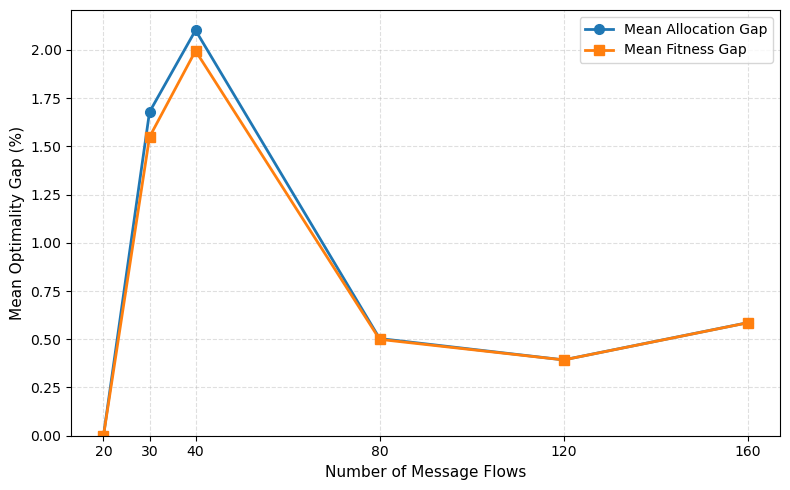

Saved:
1. exact_optimality_gap.pdf
2. exact_optimality_gap.png


In [ ]:
# ==========================================================
# FIGURE: MEAN OPTIMALITY GAP VS NUMBER OF FLOWS
# Proposed Seeded GA relative to Exact MILP
# ==========================================================

import matplotlib.pyplot as plt

# Use the verified final summary dataframe
plot_df = final_optimality_summary.copy()

# ----------------------------------------------------------
# Create figure
# ----------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    plot_df["Flows"],
    plot_df["Mean_Allocation_Gap_Percent"],
    marker="o",
    linewidth=2,
    markersize=7,
    label="Mean Allocation Gap"
)

plt.plot(
    plot_df["Flows"],
    plot_df["Mean_Fitness_Gap_Percent"],
    marker="s",
    linewidth=2,
    markersize=7,
    label="Mean Fitness Gap"
)

# ----------------------------------------------------------
# Formatting
# ----------------------------------------------------------

plt.xlabel("Number of Message Flows", fontsize=11)
plt.ylabel("Mean Optimality Gap (%)", fontsize=11)

plt.xticks(
    plot_df["Flows"]
)

plt.ylim(bottom=0)

plt.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.legend()

plt.tight_layout()

# ----------------------------------------------------------
# 
# ----------------------------------------------------------

plt.savefig(
    "exact_optimality_gap.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "exact_optimality_gap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:\n"
    "1. exact_optimality_gap.pdf\n"
    "2. exact_optimality_gap.png"
)